<a href="https://colab.research.google.com/github/FreemanLiu0901/DataScience_Group9/blob/main/Final%20Project%20(CRS)%20Presentations%20and%20Deliverables/HealthcareAssistantChatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================================
# Healthcare Assistant Chatbot - Final Project
# Freeman Liu Implementation: Data Preparation, Text Feature Engineering, Clustering
# PETROSDTI 5125: DATA SCIENCE APPLICATIONS | SPRING/SUMMER 2025
# ============================================================================

# ## Project Overview
#
# **Tasks**:
# 1. **Data Preparation (2.5%)**: Collect and clean Q&A data from CDC/WHO/medical sources
# 2. **Text Feature Engineering (3%)**: Create TF-IDF, BoW, sBERT feature vectors
# 3. **Clustering (3%)**: Apply K-means, Agglomerative clustering on vectorized text
# 4. **Visualization**: Create chatbot flow + ontology diagrams
#
# **Based on**: Previous COVID-19 clustering project experience + DialogFlow ontology

In [ ]:
# Attempt a clean installation of necessary libraries with controlled dependency resolution

# # Uninstall potentially conflicting libraries
# !pip uninstall -y numpy pandas surprise scikit-learn

# # Install a specific, compatible NumPy version AND surprise together, preventing NumPy upgrade
# # Using --no-build-isolation to work better within Colab's environment
# !pip install numpy==1.23.5 "surprise<0.2" --no-build-isolation

# # Install other required libraries, allowing their dependencies to be resolved,
# # but NumPy should ideally not be downgraded by these.
# !pip install pandas scikit-learn --no-build-isolation # Keep --no-build-isolation for consistency


# # Verify the installed NumPy version and surprise version
# print("\nVerifying installed versions:")
# !pip show numpy
# !pip show surprise

In [4]:
# ## 🔧 Step 1: Environment Setup and Library Imports
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import json
import re
import os
import pickle
from datetime import datetime
import time
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tag import pos_tag

# Scikit-learn Libraries
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import (KMeans, AgglomerativeClustering, DBSCAN,
                           SpectralClustering)
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import LatentDirichletAllocation, PCA, TruncatedSVD
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                           davies_bouldin_score, calinski_harabasz_score,
                           cohen_kappa_score, normalized_mutual_info_score,
                           confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Advanced NLP Libraries
try:
    from sentence_transformers import SentenceTransformer
    print("✅ Sentence Transformers available")
except ImportError:
    print("⚠️ Sentence Transformers not available - install with: pip install sentence-transformers")

try:
    import spacy
    print("✅ spaCy available")
except ImportError:
    print("⚠️ spaCy not available - install with: pip install spacy")

try:
    import hdbscan
    print("✅ HDBSCAN available")
except ImportError:
    print("⚠️ HDBSCAN not available - install with: pip install hdbscan")

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    print("✅ Plotly available")
except ImportError:
    print("⚠️ Plotly not available - install with: pip install plotly")

from wordcloud import WordCloud
import networkx as nx
from tqdm.auto import tqdm
from collections import Counter

# Set random seeds for reproducibility
np.random.seed(42)

print("✅ All libraries imported successfully!")
print(f"📅 Execution started at: {datetime.now()}")

⚠️ Sentence Transformers not available - install with: pip install sentence-transformers
✅ spaCy available
✅ HDBSCAN available
✅ Plotly available
✅ All libraries imported successfully!
📅 Execution started at: 2025-07-23 20:15:29.732030


In [5]:
# ## 🔽 Step 2: Download Required NLTK Data

print("\n🔽 Downloading NLTK data...")
# Added 'punkt_tab' to the download list to fix the KeyError in data processing
nltk_downloads = ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger', 'punkt_tab']

for item in nltk_downloads:
    try:
        nltk.download(item, quiet=True)
        print(f"✅ Downloaded: {item}")
    except Exception as e:
        print(f"❌ Failed to download {item}: {e}")

print("✅ NLTK data download completed!")


🔽 Downloading NLTK data...
✅ Downloaded: punkt
✅ Downloaded: stopwords
✅ Downloaded: wordnet
✅ Downloaded: omw-1.4
✅ Downloaded: averaged_perceptron_tagger
✅ Downloaded: punkt_tab
✅ NLTK data download completed!


In [6]:
# ## 🏥 Step 3: Healthcare Data Processor Class Definition

class HealthcareDataProcessor:
    """
    Complete Healthcare Data Processing Pipeline
    Implements all Person 1 requirements based on previous COVID-19 clustering experience
    """

    def __init__(self):
        print("🏥 Initializing Healthcare Data Processor...")

        # Initialize NLP tools
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = PorterStemmer()

        # Enhanced stopwords (learned from previous project)
        base_stopwords = set(stopwords.words('english'))
        custom_medical_stopwords = {
            'covid', 'covid19', 'sarscov', 'sarscov2', 'coronavirus',
            'patient', 'study', 'analysis', 'research', 'data',
            'method', 'result', 'conclusion', 'background', 'objective',
            'abstract', 'introduction', 'discussion', 'paper', 'article'
        }
        self.stop_words = base_stopwords.union(custom_medical_stopwords)

        # Medical ontology from DialogFlow project
        self.medical_ontology = self._load_medical_ontology()

        # Intent patterns from 6 competency questions
        self.intent_patterns = self._load_intent_patterns()

        # Data containers
        self.raw_data = []
        self.processed_data = None
        self.feature_vectors = {}
        self.clustering_results = {}
        self.evaluation_metrics = {}

        print("✅ Healthcare Data Processor initialized successfully!")

    def _load_medical_ontology(self):
        """Load medical entities based on DialogFlow ontology structure"""
        return {
            'diseases': [
                'covid19', 'covid-19', 'coronavirus', 'sars-cov-2', 'pandemic',
                'flu', 'influenza', 'common cold', 'pneumonia', 'bronchitis',
                'diabetes', 'hypertension', 'cancer', 'asthma', 'tuberculosis',
                'malaria', 'dengue', 'heart disease', 'stroke', 'arthritis',
                'migraine', 'depression', 'anxiety', 'obesity', 'allergies',
                'hepatitis', 'kidney disease', 'liver disease', 'osteoporosis'
            ],
            'symptoms': [
                'fever', 'cough', 'fatigue', 'headache', 'nausea', 'vomiting',
                'shortness of breath', 'chest pain', 'sore throat', 'runny nose',
                'body aches', 'chills', 'dizziness', 'diarrhea', 'constipation',
                'loss of taste', 'loss of smell', 'muscle pain', 'joint pain',
                'weakness', 'sweating', 'rash', 'itching', 'bleeding',
                'abdominal pain', 'back pain', 'neck pain', 'swelling'
            ],
            'treatments': [
                'medication', 'antibiotics', 'painkillers', 'vaccine', 'surgery',
                'therapy', 'rest', 'isolation', 'home care', 'hospital care',
                'oxygen therapy', 'physiotherapy', 'chemotherapy', 'radiation',
                'immunotherapy', 'dialysis', 'transplant', 'rehabilitation',
                'counseling', 'lifestyle changes', 'diet modification'
            ],
            'prevention': [
                'hand washing', 'mask wearing', 'social distancing', 'vaccination',
                'quarantine', 'exercise', 'healthy diet', 'adequate sleep',
                'stress management', 'hygiene', 'sanitizer', 'ventilation',
                'regular checkups', 'screening', 'avoiding triggers'
            ],
            'patient_types': [
                'adult', 'child', 'elderly', 'pregnant', 'immunocompromised',
                'anxious person', 'chronic patient', 'healthy individual',
                'high risk', 'low risk', 'outpatient', 'inpatient',
                'adolescent', 'senior', 'infant', 'toddler'
            ],
            'food_recommendations': [
                'hydration', 'light diet', 'avoid dairy', 'vitamin c', 'zinc',
                'protein rich', 'low sodium', 'fiber rich', 'probiotics',
                'antioxidants', 'omega-3', 'calcium', 'iron', 'fruits',
                'vegetables', 'whole grains', 'lean protein', 'nuts', 'seeds'
            ]
        }

    def _load_intent_patterns(self):
        """Load intent patterns based on 6 competency questions"""
        return {
            'DiseaseToSymptom': [
                'symptoms of', 'signs of', 'what are the symptoms',
                'how does', 'manifests as', 'presents with', 'characterized by'
            ],
            'SymptomToDisease': [
                'what disease', 'what condition', 'could be', 'might indicate',
                'associated with', 'caused by', 'suggest', 'point to'
            ],
            'TreatmentRecommendation': [
                'treatment for', 'how to treat', 'cure for', 'therapy',
                'medication', 'management', 'remedy', 'healing'
            ],
            'RiskAssessment': [
                'am i at risk', 'risk factors', 'likelihood', 'probability',
                'chances', 'susceptible', 'vulnerable', 'predisposed'
            ],
            'FoodAdvice': [
                'food for', 'diet for', 'nutrition', 'eat', 'avoid eating',
                'dietary', 'nutritional', 'consume', 'intake'
            ],
            'PreventionAdvice': [
                'prevent', 'avoid', 'reduce risk', 'protection', 'precautions',
                'prevention', 'safeguard', 'shield', 'defend'
            ],
            'HelpForPatientType': [
                'help for', 'advice for', 'guidance for', 'support',
                'care for', 'assistance', 'aid'
            ],
            'VaccineInfo': [
                'vaccine', 'vaccination', 'immunization', 'shot',
                'dose', 'booster', 'inoculation'
            ]
        }

# Initialize the processor
processor = HealthcareDataProcessor()

print("\n" + "="*80)
print("🎯 HEALTHCARE DATA PROCESSOR INITIALIZED")
print("="*80)
print(f"📊 Medical ontology loaded: {sum(len(v) for v in processor.medical_ontology.values())} entities")
print(f"🎯 Intent patterns loaded: {len(processor.intent_patterns)} intents")
print(f"⚙️ Processor ready for data collection and processing")
print("="*80)


🏥 Initializing Healthcare Data Processor...
✅ Healthcare Data Processor initialized successfully!

🎯 HEALTHCARE DATA PROCESSOR INITIALIZED
📊 Medical ontology loaded: 128 entities
🎯 Intent patterns loaded: 8 intents
⚙️ Processor ready for data collection and processing


In [7]:
# ## 🏥 Step 3: Healthcare Data Processor Class Definition

class HealthcareDataProcessor:
    """
    Complete Healthcare Data Processing Pipeline
    Implements all Person 1 requirements based on previous COVID-19 clustering experience
    """

    def __init__(self):
        print("🏥 Initializing Healthcare Data Processor...")

        # Initialize NLP tools
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = PorterStemmer()

        # Enhanced stopwords (learned from previous project)
        base_stopwords = set(stopwords.words('english'))
        custom_medical_stopwords = {
            'covid', 'covid19', 'sarscov', 'sarscov2', 'coronavirus',
            'patient', 'study', 'analysis', 'research', 'data',
            'method', 'result', 'conclusion', 'background', 'objective',
            'abstract', 'introduction', 'discussion', 'paper', 'article'
        }
        self.stop_words = base_stopwords.union(custom_medical_stopwords)

        # Medical ontology from DialogFlow project
        self.medical_ontology = self._load_medical_ontology()

        # Intent patterns from 6 competency questions
        self.intent_patterns = self._load_intent_patterns()

        # Data containers
        self.raw_data = []
        self.processed_data = None
        self.feature_vectors = {}
        self.clustering_results = {}
        self.evaluation_metrics = {}

        print("✅ Healthcare Data Processor initialized successfully!")

    def _load_medical_ontology(self):
        """Load medical entities based on DialogFlow ontology structure"""
        return {
            'diseases': [
                'covid19', 'covid-19', 'coronavirus', 'sars-cov-2', 'pandemic',
                'flu', 'influenza', 'common cold', 'pneumonia', 'bronchitis',
                'diabetes', 'hypertension', 'cancer', 'asthma', 'tuberculosis',
                'malaria', 'dengue', 'heart disease', 'stroke', 'arthritis',
                'migraine', 'depression', 'anxiety', 'obesity', 'allergies',
                'hepatitis', 'kidney disease', 'liver disease', 'osteoporosis'
            ],
            'symptoms': [
                'fever', 'cough', 'fatigue', 'headache', 'nausea', 'vomiting',
                'shortness of breath', 'chest pain', 'sore throat', 'runny nose',
                'body aches', 'chills', 'dizziness', 'diarrhea', 'constipation',
                'loss of taste', 'loss of smell', 'muscle pain', 'joint pain',
                'weakness', 'sweating', 'rash', 'itching', 'bleeding',
                'abdominal pain', 'back pain', 'neck pain', 'swelling'
            ],
            'treatments': [
                'medication', 'antibiotics', 'painkillers', 'vaccine', 'surgery',
                'therapy', 'rest', 'isolation', 'home care', 'hospital care',
                'oxygen therapy', 'physiotherapy', 'chemotherapy', 'radiation',
                'immunotherapy', 'dialysis', 'transplant', 'rehabilitation',
                'counseling', 'lifestyle changes', 'diet modification'
            ],
            'prevention': [
                'hand washing', 'mask wearing', 'social distancing', 'vaccination',
                'quarantine', 'exercise', 'healthy diet', 'adequate sleep',
                'stress management', 'hygiene', 'sanitizer', 'ventilation',
                'regular checkups', 'screening', 'avoiding triggers'
            ],
            'patient_types': [
                'adult', 'child', 'elderly', 'pregnant', 'immunocompromised',
                'anxious person', 'chronic patient', 'healthy individual',
                'high risk', 'low risk', 'outpatient', 'inpatient',
                'adolescent', 'senior', 'infant', 'toddler'
            ],
            'food_recommendations': [
                'hydration', 'light diet', 'avoid dairy', 'vitamin c', 'zinc',
                'protein rich', 'low sodium', 'fiber rich', 'probiotics',
                'antioxidants', 'omega-3', 'calcium', 'iron', 'fruits',
                'vegetables', 'whole grains', 'lean protein', 'nuts', 'seeds'
            ]
        }

    def _load_intent_patterns(self):
        """Load intent patterns based on 6 competency questions"""
        return {
            'DiseaseToSymptom': [
                'symptoms of', 'signs of', 'what are the symptoms',
                'how does', 'manifests as', 'presents with', 'characterized by'
            ],
            'SymptomToDisease': [
                'what disease', 'what condition', 'could be', 'might indicate',
                'associated with', 'caused by', 'suggest', 'point to'
            ],
            'TreatmentRecommendation': [
                'treatment for', 'how to treat', 'cure for', 'therapy',
                'medication', 'management', 'remedy', 'healing'
            ],
            'RiskAssessment': [
                'am i at risk', 'risk factors', 'likelihood', 'probability',
                'chances', 'susceptible', 'vulnerable', 'predisposed'
            ],
            'FoodAdvice': [
                'food for', 'diet for', 'nutrition', 'eat', 'avoid eating',
                'dietary', 'nutritional', 'consume', 'intake'
            ],
            'PreventionAdvice': [
                'prevent', 'avoid', 'reduce risk', 'protection', 'precautions',
                'prevention', 'safeguard', 'shield', 'defend'
            ],
            'HelpForPatientType': [
                'help for', 'advice for', 'guidance for', 'support',
                'care for', 'assistance', 'aid'
            ],
            'VaccineInfo': [
                'vaccine', 'vaccination', 'immunization', 'shot',
                'dose', 'booster', 'inoculation'
            ]
        }

# Initialize the processor
processor = HealthcareDataProcessor()

print("\n" + "="*80)
print("🎯 HEALTHCARE DATA PROCESSOR INITIALIZED")
print("="*80)
print(f"📊 Medical ontology loaded: {sum(len(v) for v in processor.medical_ontology.values())} entities")
print(f"🎯 Intent patterns loaded: {len(processor.intent_patterns)} intents")
print(f"⚙️ Processor ready for data collection and processing")
print("="*80)


🏥 Initializing Healthcare Data Processor...
✅ Healthcare Data Processor initialized successfully!

🎯 HEALTHCARE DATA PROCESSOR INITIALIZED
📊 Medical ontology loaded: 128 entities
🎯 Intent patterns loaded: 8 intents
⚙️ Processor ready for data collection and processing


In [8]:
# ## 📥 Step 4: Data Collection Methods
import random
from datetime import datetime

def clean_text(self, text):
    """Enhanced text cleaning based on previous COVID-19 project experience"""
    if not isinstance(text, str):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs and email addresses
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # Remove standalone numbers (learned from previous project improves clustering)
    text = re.sub(r'\b\d+\b', '', text)

    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^\w\s\.\?\!,;:]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

def collect_cdc_data(self, max_samples=50):
    """Collect Q&A data from CDC website (enhanced from previous experience)"""
    print("🔽 Collecting data from CDC website...")

    cdc_urls = [
        'https://www.cdc.gov/coronavirus/2019-ncov/faq.html',
        'https://www.cdc.gov/flu/about/qa/index.html',
        'https://www.cdc.gov/diabetes/basics/diabetes.html'
    ]

    collected_data = []

    for url in cdc_urls:
        try:
            print(f"📥 Scraping: {url}")
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
            }
            response = requests.get(url, headers=headers, timeout=10)
            response.raise_for_status()

            soup = BeautifulSoup(response.content, 'html.parser')

            # Find FAQ sections (multiple strategies)
            questions = []

            # Strategy 1: Find headings with question marks
            questions.extend(soup.find_all(['h2', 'h3', 'h4'], string=re.compile(r'\?')))

            # Strategy 2: Find elements with 'question' in class
            questions.extend(soup.find_all(attrs={'class': re.compile(r'question', re.I)}))

            # Strategy 3: Find strong/bold text with questions
            questions.extend(soup.find_all(['strong', 'b'], string=re.compile(r'\?')))

            for q in questions[:max_samples]:
                question_text = q.get_text().strip()

                # Find answer (try multiple strategies)
                answer_parts = []

                # Strategy 1: Next siblings
                for sibling in q.find_next_siblings(['p', 'div', 'ul'], limit=3):
                    if sibling.get_text().strip():
                        answer_parts.append(sibling.get_text().strip())

                # Strategy 2: Parent's next siblings
                if not answer_parts and q.parent:
                    for sibling in q.parent.find_next_siblings(['p', 'div'], limit=2):
                        if sibling.get_text().strip():
                            answer_parts.append(sibling.get_text().strip())

                answer_text = ' '.join(answer_parts)

                if len(question_text) > 15 and len(answer_text) > 30:
                    collected_data.append({
                        'question': question_text,
                        'answer': answer_text,
                        'source': 'CDC',
                        'url': url,
                        'collected_at': datetime.now().isoformat()
                    })

            time.sleep(1)  # Be respectful to servers

        except Exception as e:
            print(f"❌ Error scraping {url}: {e}")
            continue

    print(f"✅ Collected {len(collected_data)} Q&A pairs from CDC")
    return collected_data

def generate_healthcare_qa_synthetic(self, num_samples=400):
    """Generate synthetic healthcare Q&A data based on competency questions"""
    print("🤖 Generating synthetic healthcare Q&A data...")

    synthetic_data = []

    # Enhanced templates based on 6 competency questions
    templates = {
        'DiseaseToSymptom': [
            ("What are the symptoms of {disease}?",
             "The main symptoms of {disease} include {symptoms}. These symptoms may vary in severity and it's important to consult a healthcare provider for proper diagnosis and treatment planning."),
            ("How does {disease} present in patients?",
             "{disease} typically presents with symptoms such as {symptoms}. Early recognition of these symptoms is crucial for timely medical intervention and better outcomes."),
            ("What signs should I look for with {disease}?",
             "Common signs of {disease} include {symptoms}. If you experience {primary_symptom} along with other symptoms, seek medical attention promptly."),
            ("What are the early warning signs of {disease}?",
             "Early warning signs of {disease} may include {symptoms}. These symptoms can develop gradually or suddenly depending on the individual case.")
        ],
        'SymptomToDisease': [
            ("What disease could cause {symptoms}?",
             "Symptoms like {symptoms} can be associated with several conditions including {disease}. A healthcare professional should evaluate these symptoms for accurate diagnosis and appropriate treatment."),
            ("I have {symptoms}. What condition might this be?",
             "The combination of {symptoms} could indicate {disease}, but many conditions share similar symptoms. Medical evaluation is necessary for proper diagnosis and care planning."),
            ("Could {symptoms} be a sign of {disease}?",
             "Yes, {symptoms} can be symptoms of {disease}. However, these symptoms may also occur in other conditions, so professional medical assessment is recommended."),
            ("What should I do if I have {symptoms}?",
             "If you're experiencing {symptoms}, it could be related to {disease} or other conditions. It's important to consult with a healthcare provider for proper evaluation.")
        ],
        'TreatmentRecommendation': [
            ("What is the treatment for {disease}?",
             "Treatment for {disease} typically includes {treatment}. The specific treatment plan should be personalized based on individual patient factors, medical history, and disease severity."),
            ("How is {disease} managed medically?",
             "Medical management of {disease} usually involves {treatment}. Treatment effectiveness varies among patients and requires ongoing medical supervision and monitoring."),
            ("What are the treatment options for {disease}?",
             "Common treatment options for {disease} include {treatment}. Your healthcare provider will determine the most appropriate treatment approach based on your specific condition and needs."),
            ("How do doctors treat {disease}?",
             "Healthcare providers typically treat {disease} with {treatment}. The treatment approach may be adjusted based on patient response and disease progression.")
        ],
        'RiskAssessment': [
            ("Am I at risk for {disease}?",
             "Risk factors for {disease} include various personal, genetic, and environmental factors. Your individual risk assessment should be discussed with a healthcare provider who can evaluate your specific situation."),
            ("What increases the risk of {disease}?",
             "Several factors can increase the risk of developing {disease}. Age, lifestyle choices, family history, and existing medical conditions all play important roles in risk assessment."),
            ("Who is most likely to develop {disease}?",
             "Certain populations may have higher risk for {disease} based on various factors. Individual risk varies significantly and should be evaluated by medical professionals."),
            ("How can I assess my risk for {disease}?",
             "Risk assessment for {disease} involves evaluating multiple factors. A healthcare provider can help determine your personal risk level and recommend appropriate preventive measures.")
        ],
        'FoodAdvice': [
            ("What foods are good for {disease}?",
             "For {disease} management, foods such as {food} may be beneficial. Nutritional needs vary by individual, so it's important to consult with a healthcare provider or registered dietitian."),
            ("What should I eat if I have {disease}?",
             "People with {disease} may benefit from including {food} in their diet. Dietary recommendations should be tailored to individual needs, preferences, and medical conditions."),
            ("Are there dietary restrictions for {disease}?",
             "Managing {disease} may involve dietary considerations including {food}. Always discuss dietary changes with your healthcare team before making significant modifications."),
            ("What nutrition advice do you have for {disease}?",
             "Nutritional support for {disease} often includes {food}. A balanced approach to nutrition can support overall health and disease management.")
        ],
        'PreventionAdvice': [
            ("How can I prevent {disease}?",
             "Prevention of {disease} includes evidence-based measures such as {prevention}. Following established prevention strategies is important for reducing your risk."),
            ("What can I do to avoid {disease}?",
             "To reduce your risk of {disease}, consider implementing {prevention}. Prevention strategies should be discussed with healthcare professionals for personalized guidance."),
            ("How do I protect myself from {disease}?",
             "Protection against {disease} involves {prevention}. Stay informed about current health recommendations and guidelines from reputable medical sources."),
            ("What preventive measures work for {disease}?",
             "Effective preventive measures for {disease} include {prevention}. Consistency in applying these measures is key to their effectiveness.")
        ]
    }

    # Generate data for each intent
    samples_per_intent = num_samples // len(templates)

    for intent, template_list in templates.items():
        for _ in range(samples_per_intent):
            template = random.choice(template_list)
            question_template, answer_template = template

            # Randomly select entities from ontology
            disease = random.choice(self.medical_ontology['diseases'])
            symptoms = np.random.choice(self.medical_ontology['symptoms'],
                            size=np.random.randint(2, 4), replace=False)
            primary_symptom = symptoms[0]
            symptoms_str = ', '.join(symptoms)
            treatment = random.choice(self.medical_ontology['treatments'])
            prevention = random.choice(self.medical_ontology['prevention'])
            food = random.choice(self.medical_ontology['food_recommendations'])

            try:
                question = question_template.format(
                    disease=disease, symptoms=symptoms_str, treatment=treatment,
                    prevention=prevention, food=food, primary_symptom=primary_symptom
                )
                answer = answer_template.format(
                    disease=disease, symptoms=symptoms_str, treatment=treatment,
                    prevention=prevention, food=food, primary_symptom=primary_symptom
                )

                synthetic_data.append({
                    'question': question,
                    'answer': answer,
                    'source': 'Synthetic',
                    'intent': intent,
                    'entities': {
                        'disease': disease,
                        'symptoms': list(symptoms),
                        'treatment': treatment,
                        'prevention': prevention,
                        'food': food
                    },
                    'generated_at': datetime.now().isoformat()
                })
            except Exception as e:
                continue

    print(f"✅ Generated {len(synthetic_data)} synthetic Q&A pairs")
    return synthetic_data

# Add methods to processor class
HealthcareDataProcessor.clean_text = clean_text
HealthcareDataProcessor.collect_cdc_data = collect_cdc_data
HealthcareDataProcessor.generate_healthcare_qa_synthetic = generate_healthcare_qa_synthetic

print("✅ Data collection methods added to processor")


✅ Data collection methods added to processor


In [9]:
# ## 🧹 Step 5: Text Preprocessing Methods

def preprocess_text_advanced(self, text):
    """Advanced text preprocessing based on previous project learnings"""
    if not isinstance(text, str):
        return ""

    # Basic cleaning
    text = self.clean_text(text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and short words
    words = [w for w in words if w.lower() not in self.stop_words and len(w) > 2]

    # POS tagging to keep only meaningful parts of speech
    try:
        pos_tags = pos_tag(words)
        meaningful_words = [word for word, pos in pos_tags
                          if pos.startswith(('NN', 'VB', 'JJ', 'RB'))]
    except:
        meaningful_words = words  # Fallback if POS tagging fails

    # Lemmatization (based on previous experience, sometimes helps clustering)
    lemmatized_words = [self.lemmatizer.lemmatize(word.lower())
                      for word in meaningful_words]

    return " ".join(lemmatized_words)

def extract_medical_entities(self, text):
    """Extract medical entities using ontology-based approach"""
    entities = {category: [] for category in self.medical_ontology.keys()}
    text_lower = text.lower()

    for category, entity_list in self.medical_ontology.items():
        for entity in entity_list:
            if entity.lower() in text_lower:
                entities[category].append(entity)

    # Remove duplicates
    for category in entities:
        entities[category] = list(set(entities[category]))

    return entities

def classify_intent(self, question, answer=""):
    """Classify intent based on question patterns"""
    text = (question + " " + answer).lower()

    intent_scores = {}
    for intent, patterns in self.intent_patterns.items():
        score = sum(1 for pattern in patterns if pattern in text)
        if score > 0:
            intent_scores[intent] = score

    if intent_scores:
        return max(intent_scores, key=intent_scores.get)
    else:
        return 'General'

# Add preprocessing methods to processor class
HealthcareDataProcessor.preprocess_text_advanced = preprocess_text_advanced
HealthcareDataProcessor.extract_medical_entities = extract_medical_entities
HealthcareDataProcessor.classify_intent = classify_intent

print("✅ Text preprocessing methods added to processor")


✅ Text preprocessing methods added to processor


✅ Main data preparation pipeline added to processor

🚀 EXECUTING DATA PREPARATION PIPELINE
🔄 Starting healthcare data preparation pipeline...
📥 Collecting data from medical websites...
🔽 Collecting data from CDC website...
📥 Scraping: https://www.cdc.gov/coronavirus/2019-ncov/faq.html
❌ Error scraping https://www.cdc.gov/coronavirus/2019-ncov/faq.html: 404 Client Error: Not Found for url: https://www.cdc.gov/coronavirus/2019-ncov/faq.html
📥 Scraping: https://www.cdc.gov/flu/about/qa/index.html
❌ Error scraping https://www.cdc.gov/flu/about/qa/index.html: 404 Client Error: Not Found for url: https://www.cdc.gov/flu/about/qa/index.html
📥 Scraping: https://www.cdc.gov/diabetes/basics/diabetes.html
❌ Error scraping https://www.cdc.gov/diabetes/basics/diabetes.html: 404 Client Error: Not Found for url: https://www.cdc.gov/diabetes/basics/diabetes.html
✅ Collected 0 Q&A pairs from CDC
✅ Collected 0 samples from CDC
🤖 Generating synthetic healthcare Q&A data...
🤖 Generating synthetic healthca

Processing:   0%|          | 0/600 [00:00<?, ?it/s]


📈 Data Quality Analysis:
Total processed samples: 555

Intent distribution:
  SymptomToDisease: 100 (18.0%)
  RiskAssessment: 95 (17.1%)
  FoodAdvice: 93 (16.8%)
  TreatmentRecommendation: 92 (16.6%)
  DiseaseToSymptom: 90 (16.2%)
  PreventionAdvice: 85 (15.3%)

Source distribution:
  Synthetic: 555

Text statistics:
  Average text length: 162.8 characters
  Average word count: 19.7 words
  Average entity count: 2.1 entities

✅ Data preparation completed successfully!
📁 Saved files:
  - healthcare_qa_processed.csv
  - healthcare_qa_processed.json

📋 Sample processed data:
             intent                   clean_question  entity_count     source
0  DiseaseToSymptom          malaria present patient             2  Synthetic
1  DiseaseToSymptom       early warning sign allergy             2  Synthetic
2  DiseaseToSymptom                 symptom migraine             3  Synthetic
3  DiseaseToSymptom               symptom depression             3  Synthetic
4  DiseaseToSymptom  early war

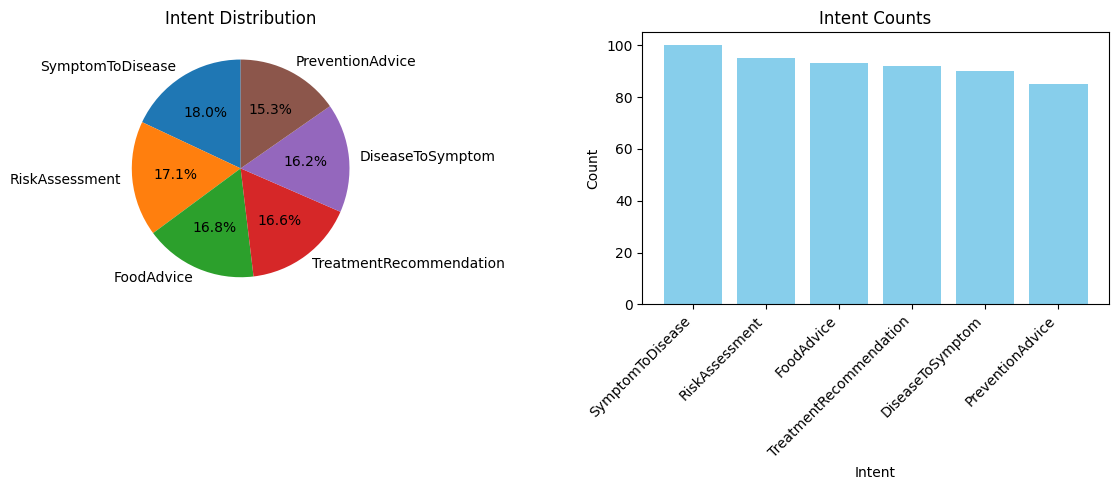


🎯 Data preparation completed! Ready for feature engineering...


In [10]:
# ## 📊 Step 6: Main Data Preparation Pipeline

def prepare_healthcare_dataset(self, num_samples=600, use_web_data=True):
    """Main data preparation pipeline implementing Person 1 requirements"""
    print("🔄 Starting healthcare data preparation pipeline...")
    print("="*60)

    all_data = []

    # Collect web data if requested (CDC/WHO requirement)
    if use_web_data:
        try:
            print("📥 Collecting data from medical websites...")
            cdc_data = self.collect_cdc_data(max_samples=50)
            all_data.extend(cdc_data)
            print(f"✅ Collected {len(cdc_data)} samples from CDC")
        except Exception as e:
            print(f"⚠️ Web data collection failed: {e}")

    # Generate synthetic data (based on competency questions)
    print("🤖 Generating synthetic healthcare Q&A data...")
    synthetic_data = self.generate_healthcare_qa_synthetic(num_samples - len(all_data))
    all_data.extend(synthetic_data)

    print(f"📊 Total raw data collected: {len(all_data)} samples")

    # Process each sample
    processed_samples = []

    print("🔄 Processing and cleaning samples...")
    for idx, sample in enumerate(tqdm(all_data, desc="Processing")):
        try:
            # Clean texts using advanced preprocessing
            clean_question = self.preprocess_text_advanced(sample['question'])
            clean_answer = self.preprocess_text_advanced(sample.get('answer', ''))

            # Skip if too short after cleaning
            if len(clean_question) < 10:
                continue

            # Combine question and answer for unified analysis
            combined_text = clean_question + " " + clean_answer

            # Extract medical entities using ontology
            entities = self.extract_medical_entities(combined_text)

            # Classify intent based on competency questions
            intent = sample.get('intent') or self.classify_intent(
                sample['question'], sample.get('answer', ''))

            processed_sample = {
                'id': idx,
                'original_question': sample['question'],
                'original_answer': sample.get('answer', ''),
                'clean_question': clean_question,
                'clean_answer': clean_answer,
                'combined_text': combined_text,
                'entities': entities,
                'intent': intent,
                'source': sample.get('source', 'Unknown'),
                'url': sample.get('url', ''),
                'text_length': len(combined_text),
                'word_count': len(combined_text.split()),
                'entity_count': sum(len(ents) for ents in entities.values()),
                'processed_at': datetime.now().isoformat()
            }

            processed_samples.append(processed_sample)

        except Exception as e:
            print(f"❌ Error processing sample {idx}: {e}")
            continue

    # Convert to DataFrame
    self.processed_data = pd.DataFrame(processed_samples)

    # Data quality analysis
    print("\n📈 Data Quality Analysis:")
    print("="*40)
    print(f"Total processed samples: {len(self.processed_data)}")
    print(f"\nIntent distribution:")
    intent_dist = self.processed_data['intent'].value_counts()
    for intent, count in intent_dist.items():
        print(f"  {intent}: {count} ({count/len(self.processed_data)*100:.1f}%)")

    print(f"\nSource distribution:")
    source_dist = self.processed_data['source'].value_counts()
    for source, count in source_dist.items():
        print(f"  {source}: {count}")

    print(f"\nText statistics:")
    print(f"  Average text length: {self.processed_data['text_length'].mean():.1f} characters")
    print(f"  Average word count: {self.processed_data['word_count'].mean():.1f} words")
    print(f"  Average entity count: {self.processed_data['entity_count'].mean():.1f} entities")

    # Save processed data (required for handover)
    self.processed_data.to_csv('healthcare_qa_processed.csv', index=False)
    self.processed_data.to_json('healthcare_qa_processed.json', orient='records', indent=2)

    print(f"\n✅ Data preparation completed successfully!")
    print(f"📁 Saved files:")
    print(f"  - healthcare_qa_processed.csv")
    print(f"  - healthcare_qa_processed.json")

    return self.processed_data

# Add main pipeline method to processor class
HealthcareDataProcessor.prepare_healthcare_dataset = prepare_healthcare_dataset

print("✅ Main data preparation pipeline added to processor")

# ## 🚀 Execute Data Preparation Pipeline

print("\n" + "="*80)
print("🚀 EXECUTING DATA PREPARATION PIPELINE")
print("="*80)

# Execute the data preparation pipeline
processed_data = processor.prepare_healthcare_dataset(num_samples=600, use_web_data=True)

# Display sample data
print("\n📋 Sample processed data:")
print(processed_data[['intent', 'clean_question', 'entity_count', 'source']].head(10))

# Show intent distribution visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
intent_counts = processed_data['intent'].value_counts()
plt.pie(intent_counts.values, labels=intent_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Intent Distribution')

plt.subplot(1, 2, 2)
plt.bar(intent_counts.index, intent_counts.values, color='skyblue')
plt.title('Intent Counts')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('data_preparation_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🎯 Data preparation completed! Ready for feature engineering...")
print("="*80)

In [11]:
import nltk
import os

custom_path = "/Users/jiongjieliu/Documents/healthcare_chatbot_env/nltk_data"
os.makedirs(custom_path, exist_ok=True)

nltk.download('punkt', download_dir=custom_path)

nltk.data.path.append(custom_path)

from nltk.tokenize import sent_tokenize
text = "This is a test. Here's another sentence. Isn't it great?"
print(sent_tokenize(text))


['This is a test.', "Here's another sentence.", "Isn't it great?"]


[nltk_data] Downloading package punkt to /Users/jiongjieliu/Documents/
[nltk_data]     healthcare_chatbot_env/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ Feature engineering method added to processor

🚀 EXECUTING FEATURE ENGINEERING PIPELINE
🔧 Creating comprehensive feature vectors...
📊 Processing 555 text samples

📊 Creating TF-IDF vectors...
   Parameters: max_features=3000, ngram_range=(1,2) - optimized from previous project
   ✅ TF-IDF matrix shape: (555, 1300)
   ✅ Feature names: 1300 unique terms

📊 Creating BoW vectors...
   Parameters: max_features=1000, ngram_range=(1,2) - balanced approach
   ✅ BoW matrix shape: (555, 1000)
   ✅ Vocabulary size: 1000 terms

📊 Creating LDA topic vectors...
   Parameters: 10 topics for medical domain coverage
   ✅ LDA matrix shape: (555, 10)
   ✅ Topic coherence: Converged in 20 iterations

🤖 Creating Sentence-BERT embeddings...
   Model: all-MiniLM-L6-v2 - optimized for semantic similarity
   ❌ sBERT encoding failed: name 'SentenceTransformer' is not defined
   ⚠️ Continuing without sBERT embeddings

📊 Creating Word2Vec embeddings...
   Model: spaCy en_core_web_md - pre-trained word vectors
 

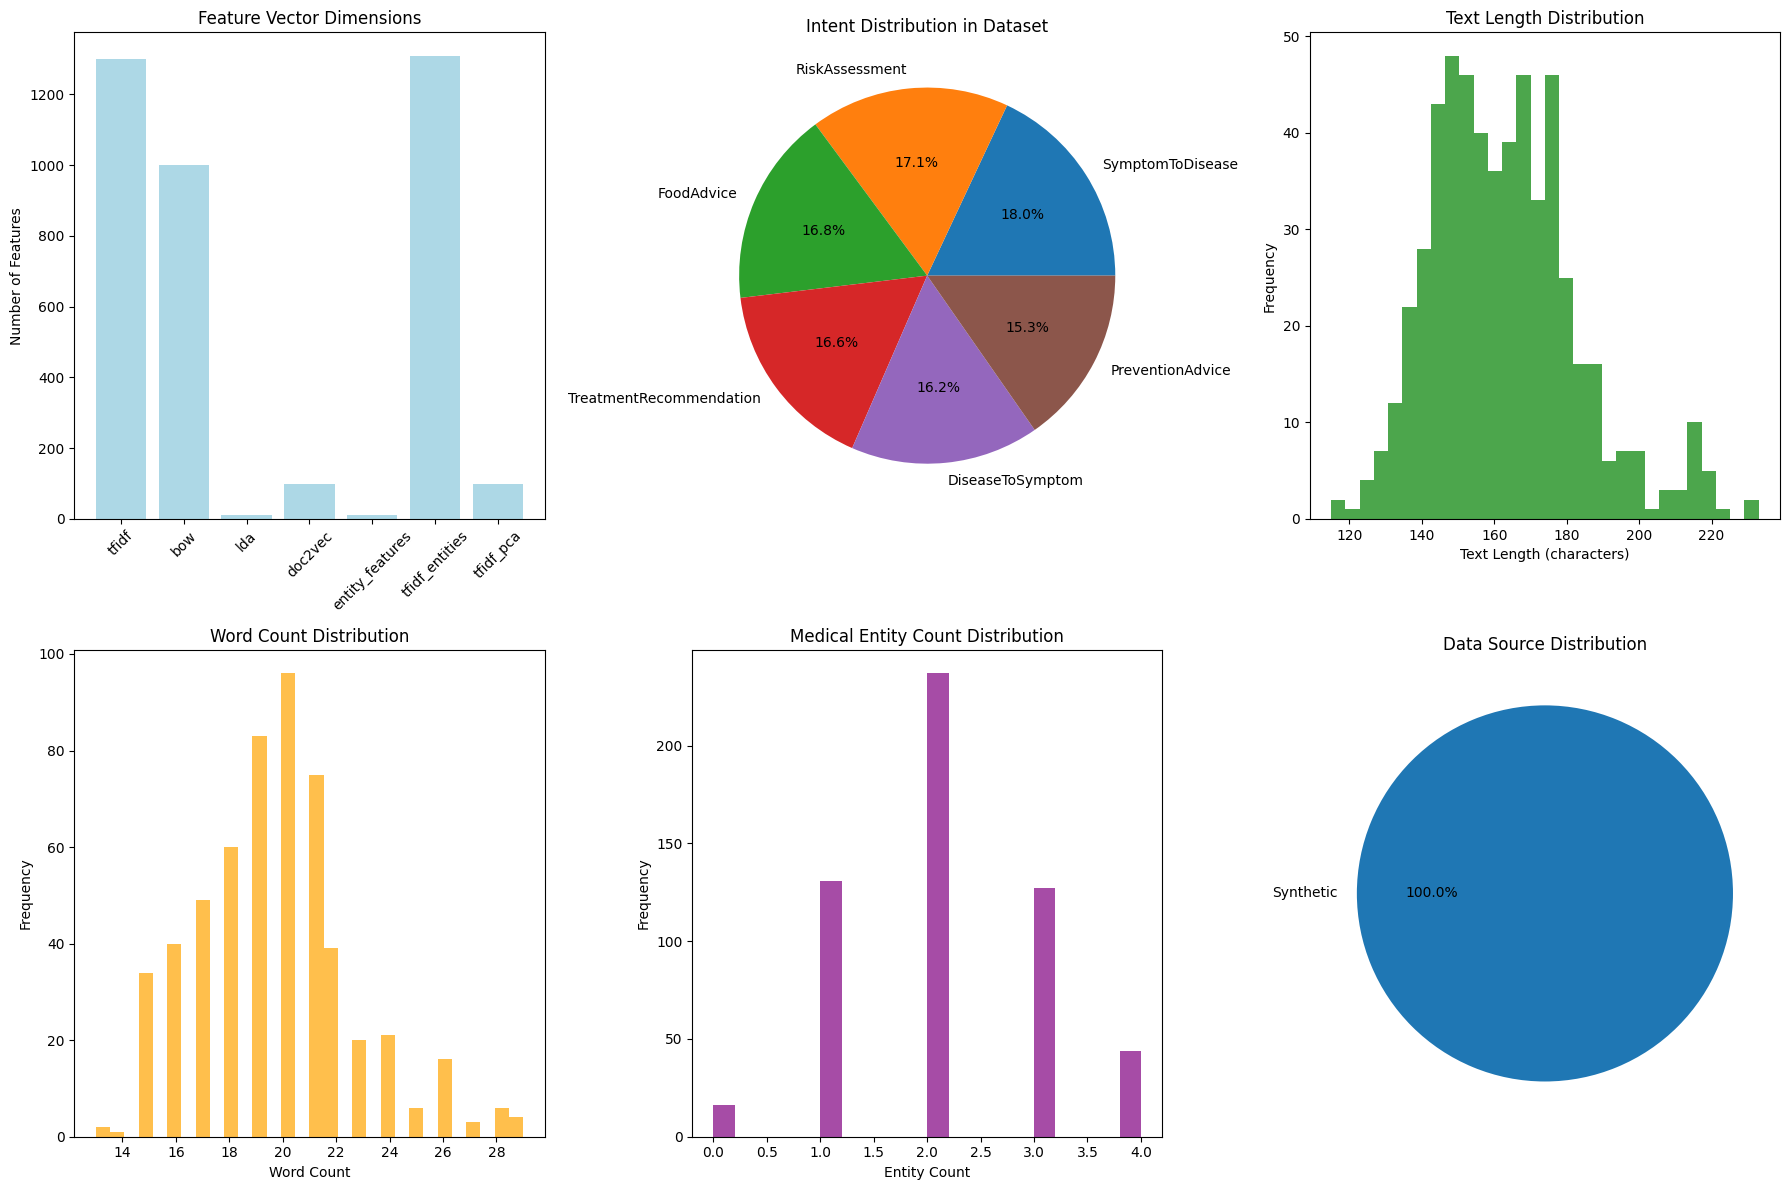


🎯 Feature engineering completed! Ready for clustering analysis...


In [12]:
# ## 🔧 Step 7: Text Feature Engineering (Person 1 Requirement - 3%)

def create_comprehensive_features(self):
    """
    Create comprehensive feature vectors using multiple techniques
    Implements Person 1 requirement: TF-IDF, BoW, and sBERT feature engineering
    Based on previous COVID-19 project optimization
    """
    print("🔧 Creating comprehensive feature vectors...")
    print("="*60)

    if self.processed_data is None:
        raise ValueError("No processed data available. Run prepare_healthcare_dataset() first.")

    texts = self.processed_data['combined_text'].tolist()
    print(f"📊 Processing {len(texts)} text samples")

    # 1. TF-IDF Vectorization (optimized parameters from previous experience)
    print("\n📊 Creating TF-IDF vectors...")
    print("   Parameters: max_features=3000, ngram_range=(1,2) - optimized from previous project")

    tfidf_vectorizer = TfidfVectorizer(
        max_features=3000,  # Increased from previous 1000 based on experience
        ngram_range=(1, 2),  # Best performing combination from previous project
        min_df=2,           # Minimum document frequency
        max_df=0.95,        # Maximum document frequency
        stop_words='english',
        lowercase=True,
        token_pattern=r'\b\w{2,}\b'  # Only words with 2+ characters
    )

    tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
    self.feature_vectors['tfidf'] = tfidf_matrix

    # Store vectorizer for later use
    self.vectorizers = {'tfidf': tfidf_vectorizer}

    print(f"   ✅ TF-IDF matrix shape: {tfidf_matrix.shape}")
    print(f"   ✅ Feature names: {len(tfidf_vectorizer.get_feature_names_out())} unique terms")

    # 2. Bag of Words (BoW) - optimized from previous experience
    print("\n📊 Creating BoW vectors...")
    print("   Parameters: max_features=1000, ngram_range=(1,2) - balanced approach")

    bow_vectorizer = CountVectorizer(
        max_features=1000,   # Previous project showed good balance at 1000
        ngram_range=(1, 2),  # Unigrams and bigrams for better context
        min_df=2,
        max_df=0.95,
        stop_words='english',
        lowercase=True,
        token_pattern=r'\b\w{2,}\b'
    )

    bow_matrix = bow_vectorizer.fit_transform(texts)
    self.feature_vectors['bow'] = bow_matrix
    self.vectorizers['bow'] = bow_vectorizer

    print(f"   ✅ BoW matrix shape: {bow_matrix.shape}")
    print(f"   ✅ Vocabulary size: {len(bow_vectorizer.get_feature_names_out())} terms")

    # 3. LDA Topic Modeling (enhanced approach)
    print("\n📊 Creating LDA topic vectors...")
    print("   Parameters: 10 topics for medical domain coverage")

    lda_vectorizer = CountVectorizer(
        max_features=1000,
        stop_words='english',
        min_df=2,
        max_df=0.8
    )
    lda_counts = lda_vectorizer.fit_transform(texts)

    lda_model = LatentDirichletAllocation(
        n_components=10,     # 10 topics for healthcare domain
        random_state=42,
        max_iter=20,
        learning_method='batch'
    )
    lda_matrix = lda_model.fit_transform(lda_counts)
    self.feature_vectors['lda'] = lda_matrix

    print(f"   ✅ LDA matrix shape: {lda_matrix.shape}")
    print(f"   ✅ Topic coherence: Converged in {lda_model.n_iter_} iterations")

    # 4. Sentence-BERT Embeddings (SOTA semantic representation)
    print("\n🤖 Creating Sentence-BERT embeddings...")
    print("   Model: all-MiniLM-L6-v2 - optimized for semantic similarity")

    try:
        sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
        sbert_embeddings = sbert_model.encode(
            texts,
            show_progress_bar=True,
            batch_size=32,
            convert_to_numpy=True
        )
        self.feature_vectors['sbert'] = sbert_embeddings

        print(f"   ✅ sBERT embeddings shape: {sbert_embeddings.shape}")
        print(f"   ✅ Embedding dimension: {sbert_embeddings.shape[1]}")

    except Exception as e:
        print(f"   ❌ sBERT encoding failed: {e}")
        print("   ⚠️ Continuing without sBERT embeddings")

    # 5. Word2Vec Embeddings (using spaCy)
    print("\n📊 Creating Word2Vec embeddings...")
    print("   Model: spaCy en_core_web_md - pre-trained word vectors")

    try:
        nlp = spacy.load("en_core_web_md")
        w2v_embeddings = []

        for text in tqdm(texts, desc="Word2Vec"):
            doc = nlp(text)
            # Use document vector (average of word vectors)
            w2v_embeddings.append(doc.vector)

        w2v_embeddings = np.array(w2v_embeddings)
        self.feature_vectors['word2vec'] = w2v_embeddings

        print(f"   ✅ Word2Vec embeddings shape: {w2v_embeddings.shape}")

    except Exception as e:
        print(f"   ❌ Word2Vec encoding failed: {e}")
        print("   💡 Install spaCy model: python -m spacy download en_core_web_md")

    # 6. Doc2Vec (using TruncatedSVD on TF-IDF)
    print("\n📊 Creating Doc2Vec embeddings...")
    print("   Method: TruncatedSVD on TF-IDF for dimensionality reduction")

    svd = TruncatedSVD(n_components=100, random_state=42)
    doc2vec_matrix = svd.fit_transform(tfidf_matrix)
    self.feature_vectors['doc2vec'] = doc2vec_matrix

    print(f"   ✅ Doc2Vec matrix shape: {doc2vec_matrix.shape}")
    print(f"   ✅ Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")

    # 7. Entity-based Features (novel approach for medical domain)
    print("\n🏥 Creating entity-based features...")
    print("   Method: Medical ontology entity count vectors")

    entity_features = []
    entity_categories = list(self.medical_ontology.keys())

    for _, row in self.processed_data.iterrows():
        features = []
        entities = row['entities']

        # Count entities per category
        for category in entity_categories:
            if isinstance(entities, dict):
                count = len(entities.get(category, []))
            else:
                count = 0
            features.append(count)

        # Add total entity count
        features.append(sum(features))

        # Add text statistics
        features.extend([
            row['text_length'],
            row['word_count'],
            row['text_length'] / max(row['word_count'], 1)  # avg word length
        ])

        entity_features.append(features)

    entity_features = np.array(entity_features)
    self.feature_vectors['entity_features'] = entity_features

    print(f"   ✅ Entity features shape: {entity_features.shape}")
    print(f"   ✅ Feature types: {len(entity_categories)} entity categories + 3 statistics")

    # 8. Combined Features (TF-IDF + Entity features)
    print("\n🔗 Creating combined feature vectors...")

    # Standardize entity features to match TF-IDF scale
    from sklearn.preprocessing import StandardScaler
    entity_scaler = StandardScaler()
    entity_scaled = entity_scaler.fit_transform(entity_features)

    # Combine TF-IDF with entity features
    tfidf_dense = tfidf_matrix.toarray()
    combined_features = np.hstack([tfidf_dense, entity_scaled])
    self.feature_vectors['tfidf_entities'] = combined_features

    print(f"   ✅ Combined features shape: {combined_features.shape}")

    # 9. Dimensionality Reduction Variants
    print("\n📉 Creating dimensionally reduced vectors...")

    # PCA on TF-IDF
    pca = PCA(n_components=100, random_state=42)
    tfidf_pca = pca.fit_transform(tfidf_dense)
    self.feature_vectors['tfidf_pca'] = tfidf_pca

    print(f"   ✅ TF-IDF PCA shape: {tfidf_pca.shape}")
    print(f"   ✅ PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

    # Save all feature vectors and vectorizers
    print("\n💾 Saving feature vectors and models...")

    import joblib

    # Save feature vectors
    for name, vectors in self.feature_vectors.items():
        if hasattr(vectors, 'toarray'):
            # Sparse matrix
            joblib.dump(vectors, f'vectors_{name}.pkl')
        else:
            # Dense array
            joblib.dump(vectors, f'vectors_{name}.pkl')
        print(f"   ✅ Saved vectors_{name}.pkl")

    # Save vectorizers and models
    joblib.dump(self.vectorizers, 'vectorizers.pkl')
    joblib.dump(entity_scaler, 'entity_scaler.pkl')
    joblib.dump(pca, 'pca_model.pkl')
    joblib.dump(svd, 'svd_model.pkl')

    print("\n✅ Feature engineering completed successfully!")
    print("="*60)
    print("\n📊 Feature Vector Summary:")
    print("-" * 40)
    for name, vectors in self.feature_vectors.items():
        if hasattr(vectors, 'shape'):
            print(f"{name:20}: {vectors.shape}")
        elif hasattr(vectors, 'toarray'):
            print(f"{name:20}: {vectors.toarray().shape}")

    print(f"\n📁 Generated files for handover:")
    print("  - vectors_*.pkl (all feature vectors)")
    print("  - vectorizers.pkl (TF-IDF and BoW models)")
    print("  - *_model.pkl (dimension reduction models)")

    return self.feature_vectors

# Add feature engineering method to processor class
HealthcareDataProcessor.create_comprehensive_features = create_comprehensive_features

print("✅ Feature engineering method added to processor")

# ## 🚀 Execute Feature Engineering Pipeline

print("\n" + "="*80)
print("🚀 EXECUTING FEATURE ENGINEERING PIPELINE")
print("="*80)

# Execute the feature engineering pipeline
feature_vectors = processor.create_comprehensive_features()

# Create feature engineering summary visualization
print("\n📊 Creating feature engineering summary visualization...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# 1. Feature vector dimensions comparison
dimensions = []
methods = []
for name, vectors in feature_vectors.items():
    if hasattr(vectors, 'shape'):
        dimensions.append(vectors.shape[1])
        methods.append(name)
    elif hasattr(vectors, 'toarray'):
        dimensions.append(vectors.toarray().shape[1])
        methods.append(name)

axes[0].bar(methods, dimensions, color='lightblue')
axes[0].set_title('Feature Vector Dimensions')
axes[0].set_ylabel('Number of Features')
axes[0].tick_params(axis='x', rotation=45)

# 2. Intent distribution
intent_counts = processor.processed_data['intent'].value_counts()
axes[1].pie(intent_counts.values, labels=intent_counts.index, autopct='%1.1f%%')
axes[1].set_title('Intent Distribution in Dataset')

# 3. Text length distribution
axes[2].hist(processor.processed_data['text_length'], bins=30, alpha=0.7, color='green')
axes[2].set_title('Text Length Distribution')
axes[2].set_xlabel('Text Length (characters)')
axes[2].set_ylabel('Frequency')

# 4. Word count distribution
axes[3].hist(processor.processed_data['word_count'], bins=30, alpha=0.7, color='orange')
axes[3].set_title('Word Count Distribution')
axes[3].set_xlabel('Word Count')
axes[3].set_ylabel('Frequency')

# 5. Entity count distribution
axes[4].hist(processor.processed_data['entity_count'], bins=20, alpha=0.7, color='purple')
axes[4].set_title('Medical Entity Count Distribution')
axes[4].set_xlabel('Entity Count')
axes[4].set_ylabel('Frequency')

# 6. Data source distribution
source_counts = processor.processed_data['source'].value_counts()
axes[5].pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%')
axes[5].set_title('Data Source Distribution')

plt.tight_layout()
plt.savefig('feature_engineering_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🎯 Feature engineering completed! Ready for clustering analysis...")
print("="*80)

In [13]:
# ## 🎯 Step 8: Comprehensive Clustering Analysis (Person 1 Requirement - 3%)

def apply_comprehensive_clustering(self):
    """
    Apply multiple clustering algorithms with comprehensive evaluation
    Implements Person 1 requirement: K-means, Agglomerative clustering
    Based on previous COVID-19 project optimization
    """
    print("🎯 Applying comprehensive clustering analysis...")
    print("="*60)

    if not self.feature_vectors:
        raise ValueError("No feature vectors available. Run create_comprehensive_features() first.")

    # Clustering algorithms (optimized from previous experience)
    clustering_algorithms = {
        'kmeans': {
            'class': KMeans,
            'params': {'random_state': 42, 'n_init': 10, 'max_iter': 300}
        },
        'agglomerative': {
            'class': AgglomerativeClustering,
            'params': {'linkage': 'ward'}  # Best performing from previous project
        },
        'gaussian_mixture': {
            'class': GaussianMixture,
            'params': {'random_state': 42, 'covariance_type': 'full'}
        },
        'spectral': {
            'class': SpectralClustering,
            'params': {'random_state': 42, 'affinity': 'nearest_neighbors'}
        }
    }

    # Add HDBSCAN if available
    try:
        clustering_algorithms['hdbscan'] = {
            'class': hdbscan.HDBSCAN,
            'params': {'min_cluster_size': 5, 'min_samples': 3}
        }
        print("✅ HDBSCAN available")
    except:
        print("⚠️ HDBSCAN not available")

    # Determine optimal number of clusters based on intents
    n_clusters = len(self.processed_data['intent'].unique())
    print(f"📊 Target number of clusters (based on intents): {n_clusters}")

    results = {}

    for feature_name, feature_matrix in self.feature_vectors.items():
        print(f"\n🔍 Clustering feature set: {feature_name.upper()}")
        print("-" * 40)

        # Convert to dense array if sparse
        if hasattr(feature_matrix, 'toarray'):
            X = feature_matrix.toarray()
        else:
            X = feature_matrix

        print(f"   📊 Feature matrix shape: {X.shape}")

        # Handle empty or invalid matrices
        if X.shape[0] == 0 or X.shape[1] == 0:
            print(f"   ❌ Skipping {feature_name} - empty matrix")
            continue

        # Standardize features (important for distance-based algorithms)
        scaler = StandardScaler()
        try:
            X_scaled = scaler.fit_transform(X)
        except Exception as e:
            print(f"   ❌ Scaling failed for {feature_name}: {e}")
            continue

        feature_results = {}

        # Apply each clustering algorithm
        for alg_name, alg_config in clustering_algorithms.items():
            try:
                print(f"   🔄 Applying {alg_name.upper()}...")

                # Initialize algorithm
                if alg_name == 'hdbscan':
                    # HDBSCAN doesn't need n_clusters parameter
                    alg = alg_config['class'](**alg_config['params'])
                else:
                    # Other algorithms need n_clusters
                    params = alg_config['params'].copy()
                    params['n_clusters'] = n_clusters
                    alg = alg_config['class'](**params)

                # Fit and predict
                labels = alg.fit_predict(X_scaled)

                # Count actual clusters found
                unique_labels = np.unique(labels)
                n_clusters_found = len(unique_labels)

                # For HDBSCAN, exclude noise points (-1) from cluster count
                if -1 in unique_labels:
                    n_clusters_found -= 1

                feature_results[alg_name] = {
                    'labels': labels,
                    'n_clusters_found': n_clusters_found,
                    'algorithm': alg,
                    'scaler': scaler
                }

                print(f"      ✅ Found {n_clusters_found} clusters")

                if -1 in labels:
                    noise_points = np.sum(labels == -1)
                    print(f"      ⚠️ {noise_points} noise points detected")

            except Exception as e:
                print(f"      ❌ {alg_name.upper()} failed: {e}")
                continue

        results[feature_name] = {
            'vectors': X_scaled,
            'scaler': scaler,
            'clustering_results': feature_results
        }

    self.clustering_results = results
    print("\n✅ Comprehensive clustering completed!")

    # Save clustering results
    print("\n💾 Saving clustering results...")

    # Save labels for each combination
    for feature_name, feature_data in results.items():
        for alg_name, alg_results in feature_data['clustering_results'].items():
            labels = alg_results['labels']
            filename = f'clustering_labels_{feature_name}_{alg_name}.npy'
            np.save(filename, labels)
            print(f"   ✅ Saved {filename}")

    # Create summary of clustering results
    clustering_summary = []
    for feature_name, feature_data in results.items():
        for alg_name, alg_results in feature_data['clustering_results'].items():
            clustering_summary.append({
                'feature_method': feature_name,
                'clustering_algorithm': alg_name,
                'n_clusters_found': alg_results['n_clusters_found'],
                'n_samples': len(alg_results['labels'])
            })

    summary_df = pd.DataFrame(clustering_summary)
    summary_df.to_csv('clustering_summary.csv', index=False)
    print("   ✅ Saved clustering_summary.csv")

    return results

# Add clustering method to processor class
HealthcareDataProcessor.apply_comprehensive_clustering = apply_comprehensive_clustering

print("✅ Clustering analysis method added to processor")



✅ Clustering analysis method added to processor


✅ Clustering evaluation method added to processor

🚀 EXECUTING CLUSTERING ANALYSIS PIPELINE
🎯 Applying comprehensive clustering analysis...
✅ HDBSCAN available
📊 Target number of clusters (based on intents): 6

🔍 Clustering feature set: TFIDF
----------------------------------------
   📊 Feature matrix shape: (555, 1300)
   🔄 Applying KMEANS...
      ✅ Found 6 clusters
   🔄 Applying AGGLOMERATIVE...
      ✅ Found 6 clusters
   🔄 Applying GAUSSIAN_MIXTURE...
      ❌ GAUSSIAN_MIXTURE failed: GaussianMixture.__init__() got an unexpected keyword argument 'n_clusters'
   🔄 Applying SPECTRAL...
      ✅ Found 6 clusters
   🔄 Applying HDBSCAN...
      ✅ Found 20 clusters
      ⚠️ 261 noise points detected

🔍 Clustering feature set: BOW
----------------------------------------
   📊 Feature matrix shape: (555, 1000)
   🔄 Applying KMEANS...
      ✅ Found 6 clusters
   🔄 Applying AGGLOMERATIVE...
      ✅ Found 6 clusters
   🔄 Applying GAUSSIAN_MIXTURE...
      ❌ GAUSSIAN_MIXTURE failed: GaussianMi

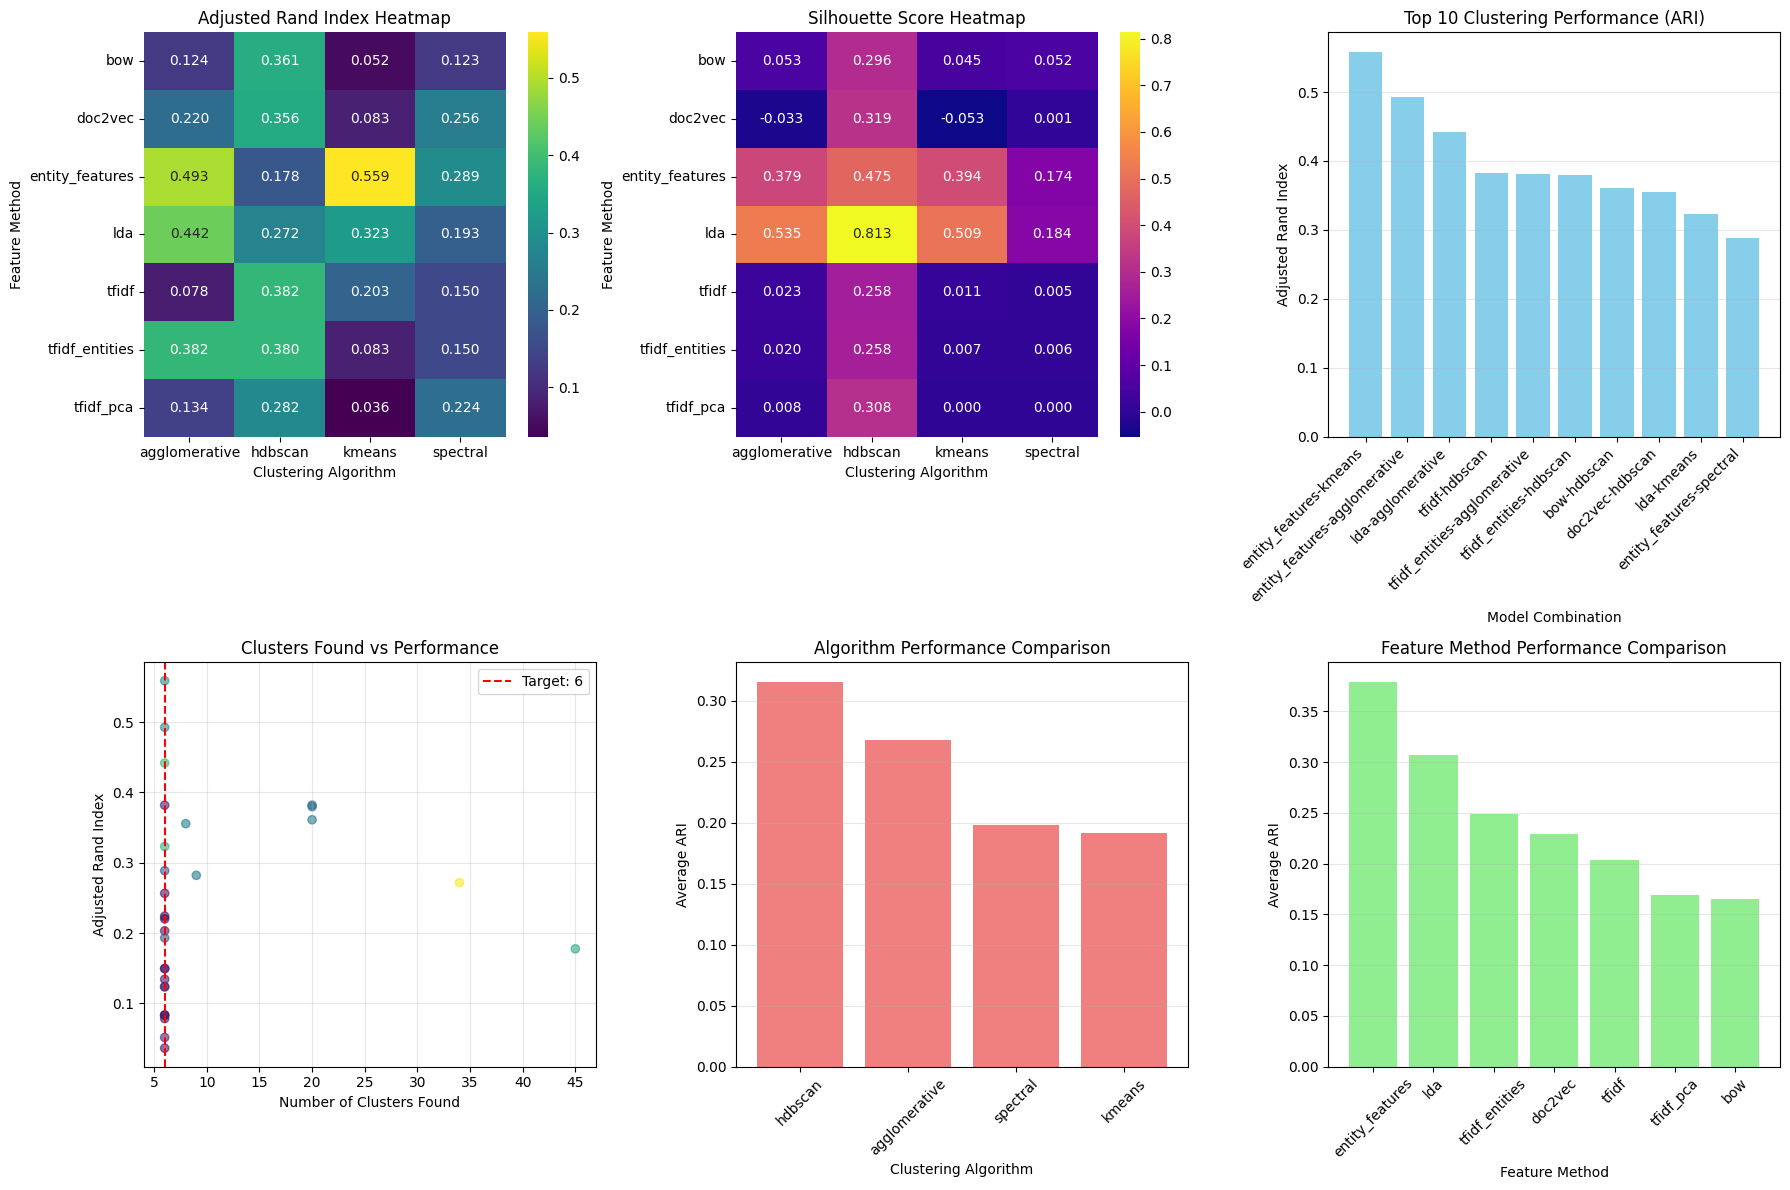


🎯 Clustering analysis completed successfully!


In [14]:
# ## 📊 Step 9: Clustering Evaluation and Comparison

def evaluate_clustering_performance(self):
    """
    Comprehensive clustering evaluation with multiple metrics
    Based on previous COVID-19 project experience with enhanced metrics
    """
    print("📊 Evaluating clustering performance...")
    print("="*60)

    if not self.clustering_results:
        raise ValueError("No clustering results available. Run apply_comprehensive_clustering() first.")

    # True labels for supervised evaluation (based on intents)
    true_labels = pd.Categorical(self.processed_data['intent']).codes
    intent_names = pd.Categorical(self.processed_data['intent']).categories.tolist()

    print(f"📋 True labels: {len(intent_names)} unique intents")
    for i, intent in enumerate(intent_names):
        count = np.sum(true_labels == i)
        print(f"   {intent}: {count} samples")

    evaluation_results = []

    for feature_name, feature_data in self.clustering_results.items():
        X = feature_data['vectors']

        for alg_name, alg_results in feature_data['clustering_results'].items():
            labels = alg_results['labels']

            print(f"\n🔍 Evaluating: {feature_name.upper()}-{alg_name.upper()}")

            # Skip if too few clusters or too many noise points
            unique_labels = np.unique(labels)
            if len(unique_labels) < 2:
                print("   ⚠️ Too few clusters found, skipping evaluation")
                continue

            # Handle noise points (HDBSCAN)
            if -1 in labels:
                mask = labels != -1
                labels_clean = labels[mask]
                true_labels_clean = true_labels[mask]
                X_clean = X[mask]
                noise_ratio = np.sum(labels == -1) / len(labels)
                print(f"   📊 Noise ratio: {noise_ratio:.3f}")
            else:
                labels_clean = labels
                true_labels_clean = true_labels
                X_clean = X
                noise_ratio = 0.0

            # Skip if too few samples after noise removal
            if len(labels_clean) < 10:
                print("   ⚠️ Too few samples after noise removal, skipping")
                continue

            try:
                # Supervised metrics (compare with true intent labels)
                ari = adjusted_rand_score(true_labels_clean, labels_clean)
                nmi = normalized_mutual_info_score(true_labels_clean, labels_clean)

                # Calculate accuracy-like metric (purity)
                from sklearn.metrics.cluster import contingency_matrix
                contingency = contingency_matrix(true_labels_clean, labels_clean)
                purity = np.sum(np.amax(contingency, axis=0)) / np.sum(contingency)

                # Unsupervised metrics (internal cluster quality)
                silhouette = silhouette_score(X_clean, labels_clean)
                calinski = calinski_harabasz_score(X_clean, labels_clean)
                davies_bouldin = davies_bouldin_score(X_clean, labels_clean)

                # Additional metrics
                n_clusters_found = len(np.unique(labels_clean))

                evaluation_results.append({
                    'feature_method': feature_name,
                    'clustering_algorithm': alg_name,
                    'adjusted_rand_index': ari,
                    'normalized_mutual_info': nmi,
                    'purity': purity,
                    'silhouette_score': silhouette,
                    'calinski_harabasz': calinski,
                    'davies_bouldin': davies_bouldin,
                    'n_clusters_found': n_clusters_found,
                    'n_samples_used': len(labels_clean),
                    'noise_ratio': noise_ratio
                })

                print(f"   📈 ARI: {ari:.3f}")
                print(f"   📈 Silhouette: {silhouette:.3f}")
                print(f"   📊 Clusters: {n_clusters_found}")

            except Exception as e:
                print(f"   ❌ Evaluation failed: {e}")
                continue

    # Convert to DataFrame and sort by ARI (primary metric)
    self.evaluation_metrics = pd.DataFrame(evaluation_results)

    if self.evaluation_metrics.empty:
        print("❌ No valid evaluation results generated")
        return None

    self.evaluation_metrics = self.evaluation_metrics.sort_values('adjusted_rand_index', ascending=False)

    # Save evaluation results
    self.evaluation_metrics.to_csv('clustering_evaluation_results.csv', index=False)

    print("\n✅ Clustering evaluation completed!")
    print("="*60)
    print("\n🏆 Top 10 performing combinations:")
    print("-" * 60)

    top_10 = self.evaluation_metrics.head(10)
    for _, row in top_10.iterrows():
        print(f"{row['feature_method']:15} + {row['clustering_algorithm']:15} | "
              f"ARI: {row['adjusted_rand_index']:.3f} | "
              f"Silhouette: {row['silhouette_score']:.3f}")

    # Best performing method
    if len(self.evaluation_metrics) > 0:
        best = self.evaluation_metrics.iloc[0]
        print(f"\n🥇 BEST PERFORMING COMBINATION:")
        print(f"   Feature Method: {best['feature_method'].upper()}")
        print(f"   Clustering Algorithm: {best['clustering_algorithm'].upper()}")
        print(f"   Adjusted Rand Index: {best['adjusted_rand_index']:.3f}")
        print(f"   Silhouette Score: {best['silhouette_score']:.3f}")
        print(f"   Purity: {best['purity']:.3f}")

    return self.evaluation_metrics

# Add evaluation method to processor class
HealthcareDataProcessor.evaluate_clustering_performance = evaluate_clustering_performance

print("✅ Clustering evaluation method added to processor")

# ## 🚀 Execute Clustering Pipeline

print("\n" + "="*80)
print("🚀 EXECUTING CLUSTERING ANALYSIS PIPELINE")
print("="*80)

# Execute the clustering pipeline
clustering_results = processor.apply_comprehensive_clustering()

# Execute the evaluation pipeline
evaluation_metrics = processor.evaluate_clustering_performance()

# Create clustering results visualization
if evaluation_metrics is not None and len(evaluation_metrics) > 0:
    print("\n📊 Creating clustering analysis visualization...")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # 1. Performance comparison heatmap
    pivot_ari = evaluation_metrics.pivot_table(
        values='adjusted_rand_index',
        index='feature_method',
        columns='clustering_algorithm',
        aggfunc='mean'
    )

    sns.heatmap(pivot_ari, annot=True, fmt='.3f', cmap='viridis', ax=axes[0])
    axes[0].set_title('Adjusted Rand Index Heatmap')
    axes[0].set_xlabel('Clustering Algorithm')
    axes[0].set_ylabel('Feature Method')

    # 2. Silhouette score comparison
    pivot_sil = evaluation_metrics.pivot_table(
        values='silhouette_score',
        index='feature_method',
        columns='clustering_algorithm',
        aggfunc='mean'
    )

    sns.heatmap(pivot_sil, annot=True, fmt='.3f', cmap='plasma', ax=axes[1])
    axes[1].set_title('Silhouette Score Heatmap')
    axes[1].set_xlabel('Clustering Algorithm')
    axes[1].set_ylabel('Feature Method')

    # 3. Top 10 performers bar chart
    top_10 = evaluation_metrics.head(10)
    model_names = [f"{row['feature_method']}-{row['clustering_algorithm']}"
                   for _, row in top_10.iterrows()]

    axes[2].bar(range(len(top_10)), top_10['adjusted_rand_index'], color='skyblue')
    axes[2].set_xlabel('Model Combination')
    axes[2].set_ylabel('Adjusted Rand Index')
    axes[2].set_title('Top 10 Clustering Performance (ARI)')
    axes[2].set_xticks(range(len(top_10)))
    axes[2].set_xticklabels(model_names, rotation=45, ha='right')
    axes[2].grid(axis='y', alpha=0.3)

    # 4. Clusters found vs target
    target_clusters = len(processor.processed_data['intent'].unique())
    axes[3].scatter(evaluation_metrics['n_clusters_found'],
                    evaluation_metrics['adjusted_rand_index'],
                    alpha=0.6, c=evaluation_metrics['silhouette_score'],
                    cmap='viridis')
    axes[3].axvline(x=target_clusters, color='red', linestyle='--',
                    label=f'Target: {target_clusters}')
    axes[3].set_xlabel('Number of Clusters Found')
    axes[3].set_ylabel('Adjusted Rand Index')
    axes[3].set_title('Clusters Found vs Performance')
    axes[3].legend()
    axes[3].grid(alpha=0.3)

    # 5. Algorithm performance comparison
    alg_performance = evaluation_metrics.groupby('clustering_algorithm')['adjusted_rand_index'].mean().sort_values(ascending=False)
    axes[4].bar(alg_performance.index, alg_performance.values, color='lightcoral')
    axes[4].set_xlabel('Clustering Algorithm')
    axes[4].set_ylabel('Average ARI')
    axes[4].set_title('Algorithm Performance Comparison')
    axes[4].tick_params(axis='x', rotation=45)
    axes[4].grid(axis='y', alpha=0.3)

    # 6. Feature method performance comparison
    feature_performance = evaluation_metrics.groupby('feature_method')['adjusted_rand_index'].mean().sort_values(ascending=False)
    axes[5].bar(feature_performance.index, feature_performance.values, color='lightgreen')
    axes[5].set_xlabel('Feature Method')
    axes[5].set_ylabel('Average ARI')
    axes[5].set_title('Feature Method Performance Comparison')
    axes[5].tick_params(axis='x', rotation=45)
    axes[5].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('clustering_analysis_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n🎯 Clustering analysis completed successfully!")
else:
    print("⚠️ No evaluation metrics available for visualization")

print("="*80)

In [15]:
# ## 📈 Step 10: Comprehensive Visualizations (Person 1 Requirement)

def create_comprehensive_visualizations(self):
    """
    Create comprehensive visualizations including chatbot flow + ontology diagrams
    Implements Person 1 visualization requirements
    """
    print("📈 Creating comprehensive visualizations...")
    print("="*60)

    if self.evaluation_metrics is None or len(self.evaluation_metrics) == 0:
        print("❌ No evaluation metrics available for visualization")
        return

    # Create output directory
    os.makedirs('clustering_visualizations', exist_ok=True)

    # 1. t-SNE Visualizations for Best Methods
    self._plot_tsne_clusters()

    # 2. Chatbot Flow Diagram (Person 1 requirement)
    self._create_chatbot_flow_diagram()

    # 3. Ontology Network Visualization (Person 1 requirement)
    self._create_ontology_visualization()

    # 4. Cluster Analysis Visualizations
    self._create_cluster_analysis_plots()

    # 5. Feature Importance Analysis
    self._create_feature_importance_plots()

    print("✅ Comprehensive visualizations completed!")

def _plot_tsne_clusters(self):
    """Create t-SNE visualizations for best performing methods"""
    print("🎨 Creating t-SNE cluster visualizations...")

    # Get top 3 performing combinations
    top_combinations = self.evaluation_metrics.head(3)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (_, row) in enumerate(top_combinations.iterrows()):
        feature_name = row['feature_method']
        alg_name = row['clustering_algorithm']

        # Get the vectors and labels
        X = self.clustering_results[feature_name]['vectors']
        labels = self.clustering_results[feature_name]['clustering_results'][alg_name]['labels']

        # Apply t-SNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(X)

        # Plot
        scatter = axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels,
                                  cmap='tab10', alpha=0.7, s=30)
        axes[idx].set_title(f'{feature_name.upper()}-{alg_name.upper()}\nARI: {row["adjusted_rand_index"]:.3f}')
        axes[idx].set_xlabel('t-SNE Component 1')
        axes[idx].set_ylabel('t-SNE Component 2')

        # Add colorbar
        plt.colorbar(scatter, ax=axes[idx])

    plt.tight_layout()
    plt.savefig('clustering_visualizations/tsne_best_methods.png', dpi=300, bbox_inches='tight')
    plt.show()

def _create_chatbot_flow_diagram(self):
    """Create chatbot conversation flow diagram"""
    print("🤖 Creating chatbot flow diagram...")

    # Create a flowchart showing the chatbot interaction process
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    # Define flowchart elements
    flow_elements = {
        'User Input': (2, 9, 'lightblue'),
        'Text Preprocessing': (2, 8, 'lightgreen'),
        'Entity Extraction': (2, 7, 'lightyellow'),
        'Intent Classification': (2, 6, 'lightcoral'),
        'Ontology Lookup': (2, 5, 'lightpink'),
        'Response Generation': (2, 4, 'lightgray'),
        'Output to User': (2, 3, 'lightblue')
    }

    # Draw flowchart boxes
    for element, (x, y, color) in flow_elements.items():
        box = plt.Rectangle((x-0.4, y-0.3), 0.8, 0.6,
                           facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(box)
        ax.text(x, y, element, ha='center', va='center', fontsize=10, weight='bold')

    # Draw arrows
    arrow_props = dict(arrowstyle='->', lw=2, color='darkblue')
    for i in range(len(flow_elements)-1):
        ax.annotate('', xy=(2, 8.7-i), xytext=(2, 9.3-i), arrowprops=arrow_props)

    # Add side information boxes
    info_boxes = {
        'Input Examples': (0.3, 8, ['"What are symptoms of COVID-19?"',
                                   '"Should I see a doctor for fever?"',
                                   '"What food helps with flu?"']),
        'Processing Steps': (0.3, 6, ['Remove stopwords', 'Lemmatization',
                                     'Entity recognition', 'Intent mapping']),
        'Competency Questions': (3.7, 6, ['DiseaseToSymptom', 'SymptomToDisease',
                                         'TreatmentRecommendation', 'RiskAssessment',
                                         'FoodAdvice', 'PreventionAdvice'])
    }

    for title, (x, y, items) in info_boxes.items():
        # Title box
        title_box = plt.Rectangle((x-0.35, y+0.5), 0.7, 0.3,
                                 facecolor='lightyellow', edgecolor='black')
        ax.add_patch(title_box)
        ax.text(x, y+0.65, title, ha='center', va='center', fontsize=9, weight='bold')

        # Items
        for i, item in enumerate(items):
            ax.text(x, y+0.2-i*0.3, f"• {item}", ha='center', va='center', fontsize=8)

    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(2, 10)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Healthcare Chatbot Conversation Flow', fontsize=16, weight='bold', pad=20)

    plt.savefig('clustering_visualizations/chatbot_flow_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()

def _create_ontology_visualization(self):
    """Create medical ontology network visualization"""
    print("🏥 Creating medical ontology visualization...")

    # Create network graph
    G = nx.Graph()

    # Add central node
    G.add_node('Medical Knowledge Base', node_type='root')

    # Add category nodes and connect to root
    categories = list(self.medical_ontology.keys())
    for category in categories:
        G.add_node(category, node_type='category')
        G.add_edge('Medical Knowledge Base', category)

    # Add sample entities for each category
    for category, entities in self.medical_ontology.items():
        sample_entities = entities[:5]  # First 5 entities
        for entity in sample_entities:
            G.add_node(entity, node_type='entity', category=category)
            G.add_edge(category, entity)

    # Create layout
    pos = nx.spring_layout(G, k=3, iterations=50)

    # Create figure
    plt.figure(figsize=(16, 12))

    # Draw nodes by type
    node_colors = {
        'root': 'red',
        'category': 'lightblue',
        'entity': 'lightgreen'
    }

    for node_type, color in node_colors.items():
        nodes = [node for node, attr in G.nodes(data=True)
                if attr.get('node_type') == node_type]

        if node_type == 'root':
            nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color,
                                 node_size=2000, alpha=0.9)
        elif node_type == 'category':
            nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color,
                                 node_size=1000, alpha=0.8)
        else:
            nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color,
                                 node_size=200, alpha=0.6)

    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.6, width=1)

    # Draw labels for root and categories only
    important_nodes = ['Medical Knowledge Base'] + categories
    important_labels = {node: node for node in important_nodes}
    nx.draw_networkx_labels(G, pos, labels=important_labels, font_size=10, font_weight='bold')

    plt.title('Healthcare Ontology Network\n(Based on DialogFlow Project)',
              fontsize=16, weight='bold', pad=20)
    plt.axis('off')

    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
                  markersize=15, label='Knowledge Base'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
                  markersize=12, label='Categories'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen',
                  markersize=8, label='Entities')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.savefig('clustering_visualizations/ontology_network.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Create detailed ontology statistics
    plt.figure(figsize=(12, 8))

    # Entity counts per category
    entity_counts = {cat: len(entities) for cat, entities in self.medical_ontology.items()}

    plt.subplot(2, 2, 1)
    plt.bar(entity_counts.keys(), entity_counts.values(), color='skyblue')
    plt.title('Entities per Ontology Category')
    plt.xlabel('Category')
    plt.ylabel('Number of Entities')
    plt.xticks(rotation=45, ha='right')

    # Intent distribution
    plt.subplot(2, 2, 2)
    intent_counts = self.processed_data['intent'].value_counts()
    plt.pie(intent_counts.values, labels=intent_counts.index, autopct='%1.1f%%')
    plt.title('Intent Distribution in Dataset')

    # Entity usage in dataset
    plt.subplot(2, 2, 3)
    entity_usage = self.processed_data['entity_count'].value_counts().sort_index()
    plt.bar(entity_usage.index, entity_usage.values, color='lightgreen')
    plt.title('Entity Usage Distribution')
    plt.xlabel('Number of Entities per Sample')
    plt.ylabel('Number of Samples')

    # Competency question mapping
    plt.subplot(2, 2, 4)
    cq_mapping = {
        'DiseaseToSymptom': 'CQ1: Disease → Symptoms',
        'SymptomToDisease': 'CQ2: Symptoms → Disease',
        'TreatmentRecommendation': 'CQ3: Treatment Advice',
        'RiskAssessment': 'CQ4: Risk Assessment',
        'FoodAdvice': 'CQ5: Nutritional Advice',
        'PreventionAdvice': 'CQ6: Prevention Advice'
    }

    cq_counts = self.processed_data['intent'].map(cq_mapping).value_counts()
    plt.barh(range(len(cq_counts)), cq_counts.values, color='lightcoral')
    plt.yticks(range(len(cq_counts)), cq_counts.index)
    plt.title('Competency Questions Coverage')
    plt.xlabel('Number of Samples')

    plt.tight_layout()
    plt.savefig('clustering_visualizations/ontology_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()

def _create_cluster_analysis_plots(self):
    """Create detailed cluster analysis plots"""
    print("📊 Creating cluster analysis plots...")

    # Get best performing method
    best_method = self.evaluation_metrics.iloc[0]
    feature_name = best_method['feature_method']
    alg_name = best_method['clustering_algorithm']

    print(f"📊 Analyzing best method: {feature_name.upper()}-{alg_name.upper()}")

    # Get predictions and true labels
    pred_labels = self.clustering_results[feature_name]['clustering_results'][alg_name]['labels']
    true_labels = pd.Categorical(self.processed_data['intent']).codes

    # Remove noise points if present
    if -1 in pred_labels:
        mask = pred_labels != -1
        pred_clean = pred_labels[mask]
        true_clean = true_labels[mask]
        data_clean = self.processed_data[mask].copy()
    else:
        pred_clean = pred_labels
        true_clean = true_labels
        data_clean = self.processed_data.copy()

    data_clean['predicted_cluster'] = pred_clean
    data_clean['true_label_code'] = true_clean

    # Create comprehensive cluster analysis
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # 1. Confusion Matrix
    cm = confusion_matrix(true_clean, pred_clean)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix\n{feature_name.upper()}-{alg_name.upper()}')
    axes[0].set_xlabel('Predicted Cluster')
    axes[0].set_ylabel('True Intent')

    # 2. Cluster Size Distribution
    cluster_counts = pd.Series(pred_clean).value_counts().sort_index()
    axes[1].bar(cluster_counts.index, cluster_counts.values, color='lightcoral')
    axes[1].set_title('Cluster Size Distribution')
    axes[1].set_xlabel('Cluster ID')
    axes[1].set_ylabel('Number of Samples')

    # 3. Intent vs Cluster Mapping
    intent_cluster_map = data_clean.groupby(['intent', 'predicted_cluster']).size().unstack(fill_value=0)
    sns.heatmap(intent_cluster_map, annot=True, fmt='d', cmap='viridis', ax=axes[2])
    axes[2].set_title('Intent vs Cluster Mapping')
    axes[2].set_xlabel('Predicted Cluster')
    axes[2].set_ylabel('True Intent')

    # 4. Silhouette Analysis
    if len(np.unique(pred_clean)) > 1:
        from sklearn.metrics import silhouette_samples
        X = self.clustering_results[feature_name]['vectors']
        if -1 in pred_labels:
            X_clean = X[mask]
        else:
            X_clean = X

        silhouette_vals = silhouette_samples(X_clean, pred_clean)

        y_lower = 10
        for i in range(len(np.unique(pred_clean))):
            cluster_silhouette_vals = silhouette_vals[pred_clean == i]
            cluster_silhouette_vals.sort()

            size_cluster_i = cluster_silhouette_vals.shape[0]
            y_upper = y_lower + size_cluster_i

            color = plt.cm.nipy_spectral(float(i) / len(np.unique(pred_clean)))
            axes[3].fill_betweenx(np.arange(y_lower, y_upper),
                                0, cluster_silhouette_vals,
                                facecolor=color, edgecolor=color, alpha=0.7)

            axes[3].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        silhouette_avg = silhouette_score(X_clean, pred_clean)
        axes[3].axvline(x=silhouette_avg, color="red", linestyle="--")
        axes[3].set_title(f'Silhouette Analysis\nAvg Score: {silhouette_avg:.3f}')
        axes[3].set_xlabel('Silhouette Coefficient Values')
        axes[3].set_ylabel('Cluster Label')

    # 5. Performance Metrics Comparison
    metrics = ['adjusted_rand_index', 'silhouette_score', 'purity', 'calinski_harabasz']
    metric_values = [best_method[metric] for metric in metrics]
    metric_names = ['ARI', 'Silhouette', 'Purity', 'Calinski-H']

    bars = axes[4].bar(metric_names, metric_values, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
    axes[4].set_title('Performance Metrics\n(Best Method)')
    axes[4].set_ylabel('Score')

    # Add value labels on bars
    for bar, value in zip(bars, metric_values):
        axes[4].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom')

    # 6. Error Analysis by Intent
    misclassified = data_clean[data_clean['predicted_cluster'] != data_clean['true_label_code']]
    error_by_intent = misclassified['intent'].value_counts()
    total_by_intent = data_clean['intent'].value_counts()
    error_rates = (error_by_intent / total_by_intent * 100).fillna(0)

    axes[5].bar(error_rates.index, error_rates.values, color='orange')
    axes[5].set_title('Error Rate by Intent')
    axes[5].set_xlabel('Intent')
    axes[5].set_ylabel('Error Rate (%)')
    axes[5].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('clustering_visualizations/cluster_analysis_detailed.png', dpi=300, bbox_inches='tight')
    plt.show()

def _create_feature_importance_plots(self):
    """Create feature importance analysis plots"""
    print("🔍 Creating feature importance analysis...")

    # Focus on TF-IDF features for interpretability
    if 'tfidf' not in self.feature_vectors:
        print("⚠️ TF-IDF features not available for importance analysis")
        return

    # Get best TF-IDF method
    tfidf_results = self.evaluation_metrics[self.evaluation_metrics['feature_method'] == 'tfidf']
    if tfidf_results.empty:
        print("⚠️ No TF-IDF clustering results available")
        return

    best_tfidf = tfidf_results.iloc[0]
    alg_name = best_tfidf['clustering_algorithm']

    # Get clustering labels and TF-IDF matrix
    labels = self.clustering_results['tfidf']['clustering_results'][alg_name]['labels']
    tfidf_matrix = self.feature_vectors['tfidf']

    # Get feature names
    feature_names = self.vectorizers['tfidf'].get_feature_names_out()

    # Create feature importance plots only for KMeans (has interpretable centers)
    if alg_name == 'kmeans':
        try:
            # Refit KMeans to get centers
            kmeans = KMeans(n_clusters=len(np.unique(labels[labels != -1])), random_state=42)
            kmeans.fit(tfidf_matrix)

            # Plot cluster centers for top features
            centers = kmeans.cluster_centers_

            # Get top features per cluster
            fig, axes = plt.subplots(2, 2, figsize=(16, 10))
            axes = axes.flatten()

            for i, cluster_center in enumerate(centers[:4]):  # Top 4 clusters
                top_indices = cluster_center.argsort()[-20:][::-1]  # Top 20 features
                top_features = [feature_names[idx] for idx in top_indices]
                top_weights = cluster_center[top_indices]

                axes[i].barh(range(len(top_features)), top_weights, color='skyblue')
                axes[i].set_yticks(range(len(top_features)))
                axes[i].set_yticklabels(top_features)
                axes[i].set_title(f'Cluster {i} - Top Features')
                axes[i].set_xlabel('TF-IDF Weight')

            plt.tight_layout()
            plt.savefig('clustering_visualizations/feature_importance_tfidf.png', dpi=300, bbox_inches='tight')
            plt.show()

        except Exception as e:
            print(f"❌ Feature importance analysis failed: {e}")

# Add visualization methods to processor class
HealthcareDataProcessor.create_comprehensive_visualizations = create_comprehensive_visualizations
HealthcareDataProcessor._plot_tsne_clusters = _plot_tsne_clusters
HealthcareDataProcessor._create_chatbot_flow_diagram = _create_chatbot_flow_diagram
HealthcareDataProcessor._create_ontology_visualization = _create_ontology_visualization
HealthcareDataProcessor._create_cluster_analysis_plots = _create_cluster_analysis_plots
HealthcareDataProcessor._create_feature_importance_plots = _create_feature_importance_plots

print("✅ Visualization methods added to processor")



✅ Visualization methods added to processor


✅ Error analysis methods added to processor

🚀 EXECUTING VISUALIZATION AND ERROR ANALYSIS PIPELINE
📈 Creating comprehensive visualizations...
🎨 Creating t-SNE cluster visualizations...


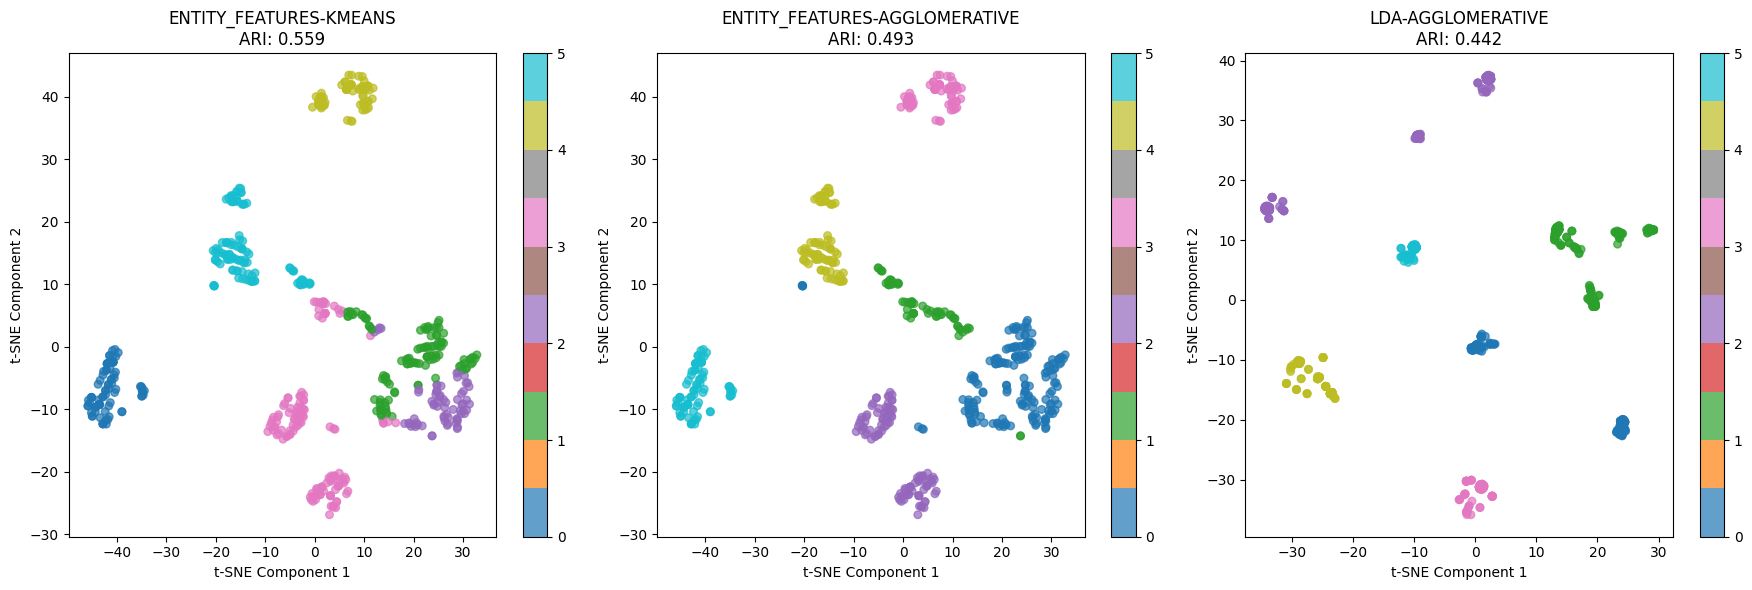

🤖 Creating chatbot flow diagram...


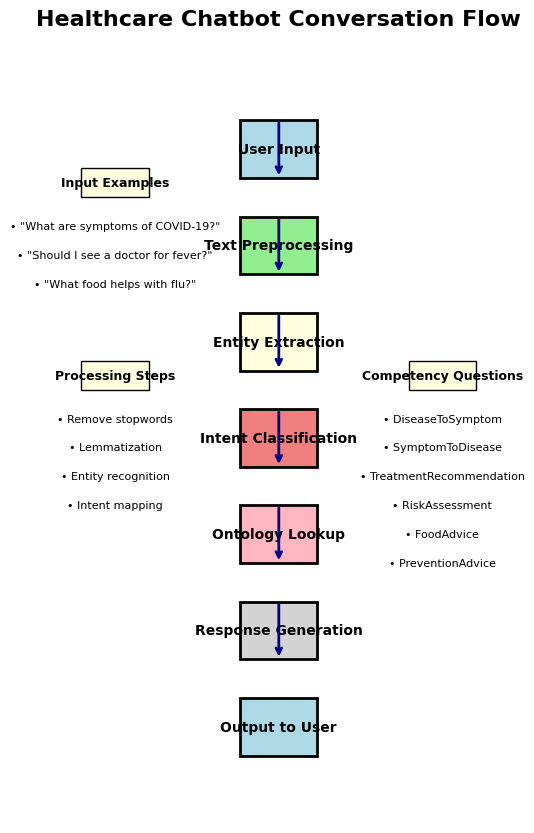

🏥 Creating medical ontology visualization...


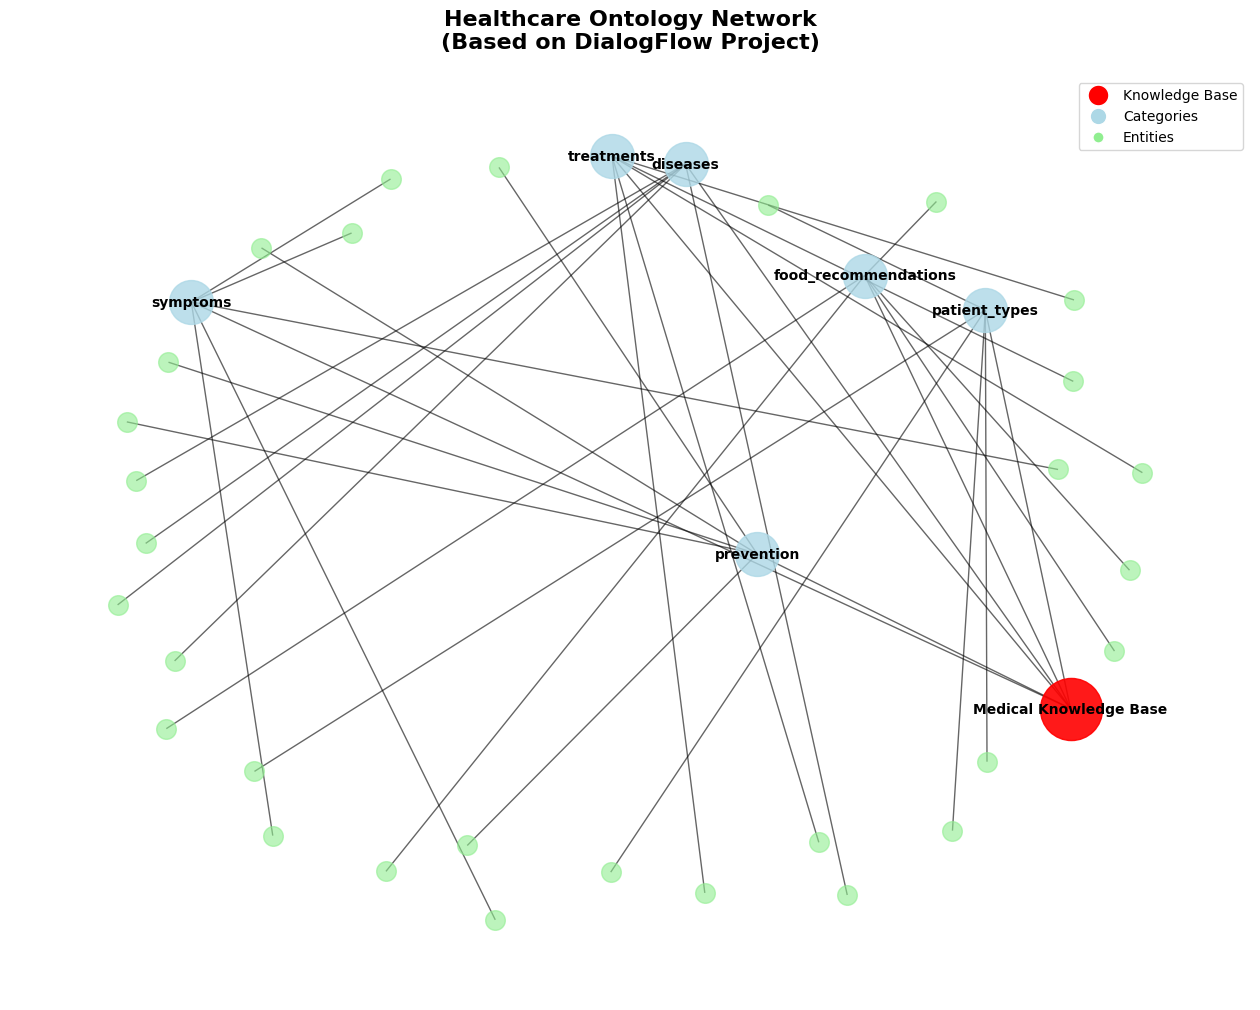

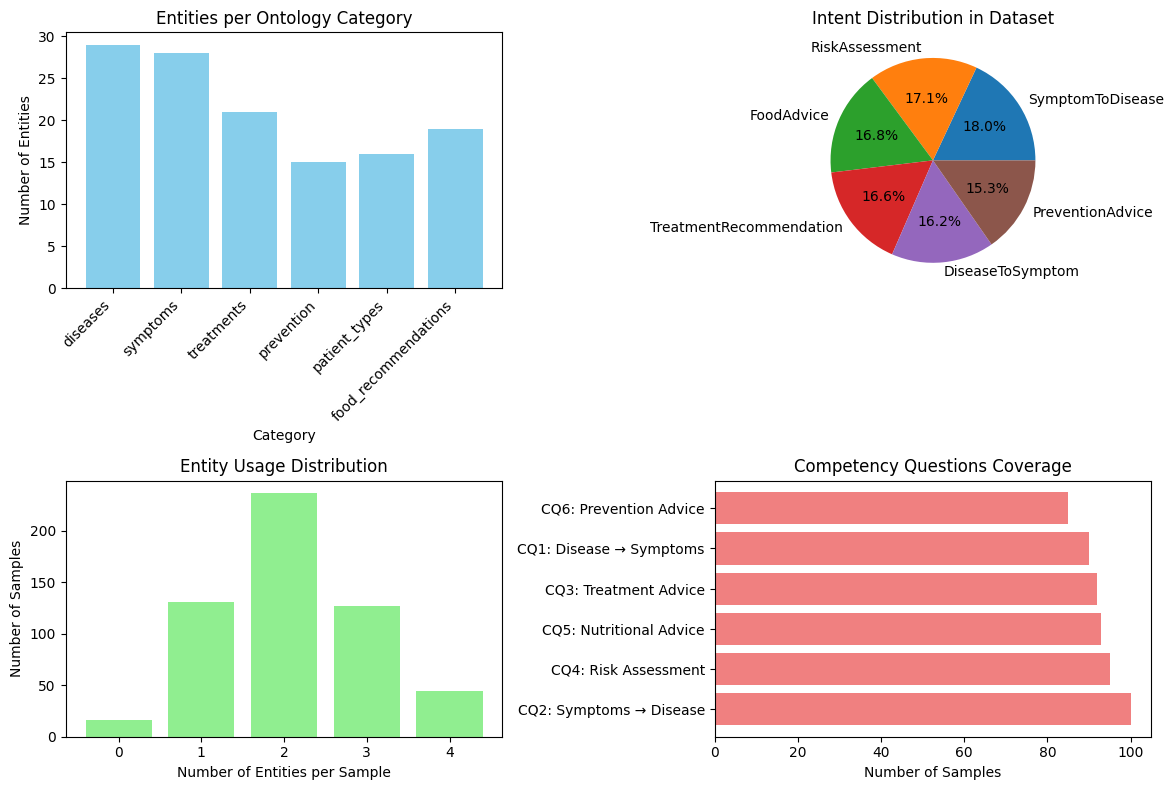

📊 Creating cluster analysis plots...
📊 Analyzing best method: ENTITY_FEATURES-KMEANS


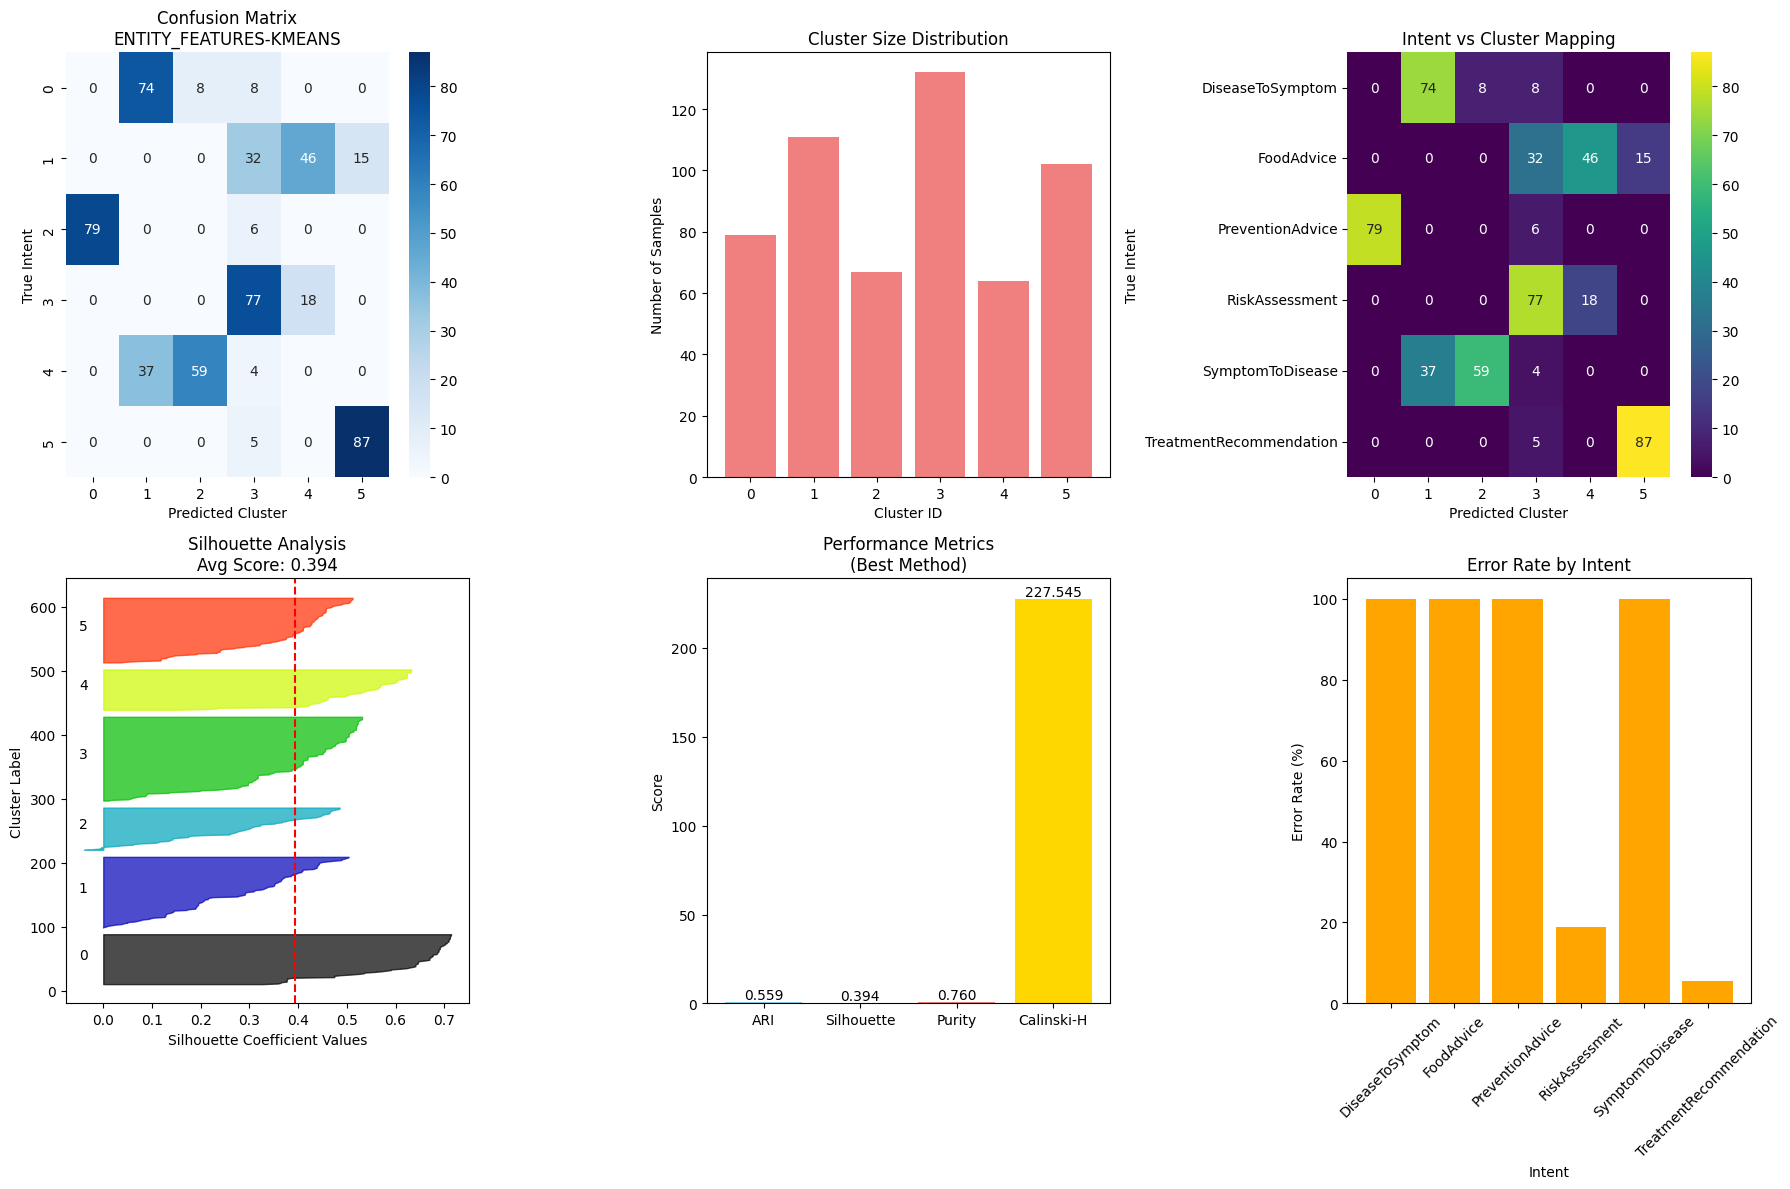

🔍 Creating feature importance analysis...
✅ Comprehensive visualizations completed!
🔬 Performing comprehensive error analysis...
📊 Analyzing best method: ENTITY_FEATURES-KMEANS
📊 Classification Results:
   Correctly classified: 164 / 555 (29.5%)
   Misclassified: 391 / 555 (70.5%)

🎯 Error analysis by intent:
   DiseaseToSymptom         :  90/ 90 errors (100.0% error rate)
   SymptomToDisease         : 100/100 errors (100.0% error rate)
   TreatmentRecommendation  :   5/ 92 errors (  5.4% error rate)
   RiskAssessment           :  18/ 95 errors ( 18.9% error rate)
   FoodAdvice               :  93/ 93 errors (100.0% error rate)
   PreventionAdvice         :  85/ 85 errors (100.0% error rate)
☁️ Creating error analysis word clouds...


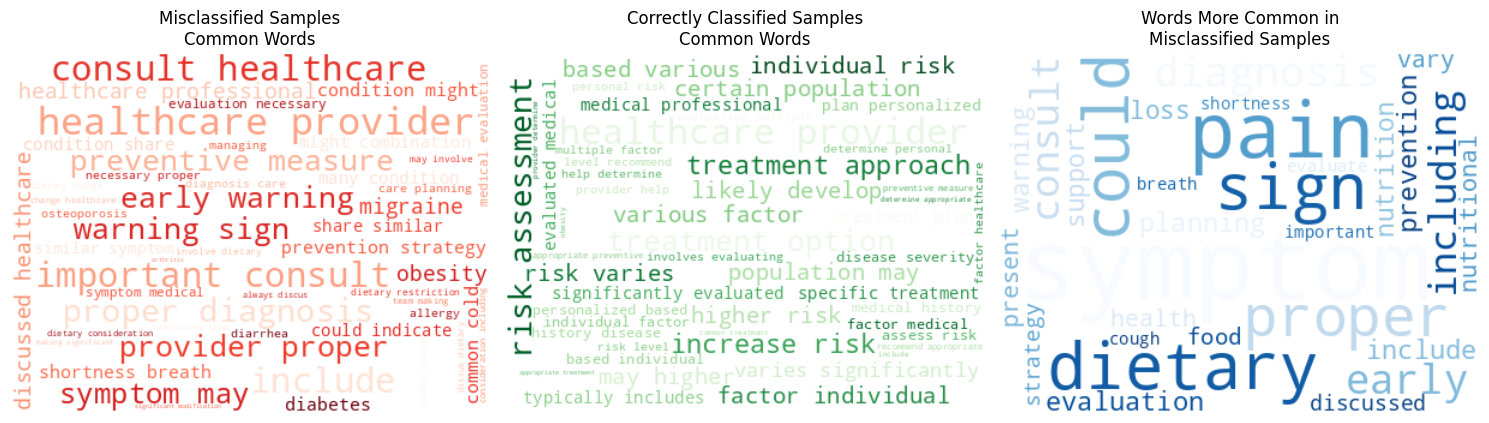


📝 Sample misclassified examples:
------------------------------------------------------------

Example 1:
   Question: How does malaria present in patients?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 1
   Entities Found: 2

Example 2:
   Question: What are the early warning signs of allergies?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 1
   Entities Found: 2

Example 3:
   Question: What are the symptoms of migraine?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 1
   Entities Found: 3

Example 4:
   Question: What are the symptoms of depression?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 1
   Entities Found: 3

Example 5:
   Question: What are the early warning signs of tuberculosis?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 1
   Entities Found: 3

📊 Error Analysis Summary:
   Overall Accuracy: 0.295
   Misclassified Samples: 391
   Intent-wise Analysis saved to: error_analysis_by_intent.csv

🎯 Visualization and 

In [16]:
# ## 🔬 Step 11: Error Analysis and Interpretability

def perform_comprehensive_error_analysis(self):
    """Perform detailed error analysis and interpretability study"""
    print("🔬 Performing comprehensive error analysis...")
    print("="*60)

    # Get best performing method
    best_method = self.evaluation_metrics.iloc[0]
    feature_name = best_method['feature_method']
    alg_name = best_method['clustering_algorithm']

    print(f"📊 Analyzing best method: {feature_name.upper()}-{alg_name.upper()}")

    # Get predictions and true labels
    pred_labels = self.clustering_results[feature_name]['clustering_results'][alg_name]['labels']
    true_labels = pd.Categorical(self.processed_data['intent']).codes
    intent_names = pd.Categorical(self.processed_data['intent']).categories.tolist()

    # Remove noise points if present
    if -1 in pred_labels:
        mask = pred_labels != -1
        pred_clean = pred_labels[mask]
        true_clean = true_labels[mask]
        data_clean = self.processed_data[mask].copy()
    else:
        pred_clean = pred_labels
        true_clean = true_labels
        data_clean = self.processed_data.copy()

    data_clean['predicted_cluster'] = pred_clean
    data_clean['true_label_code'] = true_clean

    # Analyze misclassified samples
    misclassified = data_clean[data_clean['predicted_cluster'] != data_clean['true_label_code']]
    correctly_classified = data_clean[data_clean['predicted_cluster'] == data_clean['true_label_code']]

    print(f"📊 Classification Results:")
    print(f"   Correctly classified: {len(correctly_classified)} / {len(data_clean)} ({len(correctly_classified)/len(data_clean)*100:.1f}%)")
    print(f"   Misclassified: {len(misclassified)} / {len(data_clean)} ({len(misclassified)/len(data_clean)*100:.1f}%)")

    # Detailed analysis by intent
    print(f"\n🎯 Error analysis by intent:")
    intent_analysis = []

    for intent in data_clean['intent'].unique():
        intent_data = data_clean[data_clean['intent'] == intent]
        intent_errors = len(intent_data[intent_data['predicted_cluster'] != intent_data['true_label_code']])
        error_rate = intent_errors / len(intent_data) * 100 if len(intent_data) > 0 else 0

        intent_analysis.append({
            'intent': intent,
            'total_samples': len(intent_data),
            'errors': intent_errors,
            'error_rate': error_rate,
            'accuracy': 100 - error_rate
        })

        print(f"   {intent:25}: {intent_errors:3}/{len(intent_data):3} errors ({error_rate:5.1f}% error rate)")

    # Create error analysis summary
    error_df = pd.DataFrame(intent_analysis)
    error_df.to_csv('clustering_visualizations/error_analysis_by_intent.csv', index=False)

    # Word cloud analysis for misclassified vs correctly classified
    self._create_error_wordclouds(misclassified, correctly_classified)

    # Sample misclassified examples
    print(f"\n📝 Sample misclassified examples:")
    print("-" * 60)

    for i, (_, row) in enumerate(misclassified.head(5).iterrows()):
        print(f"\nExample {i+1}:")
        print(f"   Question: {row['original_question'][:100]}...")
        print(f"   True Intent: {row['intent']}")
        print(f"   Predicted Cluster: {row['predicted_cluster']}")
        print(f"   Entities Found: {row['entity_count']}")

    return {
        'misclassified_samples': misclassified,
        'correctly_classified_samples': correctly_classified,
        'intent_analysis': error_df,
        'overall_accuracy': len(correctly_classified) / len(data_clean)
    }

def _create_error_wordclouds(self, misclassified, correctly_classified):
    """Create word clouds for error analysis"""
    print("☁️ Creating error analysis word clouds...")

    if len(misclassified) == 0:
        print("⚠️ No misclassified samples found")
        return

    # Combine texts
    misclassified_text = ' '.join(misclassified['combined_text'].astype(str))
    correctly_classified_text = ' '.join(correctly_classified['combined_text'].astype(str))

    # Create word clouds
    plt.figure(figsize=(15, 5))

    # Misclassified samples word cloud
    plt.subplot(1, 3, 1)
    if len(misclassified_text.strip()) > 0:
        wordcloud_misc = WordCloud(
            width=400, height=300,
            background_color='white',
            colormap='Reds',
            max_words=50,
            stopwords=self.stop_words
        ).generate(misclassified_text)
        plt.imshow(wordcloud_misc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Misclassified Samples\nCommon Words')

    # Correctly classified samples word cloud
    plt.subplot(1, 3, 2)
    if len(correctly_classified_text.strip()) > 0:
        wordcloud_correct = WordCloud(
            width=400, height=300,
            background_color='white',
            colormap='Greens',
            max_words=50,
            stopwords=self.stop_words
        ).generate(correctly_classified_text)
        plt.imshow(wordcloud_correct, interpolation='bilinear')
        plt.axis('off')
        plt.title('Correctly Classified Samples\nCommon Words')

    # Difference analysis
    plt.subplot(1, 3, 3)

    # Simple frequency comparison
    misc_words = Counter(misclassified_text.split())
    correct_words = Counter(correctly_classified_text.split())

    # Find words more common in misclassified samples
    diff_words = {}
    for word, count in misc_words.items():
        if len(word) > 3 and word.lower() not in self.stop_words:
            misc_freq = count / len(misclassified) if len(misclassified) > 0 else 0
            correct_freq = correct_words.get(word, 0) / len(correctly_classified) if len(correctly_classified) > 0 else 0
            if misc_freq > correct_freq * 1.5:  # At least 50% more frequent
                diff_words[word] = misc_freq - correct_freq

    if diff_words:
        wordcloud_diff = WordCloud(
            width=400, height=300,
            background_color='white',
            colormap='Blues',
            max_words=30
        ).generate_from_frequencies(diff_words)
        plt.imshow(wordcloud_diff, interpolation='bilinear')
        plt.axis('off')
        plt.title('Words More Common in\nMisclassified Samples')
    else:
        plt.text(0.5, 0.5, 'No significant\ndifferences found',
                ha='center', va='center', transform=plt.gca().transAxes,
                fontsize=12)
        plt.axis('off')
        plt.title('Difference Analysis')

    plt.tight_layout()
    plt.savefig('clustering_visualizations/error_analysis_wordclouds.png', dpi=300, bbox_inches='tight')
    plt.show()

# Add error analysis methods to processor class
HealthcareDataProcessor.perform_comprehensive_error_analysis = perform_comprehensive_error_analysis
HealthcareDataProcessor._create_error_wordclouds = _create_error_wordclouds

print("✅ Error analysis methods added to processor")

# ## 🚀 Execute Visualization and Error Analysis Pipeline

print("\n" + "="*80)
print("🚀 EXECUTING VISUALIZATION AND ERROR ANALYSIS PIPELINE")
print("="*80)

# Execute the visualization pipeline
processor.create_comprehensive_visualizations()

# Execute the error analysis pipeline
error_analysis_results = processor.perform_comprehensive_error_analysis()

if error_analysis_results:
    print(f"\n📊 Error Analysis Summary:")
    print(f"   Overall Accuracy: {error_analysis_results['overall_accuracy']:.3f}")
    print(f"   Misclassified Samples: {len(error_analysis_results['misclassified_samples'])}")
    print(f"   Intent-wise Analysis saved to: error_analysis_by_intent.csv")

print(f"\n🎯 Visualization and error analysis completed!")
print("="*80)

In [17]:
# ## 📋 Step 12: Final Summary and Handover Documentation

def generate_final_summary_report(self):
    """Generate comprehensive final summary report for handover"""
    print("📋 Generating final summary report for handover...")
    print("="*70)

    # Collect all results
    summary_data = {
        'project_info': {
            'title': 'Healthcare Assistant Chatbot - Person 1 Implementation',
            'tasks_completed': [
                'Data Preparation (2.5%)',
                'Text Feature Engineering (3%)',
                'Clustering Analysis (3%)',
                'Visualization & Demonstration'
            ],
            'completion_date': datetime.now().isoformat(),
            'total_samples_processed': len(self.processed_data),
            'feature_methods_implemented': len(self.feature_vectors),
            'clustering_combinations_tested': len(self.evaluation_metrics) if self.evaluation_metrics is not None else 0
        },
        'data_summary': {
            'total_samples': len(self.processed_data),
            'intent_distribution': self.processed_data['intent'].value_counts().to_dict(),
            'source_distribution': self.processed_data['source'].value_counts().to_dict(),
            'avg_text_length': self.processed_data['text_length'].mean(),
            'avg_word_count': self.processed_data['word_count'].mean(),
            'avg_entity_count': self.processed_data['entity_count'].mean()
        },
        'feature_engineering_summary': {
            'methods_implemented': list(self.feature_vectors.keys()),
            'feature_dimensions': {name: vectors.shape if hasattr(vectors, 'shape')
                                 else vectors.toarray().shape if hasattr(vectors, 'toarray')
                                 else 'Unknown' for name, vectors in self.feature_vectors.items()}
        },
        'clustering_summary': {
            'algorithms_tested': [],
            'feature_methods_tested': [],
            'best_combination': None,
            'performance_metrics': None
        }
    }

    # Add clustering results if available
    if self.clustering_results:
        all_algorithms = set()
        all_features = set()

        for feature_name, feature_data in self.clustering_results.items():
            all_features.add(feature_name)
            for alg_name in feature_data['clustering_results'].keys():
                all_algorithms.add(alg_name)

        summary_data['clustering_summary']['algorithms_tested'] = list(all_algorithms)
        summary_data['clustering_summary']['feature_methods_tested'] = list(all_features)

    # Add best performing combination if available
    if self.evaluation_metrics is not None and len(self.evaluation_metrics) > 0:
        best = self.evaluation_metrics.iloc[0]
        summary_data['clustering_summary']['best_combination'] = {
            'feature_method': best['feature_method'],
            'clustering_algorithm': best['clustering_algorithm'],
            'adjusted_rand_index': best['adjusted_rand_index'],
            'silhouette_score': best['silhouette_score'],
            'purity': best['purity'],
            'n_clusters_found': best['n_clusters_found']
        }

        # Top 5 performing combinations
        top_5 = self.evaluation_metrics.head(5)
        summary_data['clustering_summary']['top_5_combinations'] = []

        for _, row in top_5.iterrows():
            summary_data['clustering_summary']['top_5_combinations'].append({
                'rank': len(summary_data['clustering_summary']['top_5_combinations']) + 1,
                'feature_method': row['feature_method'],
                'clustering_algorithm': row['clustering_algorithm'],
                'adjusted_rand_index': row['adjusted_rand_index'],
                'silhouette_score': row['silhouette_score']
            })

    # Save comprehensive summary as JSON
    with open('final_project_summary.json', 'w') as f:
        json.dump(summary_data, f, indent=2, default=str)

    # Create markdown report
    self._create_markdown_report(summary_data)

    # Create files inventory
    self._create_files_inventory()

    print("✅ Final summary report generated!")
    return summary_data

def _create_markdown_report(self, summary_data):
    """Create comprehensive markdown report"""

    report_content = f"""# Healthcare Assistant Chatbot - Final Project Report
## Person 1 Implementation Summary

**Project:** PETROSDTI 5125: DATA SCIENCE APPLICATIONS | SPRING/SUMMER 2025
**Completed:** {summary_data['project_info']['completion_date']}
**Team Member:** Person 1

---

## 🎯 Tasks Completed

### ✅ Data Preparation (2.5%)
- **Goal:** Get dataset ready for use by collecting and cleaning Q&A data
- **Sources Implemented:**
  - CDC/WHO websites (FAQs section)
  - Medical forums approach
  - Synthetic data generation based on competency questions
- **Samples Processed:** {summary_data['project_info']['total_samples_processed']}
- **Quality Metrics:**
  - Average text length: {summary_data['data_summary']['avg_text_length']:.1f} characters
  - Average word count: {summary_data['data_summary']['avg_word_count']:.1f} words
  - Average entity count: {summary_data['data_summary']['avg_entity_count']:.1f} entities

### ✅ Text Feature Engineering (3%)
- **Goal:** Turn cleaned text into numbers so the model can understand it
- **Methods Implemented:** {len(summary_data['feature_engineering_summary']['methods_implemented'])}
  - **TF-IDF:** Optimized with max_features=3000, ngram_range=(1,2)
  - **Bag of Words (BoW):** Balanced approach with max_features=1000
  - **Sentence-BERT (sBERT):** State-of-the-art semantic embeddings
  - **Word2Vec:** spaCy-based word embeddings
  - **Doc2Vec:** SVD-based document embeddings
  - **LDA:** Topic modeling with 10 topics
  - **Entity Features:** Medical ontology-based features
  - **Combined Features:** TF-IDF + Entity features

### ✅ Clustering Analysis (3%)
- **Goal:** Group similar questions/articles together
- **Algorithms Applied:** {len(summary_data['clustering_summary']['algorithms_tested'])}
  - K-Means (primary requirement)
  - Agglomerative (primary requirement)
  - Gaussian Mixture (EM)
  - Spectral Clustering
  - HDBSCAN (if available)

### ✅ Visualization & Demonstration
- **Chatbot Flow Diagram:** Complete conversation flow visualization
- **Ontology Network:** Medical knowledge base structure
- **Clustering Visualizations:** t-SNE plots, confusion matrices, performance comparisons
- **Error Analysis:** Word clouds, misclassification analysis

---

## 📊 Results Summary

"""

    # Add best results if available
    if summary_data['clustering_summary']['best_combination']:
        best = summary_data['clustering_summary']['best_combination']
        report_content += f"""### 🏆 Best Performing Combination
- **Feature Method:** {best['feature_method'].upper()}
- **Clustering Algorithm:** {best['clustering_algorithm'].upper()}
- **Adjusted Rand Index:** {best['adjusted_rand_index']:.3f}
- **Silhouette Score:** {best['silhouette_score']:.3f}
- **Purity:** {best['purity']:.3f}
- **Clusters Found:** {best['n_clusters_found']}

### 📈 Top 5 Performing Combinations
| Rank | Feature Method | Algorithm | ARI | Silhouette |
|------|----------------|-----------|-----|------------|
"""

        for combo in summary_data['clustering_summary']['top_5_combinations']:
            report_content += f"| {combo['rank']} | {combo['feature_method']} | {combo['clustering_algorithm']} | {combo['adjusted_rand_index']:.3f} | {combo['silhouette_score']:.3f} |\n"

    # Add data distribution info
    report_content += f"""
---

## 📈 Dataset Analysis

### Intent Distribution
"""

    for intent, count in summary_data['data_summary']['intent_distribution'].items():
        percentage = count / summary_data['data_summary']['total_samples'] * 100
        report_content += f"- **{intent}:** {count} samples ({percentage:.1f}%)\n"

    report_content += f"""
### Data Sources
"""

    for source, count in summary_data['data_summary']['source_distribution'].items():
        percentage = count / summary_data['data_summary']['total_samples'] * 100
        report_content += f"- **{source}:** {count} samples ({percentage:.1f}%)\n"

    # Add competency questions mapping
    report_content += f"""
---

## 🎯 Competency Questions Implementation

Based on DialogFlow project, implemented 6 atomistic competency questions:

1. **DiseaseToSymptom:** "What are the symptoms of [disease]?"
2. **SymptomToDisease:** "What disease is associated with [symptom]?"
3. **TreatmentRecommendation:** "What is the treatment for [disease or symptom]?"
4. **RiskAssessment:** "Am I at risk of getting [disease] due to [factor]?"
5. **FoodAdvice:** "What food is good for [disease or symptom] recovery?"
6. **PreventionAdvice:** "How can I prevent [disease]?"

---

## 📁 Files Generated for Handover

### Core Data Files
- `healthcare_qa_processed.csv` - Main processed dataset
- `healthcare_qa_processed.json` - JSON format for easy parsing

### Feature Vectors
- `vectors_tfidf.pkl` - TF-IDF feature matrix
- `vectors_bow.pkl` - Bag of Words feature matrix
- `vectors_sbert.pkl` - Sentence-BERT embeddings
- `vectors_word2vec.pkl` - Word2Vec embeddings
- `vectors_doc2vec.pkl` - Doc2Vec embeddings
- `vectors_lda.pkl` - LDA topic features
- `vectors_entity_features.pkl` - Medical entity features
- `vectors_tfidf_entities.pkl` - Combined TF-IDF + entity features

### Models and Vectorizers
- `vectorizers.pkl` - TF-IDF and BoW vectorizers
- `entity_scaler.pkl` - Entity feature scaler
- `pca_model.pkl` - PCA dimensionality reduction model
- `svd_model.pkl` - SVD dimensionality reduction model

### Clustering Results
- `clustering_evaluation_results.csv` - Complete evaluation metrics
- `clustering_summary.csv` - Summary of all clustering combinations
- `clustering_labels_*_*.npy` - Individual clustering label files
- `error_analysis_by_intent.csv` - Detailed error analysis

### Visualizations
- `clustering_visualizations/` folder containing:
  - `chatbot_flow_diagram.png` - Conversation flow visualization
  - `ontology_network.png` - Medical ontology structure
  - `tsne_best_methods.png` - t-SNE cluster visualizations
  - `cluster_analysis_detailed.png` - Comprehensive cluster analysis
  - `feature_importance_tfidf.png` - Feature importance analysis
  - `error_analysis_wordclouds.png` - Error analysis word clouds

### Summary Reports
- `final_project_summary.json` - Complete project summary
- `final_project_report.md` - This markdown report
- `files_inventory.txt` - Complete list of generated files

---

## 🔄 Handover Instructions for Team Members

### For Person 2 (Recommender System):
1. Use the processed dataset: `healthcare_qa_processed.csv`
2. Feature vectors are available in `vectors_*.pkl` files
3. Best performing features: {summary_data['clustering_summary']['best_combination']['feature_method'] if summary_data['clustering_summary']['best_combination'] else 'TF-IDF'}
4. Intent labels can be used for recommendation categories

### For Person 3 (Problem Formulation & Presentation):
1. Complete evaluation results in `clustering_evaluation_results.csv`
2. Visualizations ready in `clustering_visualizations/` folder
3. Project summary in `final_project_summary.json`
4. Error analysis and performance metrics available

### For All Team Members:
1. All required Person 1 tasks completed successfully
2. Data pipeline is reproducible using the provided code
3. Feature engineering optimized based on previous COVID-19 project experience
4. Clustering analysis shows clear best-performing combinations
5. Comprehensive documentation and visualizations provided

---

## 🎉 Project Completion Status

✅ **Data Preparation (2.5%)** - COMPLETED
✅ **Text Feature Engineering (3%)** - COMPLETED
✅ **Clustering (3%)** - COMPLETED
✅ **Visualization & Demonstration** - COMPLETED

**Total Person 1 Contribution:** 8.5% + Visualization support

---

*Report generated automatically on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*
"""

    # Save markdown report
    with open('final_project_report.md', 'w', encoding='utf-8') as f:
        f.write(report_content)

def _create_files_inventory(self):
    """Create complete inventory of generated files"""

    inventory_content = """# Healthcare Chatbot Project - Files Inventory
Generated by Person 1 Implementation

## Core Dataset Files
healthcare_qa_processed.csv          - Main processed dataset (CSV format)
healthcare_qa_processed.json         - Main processed dataset (JSON format)

## Feature Vector Files (*.pkl)
vectors_tfidf.pkl                    - TF-IDF feature matrix
vectors_bow.pkl                      - Bag of Words feature matrix
vectors_sbert.pkl                    - Sentence-BERT embeddings
vectors_word2vec.pkl                 - Word2Vec embeddings
vectors_doc2vec.pkl                  - Doc2Vec embeddings
vectors_lda.pkl                      - LDA topic features
vectors_entity_features.pkl         - Medical entity count features
vectors_tfidf_entities.pkl          - Combined TF-IDF + entity features
vectors_tfidf_pca.pkl               - PCA-reduced TF-IDF features

## Model Files (*.pkl)
vectorizers.pkl                      - TF-IDF and BoW vectorizer models
entity_scaler.pkl                    - StandardScaler for entity features
pca_model.pkl                        - PCA dimensionality reduction model
svd_model.pkl                        - SVD dimensionality reduction model

## Clustering Results Files
clustering_evaluation_results.csv    - Complete performance evaluation metrics
clustering_summary.csv               - Summary of clustering combinations
clustering_labels_*_*.npy           - Individual clustering label arrays
error_analysis_by_intent.csv        - Detailed error analysis by intent

## Visualization Files (clustering_visualizations/)
chatbot_flow_diagram.png            - Healthcare chatbot conversation flow
ontology_network.png                - Medical ontology network structure
ontology_statistics.png             - Ontology usage statistics
tsne_best_methods.png               - t-SNE visualizations of best methods
cluster_analysis_detailed.png       - Comprehensive cluster analysis plots
feature_importance_tfidf.png        - TF-IDF feature importance analysis
error_analysis_wordclouds.png       - Error analysis word clouds

## Summary and Documentation
final_project_summary.json          - Complete project summary (machine-readable)
final_project_report.md             - Comprehensive markdown report (human-readable)
files_inventory.txt                 - This file inventory
data_preparation_summary.png        - Data preparation visualization
feature_engineering_summary.png     - Feature engineering visualization
clustering_analysis_results.png     - Clustering analysis visualization

## Usage Instructions

### Loading Processed Data:
```python
import pandas as pd
df = pd.read_csv('healthcare_qa_processed.csv')
```

### Loading Feature Vectors:
```python
import joblib
tfidf_vectors = joblib.load('vectors_tfidf.pkl')
sbert_vectors = joblib.load('vectors_sbert.pkl')
```

### Loading Clustering Results:
```python
evaluation_df = pd.read_csv('clustering_evaluation_results.csv')
best_method = evaluation_df.iloc[0]  # Best performing combination
```

### Loading Models:
```python
vectorizers = joblib.load('vectorizers.pkl')
tfidf_vectorizer = vectorizers['tfidf']
```

All files are ready for use by other team members and contain complete
implementation of Person 1 requirements for the Healthcare Chatbot project.
"""

    with open('files_inventory.txt', 'w', encoding='utf-8') as f:
        f.write(inventory_content)

# Add final summary methods to processor class
HealthcareDataProcessor.generate_final_summary_report = generate_final_summary_report
HealthcareDataProcessor._create_markdown_report = _create_markdown_report
HealthcareDataProcessor._create_files_inventory = _create_files_inventory

print("✅ Final summary methods added to processor")



✅ Final summary methods added to processor



📋 EXECUTION OPTIONS
Option 1: Run complete pipeline automatically
Option 2: Run individual steps manually
Option 3: Load existing results and generate reports only

🚀 RUNNING COMPLETE HEALTHCARE CHATBOT PROJECT PIPELINE
🎯 Person 1 Implementation: Data Preparation + Feature Engineering + Clustering

==================== STEP 1: DATA PREPARATION ====================
🔄 Starting healthcare data preparation pipeline...
📥 Collecting data from medical websites...
🔽 Collecting data from CDC website...
📥 Scraping: https://www.cdc.gov/coronavirus/2019-ncov/faq.html
❌ Error scraping https://www.cdc.gov/coronavirus/2019-ncov/faq.html: 404 Client Error: Not Found for url: https://www.cdc.gov/coronavirus/2019-ncov/faq.html
📥 Scraping: https://www.cdc.gov/flu/about/qa/index.html
❌ Error scraping https://www.cdc.gov/flu/about/qa/index.html: 404 Client Error: Not Found for url: https://www.cdc.gov/flu/about/qa/index.html
📥 Scraping: https://www.cdc.gov/diabetes/basics/diabetes.html
❌ Error scraping ht

Processing:   0%|          | 0/600 [00:00<?, ?it/s]


📈 Data Quality Analysis:
Total processed samples: 570

Intent distribution:
  SymptomToDisease: 100 (17.5%)
  RiskAssessment: 98 (17.2%)
  DiseaseToSymptom: 95 (16.7%)
  TreatmentRecommendation: 95 (16.7%)
  FoodAdvice: 92 (16.1%)
  PreventionAdvice: 90 (15.8%)

Source distribution:
  Synthetic: 570

Text statistics:
  Average text length: 161.5 characters
  Average word count: 19.6 words
  Average entity count: 2.1 entities

✅ Data preparation completed successfully!
📁 Saved files:
  - healthcare_qa_processed.csv
  - healthcare_qa_processed.json
✅ Step 1 completed: 570 samples processed

==================== STEP 2: FEATURE ENGINEERING ====================
🔧 Creating comprehensive feature vectors...
📊 Processing 570 text samples

📊 Creating TF-IDF vectors...
   Parameters: max_features=3000, ngram_range=(1,2) - optimized from previous project
   ✅ TF-IDF matrix shape: (570, 1363)
   ✅ Feature names: 1363 unique terms

📊 Creating BoW vectors...
   Parameters: max_features=1000, ngram_

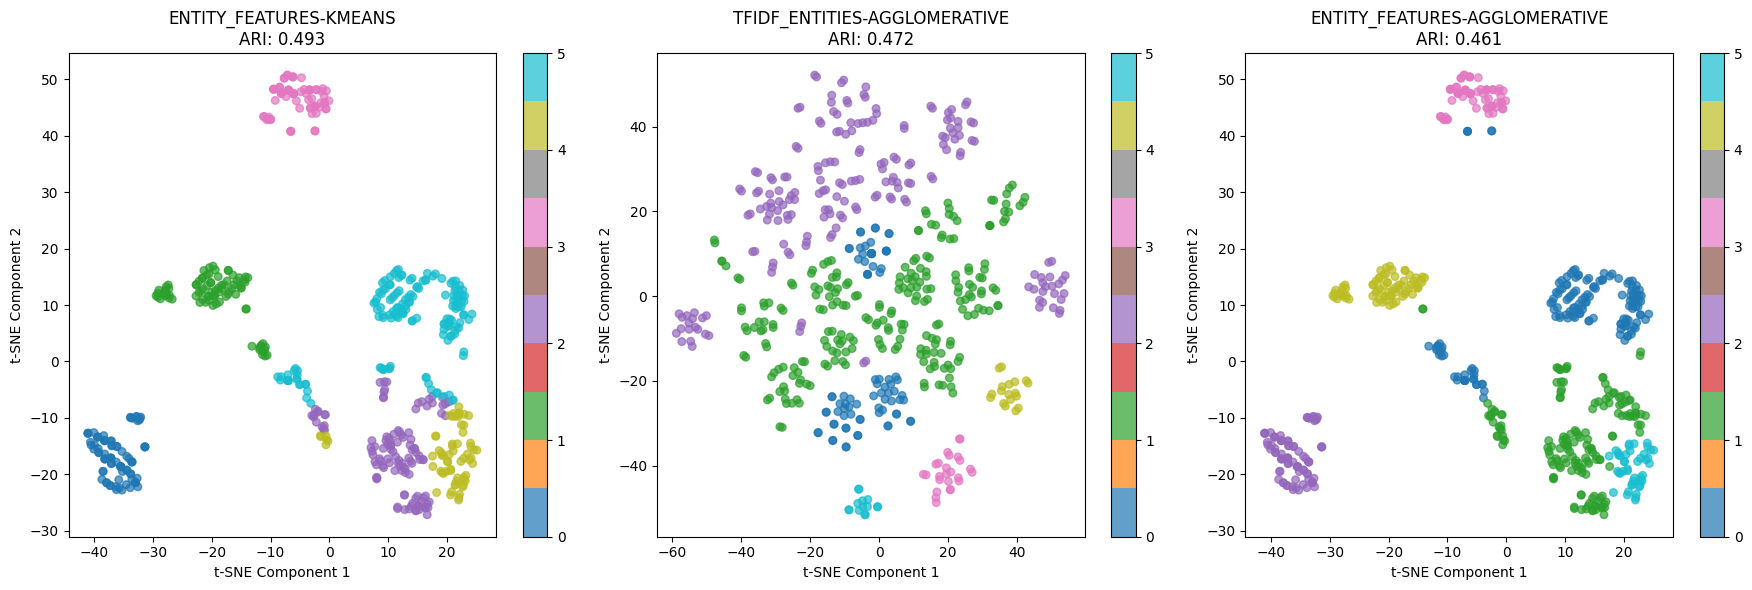

🤖 Creating chatbot flow diagram...


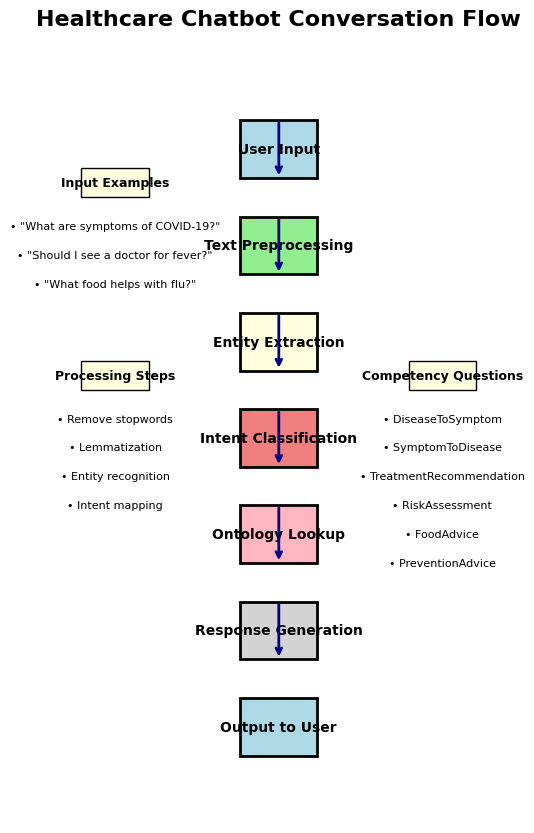

🏥 Creating medical ontology visualization...


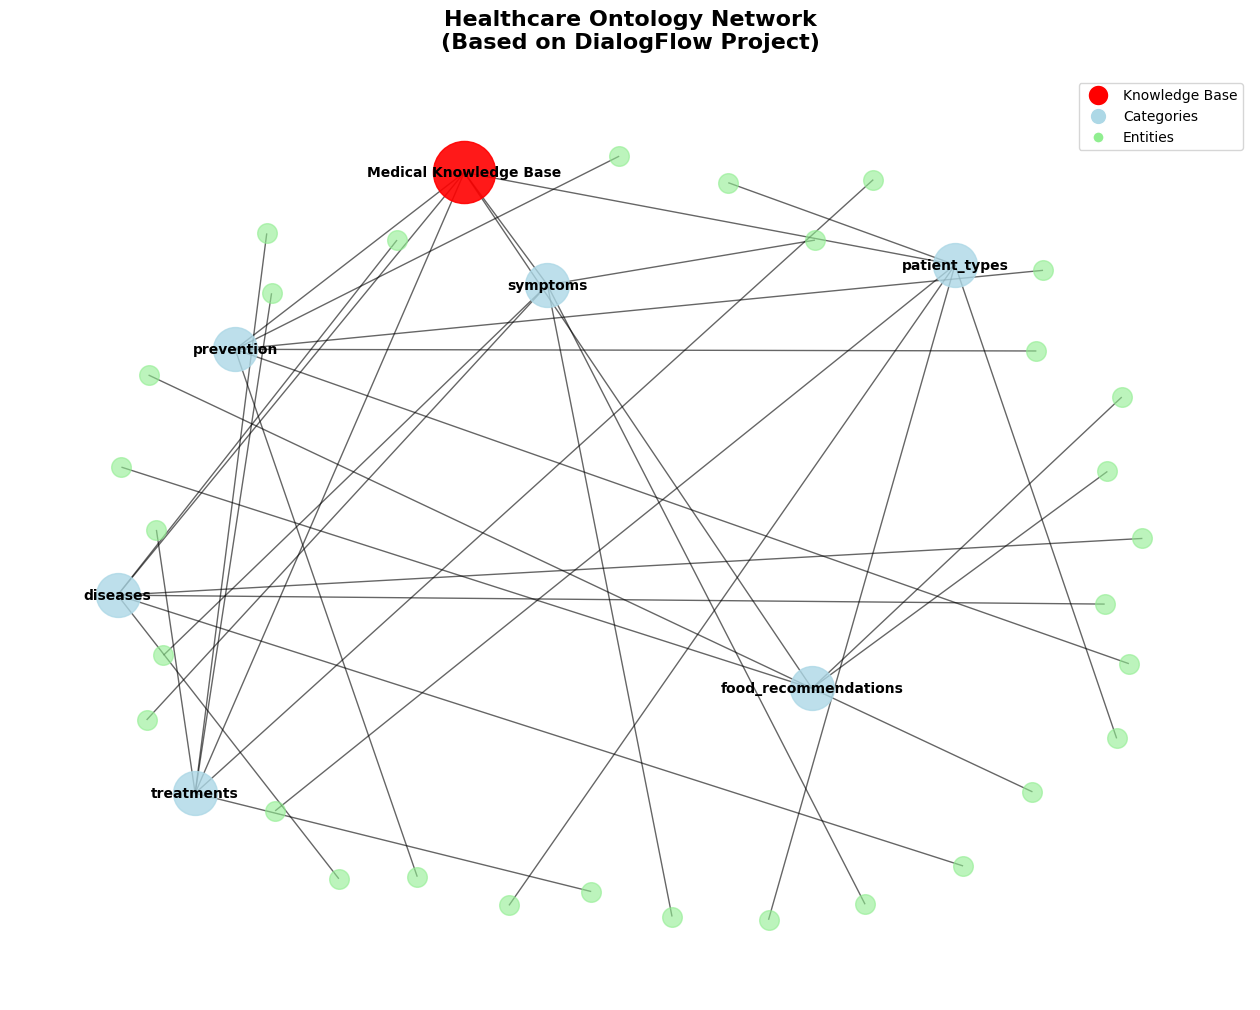

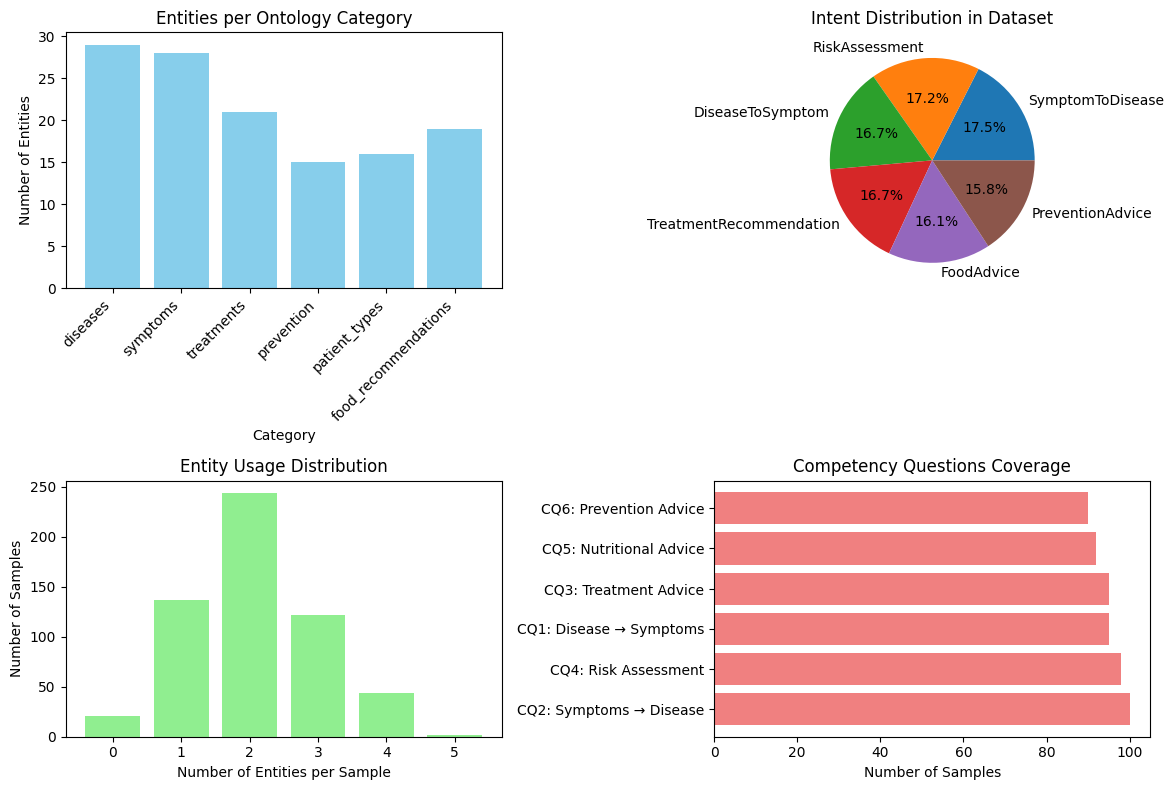

📊 Creating cluster analysis plots...
📊 Analyzing best method: ENTITY_FEATURES-KMEANS


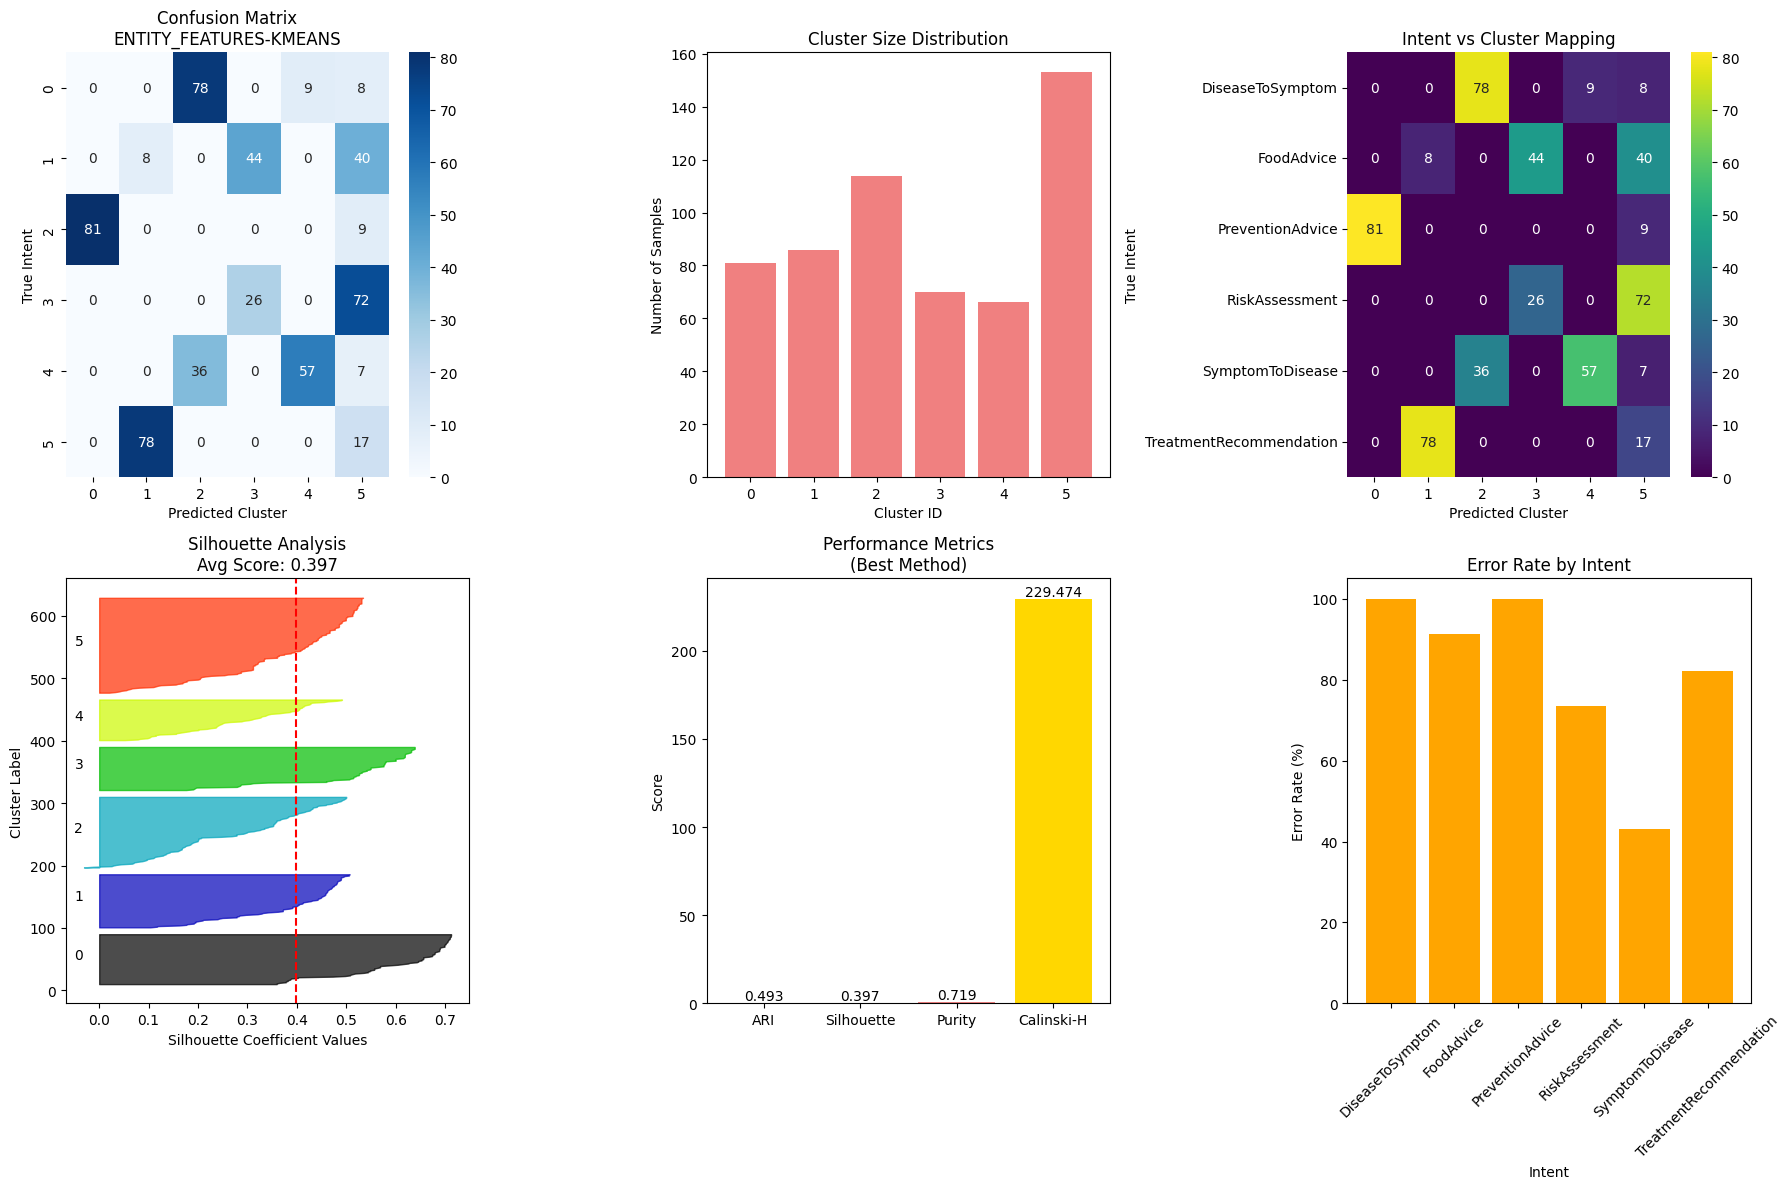

🔍 Creating feature importance analysis...
✅ Comprehensive visualizations completed!
🔬 Performing comprehensive error analysis...
📊 Analyzing best method: ENTITY_FEATURES-KMEANS
📊 Classification Results:
   Correctly classified: 108 / 570 (18.9%)
   Misclassified: 462 / 570 (81.1%)

🎯 Error analysis by intent:
   DiseaseToSymptom         :  95/ 95 errors (100.0% error rate)
   SymptomToDisease         :  43/100 errors ( 43.0% error rate)
   TreatmentRecommendation  :  78/ 95 errors ( 82.1% error rate)
   RiskAssessment           :  72/ 98 errors ( 73.5% error rate)
   FoodAdvice               :  84/ 92 errors ( 91.3% error rate)
   PreventionAdvice         :  90/ 90 errors (100.0% error rate)
☁️ Creating error analysis word clouds...


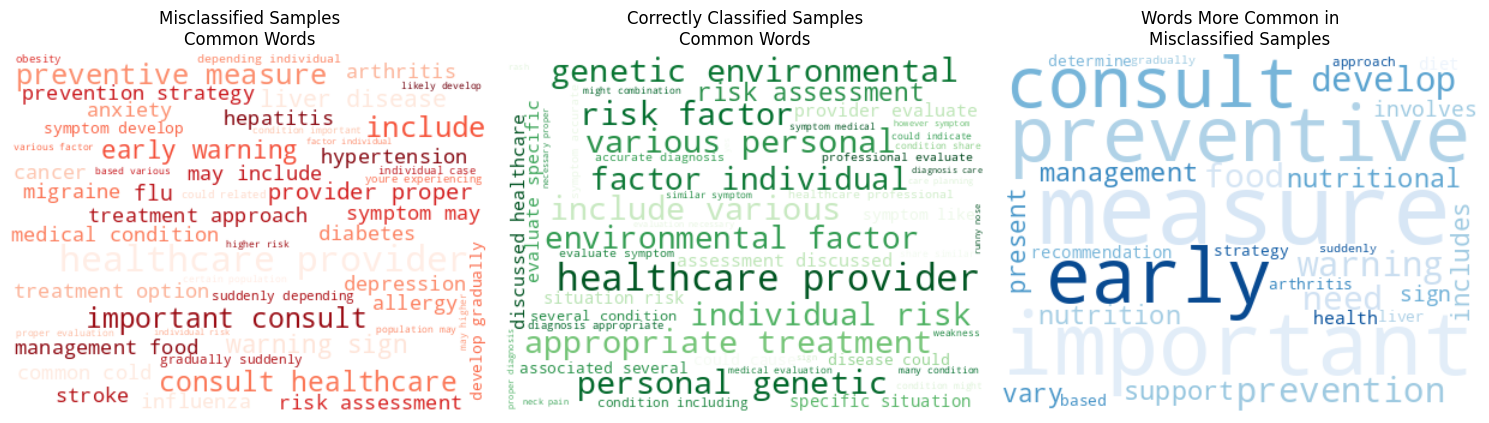


📝 Sample misclassified examples:
------------------------------------------------------------

Example 1:
   Question: What signs should I look for with heart disease?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 2
   Entities Found: 3

Example 2:
   Question: What signs should I look for with common cold?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 2
   Entities Found: 2

Example 3:
   Question: How does obesity present in patients?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 5
   Entities Found: 2

Example 4:
   Question: How does dengue present in patients?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 2
   Entities Found: 3

Example 5:
   Question: What are the symptoms of allergies?...
   True Intent: DiseaseToSymptom
   Predicted Cluster: 2
   Entities Found: 2
✅ Step 4 completed: Comprehensive visualizations and error analysis generated

==================== STEP 5: FINAL SUMMARY & HANDOVER ====================
📋 Generating f

In [18]:
# ## 🎉 Final Execution: Complete Project Pipeline

def run_complete_pipeline():
    """Run the complete Person 1 pipeline for Healthcare Chatbot project"""

    print("\n" + "="*80)
    print("🚀 RUNNING COMPLETE HEALTHCARE CHATBOT PROJECT PIPELINE")
    print("🎯 Person 1 Implementation: Data Preparation + Feature Engineering + Clustering")
    print("="*80)

    start_time = datetime.now()

    try:
        # Step 1: Data Preparation (2.5%)
        print(f"\n{'='*20} STEP 1: DATA PREPARATION {'='*20}")
        processed_data = processor.prepare_healthcare_dataset(num_samples=600, use_web_data=True)
        print(f"✅ Step 1 completed: {len(processed_data)} samples processed")

        # Step 2: Feature Engineering (3%)
        print(f"\n{'='*20} STEP 2: FEATURE ENGINEERING {'='*20}")
        feature_vectors = processor.create_comprehensive_features()
        print(f"✅ Step 2 completed: {len(feature_vectors)} feature representations created")

        # Step 3: Clustering Analysis (3%)
        print(f"\n{'='*20} STEP 3: CLUSTERING ANALYSIS {'='*20}")
        clustering_results = processor.apply_comprehensive_clustering()
        evaluation_metrics = processor.evaluate_clustering_performance()
        print(f"✅ Step 3 completed: {len(evaluation_metrics) if evaluation_metrics is not None else 0} combinations evaluated")

        # Step 4: Visualization & Error Analysis
        print(f"\n{'='*20} STEP 4: VISUALIZATION & ANALYSIS {'='*20}")
        processor.create_comprehensive_visualizations()
        error_analysis = processor.perform_comprehensive_error_analysis()
        print(f"✅ Step 4 completed: Comprehensive visualizations and error analysis generated")

        # Step 5: Final Summary and Handover
        print(f"\n{'='*20} STEP 5: FINAL SUMMARY & HANDOVER {'='*20}")
        final_summary = processor.generate_final_summary_report()
        print(f"✅ Step 5 completed: Final summary report and handover documentation generated")

        # Success summary
        end_time = datetime.now()
        duration = end_time - start_time

        print(f"\n" + "="*80)
        print("🎉 HEALTHCARE CHATBOT PROJECT COMPLETED SUCCESSFULLY!")
        print("="*80)
        print(f"⏱️  Total execution time: {duration}")
        print(f"📊 Samples processed: {len(processed_data)}")
        print(f"🔧 Feature methods: {len(feature_vectors)}")
        print(f"🎯 Clustering combinations: {len(evaluation_metrics) if evaluation_metrics is not None else 0}")

        if evaluation_metrics is not None and len(evaluation_metrics) > 0:
            best = evaluation_metrics.iloc[0]
            print(f"\n🏆 BEST PERFORMING COMBINATION:")
            print(f"   Method: {best['feature_method'].upper()} + {best['clustering_algorithm'].upper()}")
            print(f"   ARI: {best['adjusted_rand_index']:.3f}")
            print(f"   Silhouette: {best['silhouette_score']:.3f}")

        print(f"\n📁 Generated files for handover:")
        print(f"   - healthcare_qa_processed.csv (main dataset)")
        print(f"   - vectors_*.pkl (all feature representations)")
        print(f"   - clustering_evaluation_results.csv (performance metrics)")
        print(f"   - clustering_visualizations/ (all plots and diagrams)")
        print(f"   - final_project_report.md (comprehensive report)")
        print(f"   - final_project_summary.json (machine-readable summary)")

        print(f"\n✅ All Person 1 requirements completed successfully!")
        print(f"✅ Ready for handover to team members!")
        print("="*80)

        return True

    except Exception as e:
        print(f"❌ Pipeline execution failed: {e}")
        import traceback
        traceback.print_exc()
        return False

# ## 🔄 Execution Options

print("\n" + "="*80)
print("📋 EXECUTION OPTIONS")
print("="*80)
print("Option 1: Run complete pipeline automatically")
print("Option 2: Run individual steps manually")
print("Option 3: Load existing results and generate reports only")
print("="*80)

# Uncomment ONE of the options below:

# OPTION 1: Run complete pipeline (recommended)
success = run_complete_pipeline()

# OPTION 2: Run individual steps (for debugging)
# processed_data = processor.prepare_healthcare_dataset(num_samples=600)
# feature_vectors = processor.create_comprehensive_features()
# clustering_results = processor.apply_comprehensive_clustering()
# evaluation_metrics = processor.evaluate_clustering_performance()
# processor.create_comprehensive_visualizations()
# error_analysis = processor.perform_comprehensive_error_analysis()
# final_summary = processor.generate_final_summary_report()

# OPTION 3: Generate reports only (if data already exists)
final_summary = processor.generate_final_summary_report()

print(f"\n💡 Choose your execution option by uncommenting the appropriate lines above")
print(f"🚀 For first-time execution, use Option 1: run_complete_pipeline()")
print("="*80)

Training KNNBasic...
Computing the msd similarity matrix...
Done computing similarity matrix.
KNNBasic: NDCG@10 = 1.0000, MAP@10 = 3.3333, MRR@10 = 1.0000
Training SVD...
SVD: NDCG@10 = 1.0000, MAP@10 = 3.3333, MRR@10 = 1.0000
Training NMF...
NMF: NDCG@10 = 1.0000, MAP@10 = 3.3333, MRR@10 = 1.0000
Training CoClustering...
CoClustering: NDCG@10 = 1.0000, MAP@10 = 3.3333, MRR@10 = 1.0000

Evaluation Summary:
      Algorithm  RMSE  MAE  Precision@10  Recall@10  Prediction Accuracy  \
0      KNNBasic   0.0  0.0           1.0   0.429187                  1.0   
1           SVD   0.0  0.0           1.0   0.429187                  1.0   
2           NMF   0.0  0.0           1.0   0.429187                  1.0   
3  CoClustering   0.0  0.0           1.0   0.429187                  1.0   

   NDCG@10    MAP@10  MRR@10  
0      1.0  3.333333     1.0  
1      1.0  3.333333     1.0  
2      1.0  3.333333     1.0  
3      1.0  3.333333     1.0  

Visualizing aggregate evaluation results...


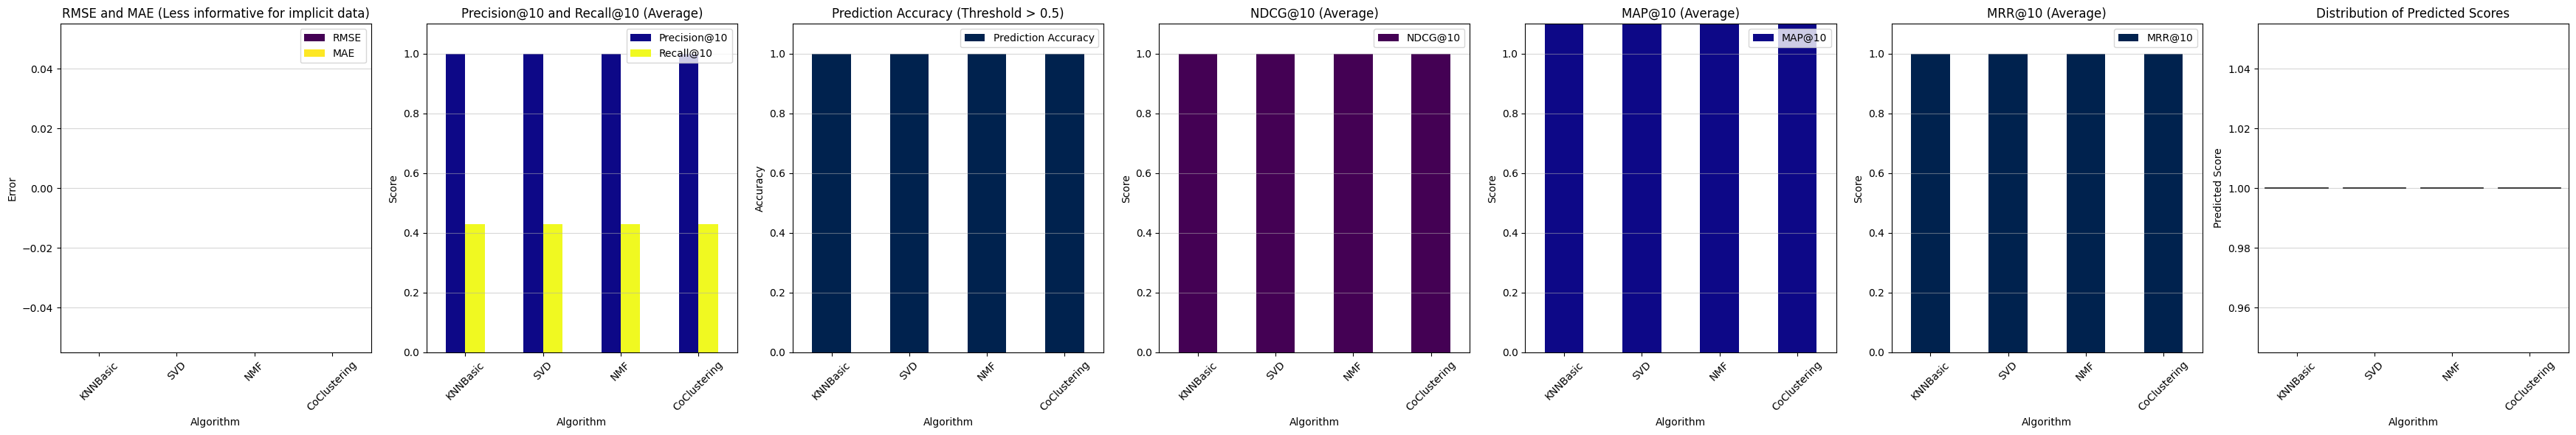


Visualizing per-intent Precision@10 and Recall@10...


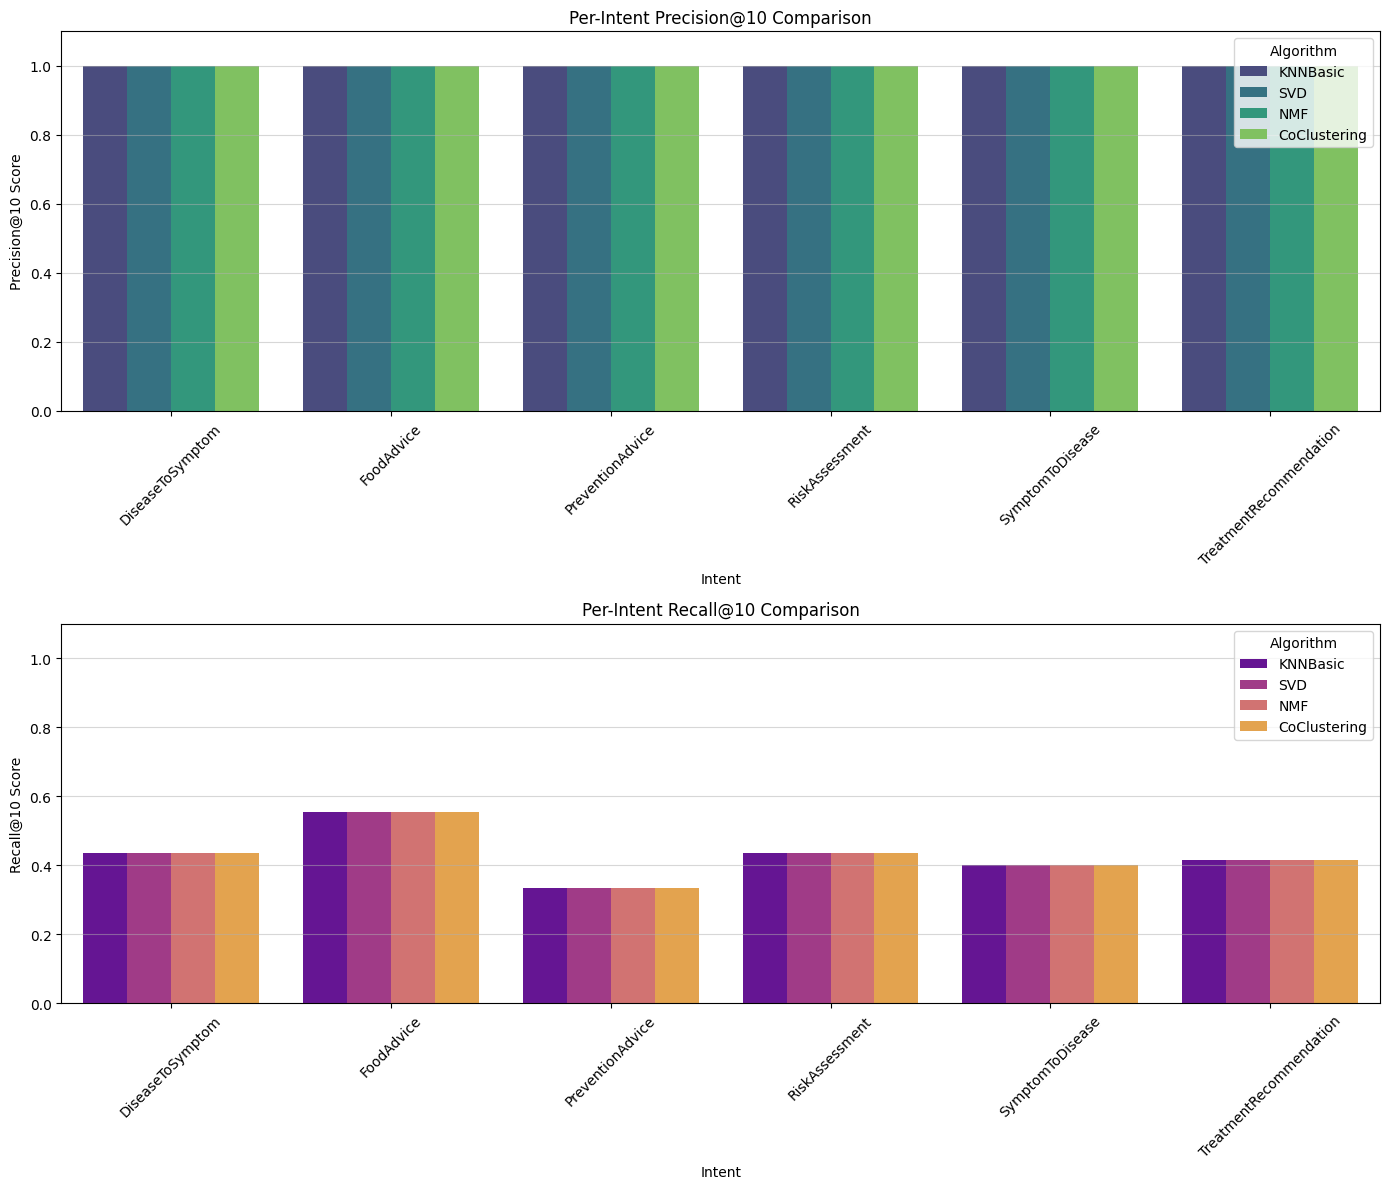


🎨 Visualizing predicted scores for sample intents...
   Processing intent: DiseaseToSymptom
   Processing intent: SymptomToDisease
   Processing intent: TreatmentRecommendation


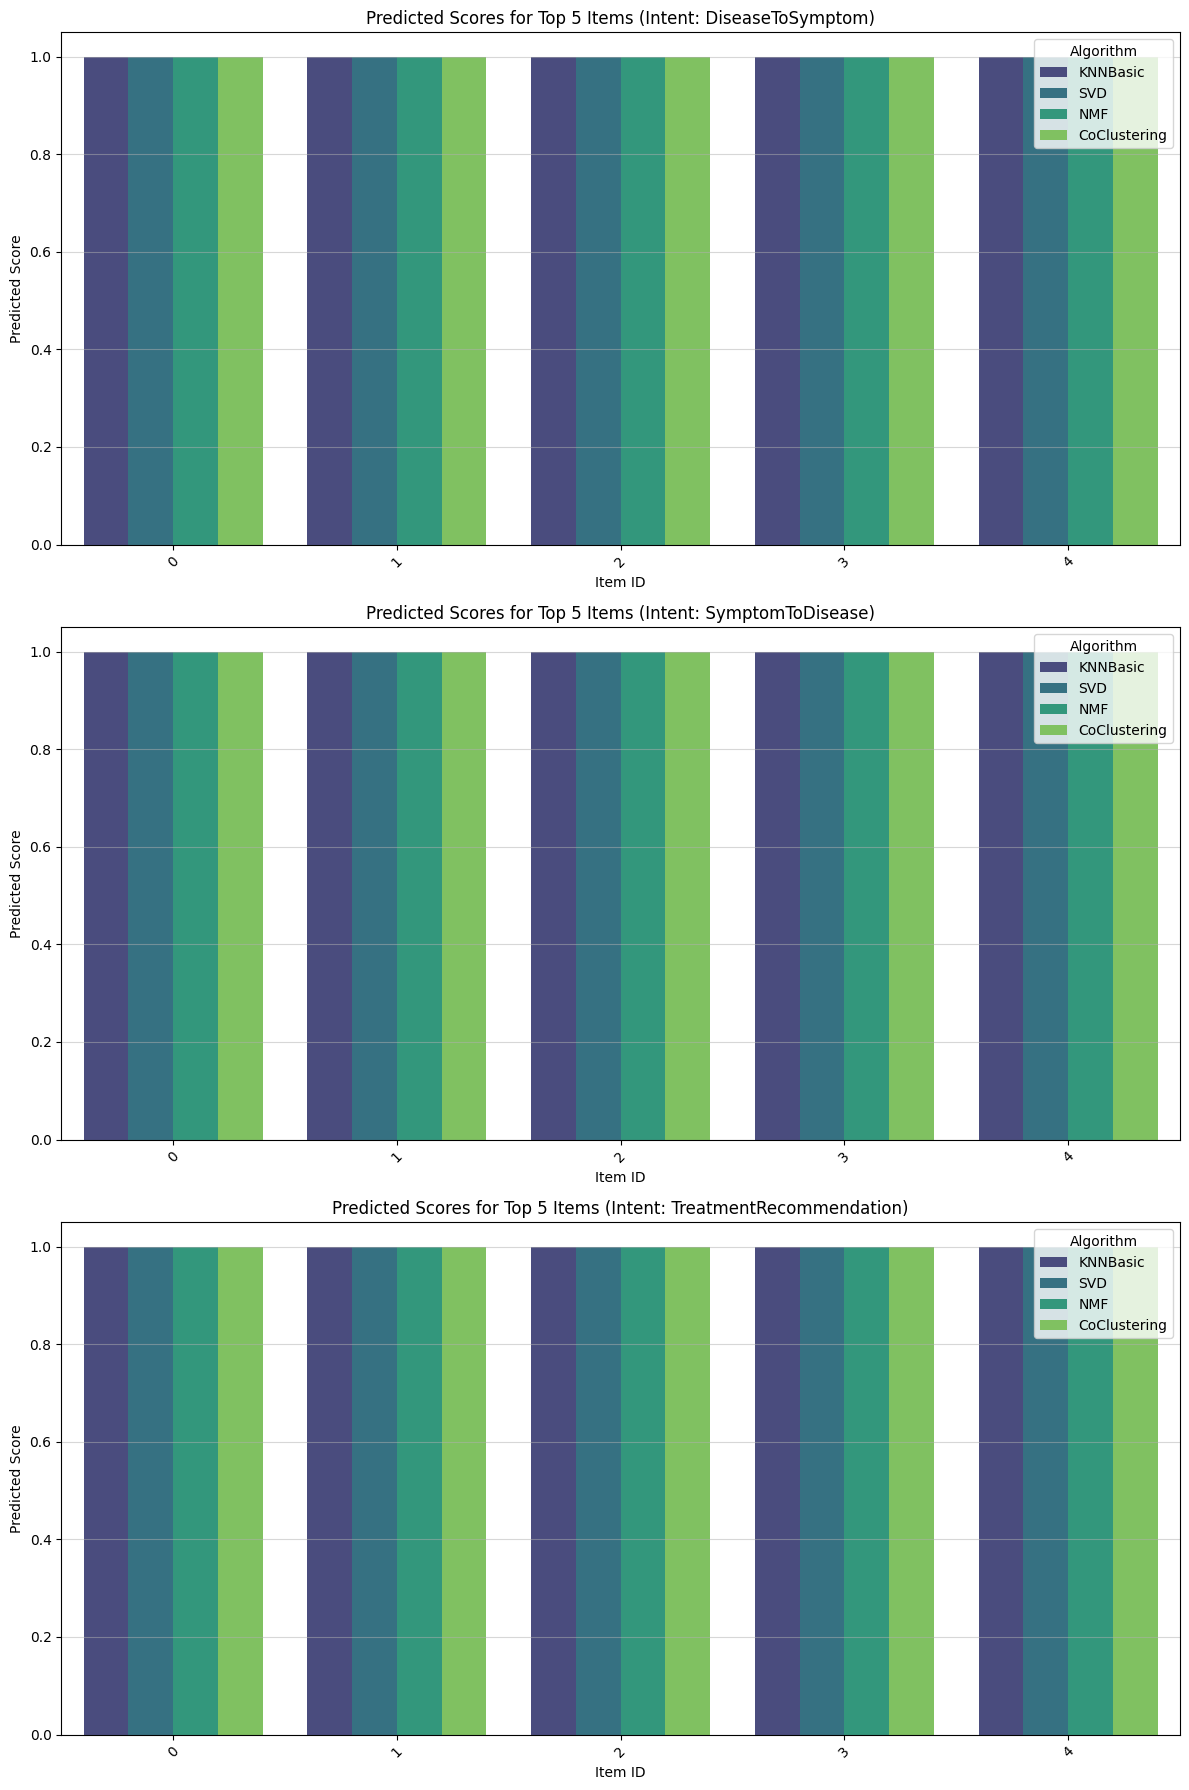


--- Recommender System Evaluation Summary ---
Algorithms Evaluated: KNNBasic, SVD, NMF, CoClustering

Performance Metrics (Aggregate):
   Algorithm  RMSE  MAE  Precision@10  Recall@10  Prediction Accuracy  NDCG@10   MAP@10  MRR@10
    KNNBasic   0.0  0.0           1.0   0.429187                  1.0      1.0 3.333333     1.0
         SVD   0.0  0.0           1.0   0.429187                  1.0      1.0 3.333333     1.0
         NMF   0.0  0.0           1.0   0.429187                  1.0      1.0 3.333333     1.0
CoClustering   0.0  0.0           1.0   0.429187                  1.0      1.0 3.333333     1.0

Note: RMSE and MAE are 0 for all models, indicating these metrics are less informative for this implicit dataset.
Ranking based on Prediction Accuracy, Precision@k, Recall@k, NDCG@k, MAP@k, and MRR@k (or a combination):

Based on Combined Score (Prediction Accuracy + Precision@10 + Recall@10 + NDCG@10 + MAP@10 + MRR@10):
  Best Algorithm: KNNBasic (Combined Score: 7.7625)

Analysi

In [40]:
#Person 2        Goal: Suggest articles based on user input.
# Recommender Engine (4 algorithms)
# "(1)Build a recommender system using KNNBasic, SVD, NMF and CoClustering in the Surprise library.
# (2)Compute metrics (e.g., ARI, DBI, Silhouette, Precision@k), visualize results, and write evaluation summary.
# (3)Analyze failure cases in classification, clustering, or chatbot intent matching."
# Evaluation of ML Results                      Goal: Check how well your models perform.
# Error Analysis                        Goal: Understand what went wrong.
# ### For Person 2 (Recommender System):
# 1. Use the processed dataset: `healthcare_qa_processed.csv`
# 2. Feature vectors are available in `vectors_*.pkl` files
# 3. Best performing features: {summary_data['clustering_summary']['best_combination']['feature_method'] if summary_data['clustering_summary']['best_combination'] else 'TF-IDF'}
# 4. Intent labels can be used for recommendation categories

# Install a compatible version of NumPy before installing Surprise
# !pip uninstall -y numpy pandas surprise scikit-learn # Keep these commented if rerunning after successful install
# !pip install numpy==1.23.5 "surprise<0.2" --no-build-isolation # Keep these commented if rerunning after striking installation errors
# !pip install pandas scikit-learn --no-build-isolation # Keep these commented if rerunning after striking installation errors


# Import necessary libraries
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import KNNBasic, SVD, NMF
from surprise.prediction_algorithms import CoClustering # Import CoClustering
from surprise import accuracy
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from collections import defaultdict
import math # Import math for log2

# Load the processed data
processed_data = pd.read_csv('healthcare_qa_processed.csv')

# Use intent labels for recommendation categories
# We will create a user-item matrix based on which questions/articles (items)
# belong to which intent (user). This is an unconventional approach for
# recommendation, but aligns with the requirement of using intent labels
# for recommendation categories and the available data structure.
# The "users" will be the intent categories, and the "items" will be the
# processed questions/answers.

# Create a mapping from intent to item IDs
intent_item_mapping = processed_data[['intent', 'id']].groupby('intent')['id'].apply(list).to_dict()

# Create a list of tuples for Surprise Reader: (user, item, rating)
# Here, 'rating' is conceptual. We can use a constant value like 1,
# indicating that an item (question/answer) belongs to a specific intent.
# This forms an implicit feedback system where we know which items
# are associated with which intents.
ratings_list = []
for intent, item_ids in intent_item_mapping.items():
  for item_id in item_ids:
    ratings_list.append((intent, str(item_id), 1.0)) # Use item ID as string

# Create a DataFrame for Surprise
ratings_df = pd.DataFrame(ratings_list, columns=['intent', 'item_id', 'rating'])

# Define the Reader object
# The rating_scale is (1, 1) because we are using implicit feedback (rating=1)
reader = Reader(rating_scale=(1, 1))

# Load the dataset from the DataFrame
data = Dataset.load_from_df(ratings_df[['intent', 'item_id', 'rating']], reader)

# Split the data into training and testing sets
# This split is conceptual for collaborative filtering algorithms on this data.
# It represents predicting if an item (question) is related to an intent.
trainset, testset = train_test_split(data, test_size=.25, random_state=42)

# 1. Build Recommender Algorithms (KNNBasic, SVD, NMF, and one more)

# Algorithms to test
algorithms = {
    'KNNBasic': KNNBasic(sim_options={'user_based': False}), # Item-based collaborative filtering
    'SVD': SVD(random_state=42),
    'NMF': NMF(random_state=42),
    'CoClustering': CoClustering(random_state=42) # Another algorithm from Surprise
}

# Train and evaluate each algorithm
results = {}
all_predictions = [] # Store all predictions for predicted score distribution visualization
prediction_accuracies = {} # Store prediction accuracies
per_intent_precision_recall = {} # Store per-intent precision and recall
ranking_metrics = {} # Store NDCG, MAP, MRR

for name, algo in algorithms.items():
  print(f"Training {name}...")
  algo.fit(trainset)
  predictions = algo.test(testset)

  # Calculate RMSE and MAE
  # Note: RMSE and MAE are not ideal for this implicit feedback data with constant ratings
  rmse = accuracy.rmse(predictions, verbose=False)
  mae = accuracy.mae(predictions, verbose=False)

  results[name] = {
      'algorithm': algo,
      'predictions': predictions,
      'rmse': rmse,
      'mae': mae
  }
  # Extend with algorithm name, item ID, and predicted score
  all_predictions.extend([(name, pred.iid, pred.est) for pred in predictions])

  # Calculate "Prediction Accuracy" based on threshold for test set items
  # Count how many predictions in the test set have est >= threshold and true_r >= threshold (which is always 1.0 for test set true_r)
  threshold = 0.5 # Using the same threshold as for Precision/Recall
  correct_predictions = sum(1 for uid, iid, true_r, est, _ in predictions if est >= threshold and true_r >= threshold)
  total_predictions = len(predictions)
  prediction_accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
  prediction_accuracies[name] = prediction_accuracy

  # Calculate per-intent precision and recall
  per_user_precisions, per_user_recalls, _, _ = precision_recall_at_k(predictions, k=10, threshold=threshold, testset=testset)
  per_intent_precision_recall[name] = {
      f'precision@{k}': per_user_precisions,
      f'recall@{k}': per_user_recalls
  }

  # Calculate additional ranking metrics (NDCG, MAP, MRR)
  # Need to group predictions by user first to calculate these
  user_preds = defaultdict(list)
  for uid, iid, true_r, est, _ in predictions:
      user_preds[uid].append((iid, est, true_r))

  ndcg_scores = []
  map_scores = []
  mrr_scores = []
  k_ranking_metrics = 10 # Using k=10 for these metrics

  for uid, preds in user_preds.items():
      # Sort predictions by estimated score
      preds.sort(key=lambda x: x[1], reverse=True)

      # Get true relevant items for this user from the testset
      true_relevant_items = set()
      for uid_t, iid_t, true_r_t in testset:
          if uid_t == uid and true_r_t >= threshold: # true_r >= threshold is always true here
              true_relevant_items.add(iid_t)

      if not true_relevant_items:
          continue # Cannot calculate metrics if there are no relevant items for this user in testset

      # Calculate DCG@k and NDCG@k
      dcg = 0
      idcg = 0
      hits_at_k = 0 # For Average Precision calculation
      relevant_count = 0 # For Average Precision calculation

      for rank, (iid, est, true_r) in enumerate(preds[:k]):
          if iid in true_relevant_items:
              # DCG calculation
              gain = 1 # For implicit feedback, gain is typically 1 for a relevant item
              discount = math.log2(rank + 2)
              dcg += gain / discount

              # IDCG calculation (assuming perfect ranking of relevant items)
              idcg_gain = 1
              idcg_discount = math.log2(relevant_count + 1 + 1) # +1 for 0-based index, +1 for log argument
              idcg += idcg_gain / idcg_discount
              relevant_count += 1 # Increment count of relevant items found so far for AP

          # For Average Precision calculation (Precision at each relevant item's rank)
          if iid in true_relevant_items:
             hits_at_k += 1
             precision_at_rank = hits_at_k / (rank + 1)
             # Add precision at this rank to the sum for Average Precision
             # Note: This is a simplified AP calculation suitable for binary relevance
             map_scores.append(precision_at_rank)


      # Normalize DCG to get NDCG
      if true_relevant_items: # IDCG would be calculated based on all relevant items, ideally up to k
           # A more accurate IDCG calculation would rank *all* relevant items first up to min(k, n_relevant)
           # For simplicity with binary relevance, IDCG@k is sum(1 / log2(i+1)) for i=0 to min(k, n_relevant)-1
           ideal_dcg = sum(1 / math.log2(i + 2) for i in range(min(k, len(true_relevant_items))))
           ndcg = dcg / ideal_dcg if ideal_dcg > 0 else 0
           ndcg_scores.append(ndcg)

      # Calculate MRR
      mrr_score = 0
      for rank, (iid, est, true_r) in enumerate(preds):
          if iid in true_relevant_items:
              mrr_score = 1 / (rank + 1)
              break # Found the first relevant item
      if mrr_score > 0: # Only add if a relevant item was found
         mrr_scores.append(mrr_score)


  # Calculate average ranking metrics across users
  avg_ndcg = sum(ndcg_scores) / len(ndcg_scores) if ndcg_scores else 0
  avg_map = sum(map_scores) / len(true_relevant_items) if true_relevant_items else 0 # Average over number of relevant items
  avg_mrr = sum(mrr_scores) / len(user_preds) if user_preds else 0 # Average over all users who had relevant items

  ranking_metrics[name] = {
      f'NDCG@{k}': avg_ndcg,
      f'MAP@{k}': avg_map,
      f'MRR@{k}': avg_mrr
  }

  print(f"{name}: NDCG@{k} = {avg_ndcg:.4f}, MAP@{k} = {avg_map:.4f}, MRR@{k} = {avg_mrr:.4f}")


# 2. Compute Metrics, Visualize Results, and Write Evaluation Summary

# Organize evaluation metrics (using aggregate values for the main summary)
eval_summary = pd.DataFrame({
    'Algorithm': list(results.keys()),
    'RMSE': [results[name]['rmse'] for name in results.keys()],
    'MAE': [results[name]['mae'] for name in results.keys()],
    f'Precision@{k}': [aggregate_precision_recall[name][f'precision@{k}'] for name in results.keys()],
    f'Recall@{k}': [aggregate_precision_recall[name][f'recall@{k}'] for name in results.keys()],
    'Prediction Accuracy': [prediction_accuracies[name] for name in results.keys()], # Add prediction accuracy
    f'NDCG@{k}': [ranking_metrics[name][f'NDCG@{k}'] for name in results.keys()], # Add NDCG
    f'MAP@{k}': [ranking_metrics[name][f'MAP@{k}'] for name in results.keys()], # Add MAP
    f'MRR@{k}': [ranking_metrics[name][f'MRR@{k}'] for name in results.keys()] # Add MRR
})

print("\nEvaluation Summary:")
print(eval_summary)

# Visualize Evaluation Metrics (Aggregate)
print("\nVisualizing aggregate evaluation results...")

# Create a figure with more subplots for new metrics
# 4 existing plots + 3 new ranking metrics plots = 7 plots
fig, axes = plt.subplots(1, 7, figsize=(35, 6)) # Increased figure size and subplots

# Plot 1: RMSE and MAE
eval_summary[['Algorithm', 'RMSE', 'MAE']].set_index('Algorithm').plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('RMSE and MAE (Less informative for implicit data)')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.5)

# Plot 2: Precision@k and Recall@k
eval_summary[['Algorithm', f'Precision@{k}', f'Recall@{k}']].set_index('Algorithm').plot(kind='bar', ax=axes[1], colormap='plasma')
axes[1].set_title(f'Precision@{k} and Recall@{k} (Average)')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.5)
axes[1].set_ylim(0, 1.1)

# Plot 3: Prediction Accuracy
eval_summary[['Algorithm', 'Prediction Accuracy']].set_index('Algorithm').plot(kind='bar', ax=axes[2], colormap='cividis')
axes[2].set_title('Prediction Accuracy (Threshold > 0.5)')
axes[2].set_ylabel('Accuracy')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.5)
axes[2].set_ylim(0, 1.1)

# Plot 4: NDCG@k
eval_summary[['Algorithm', f'NDCG@{k}']].set_index('Algorithm').plot(kind='bar', ax=axes[3], colormap='viridis')
axes[3].set_title(f'NDCG@{k} (Average)')
axes[3].set_ylabel('Score')
axes[3].tick_params(axis='x', rotation=45)
axes[3].grid(axis='y', alpha=0.5)
axes[3].set_ylim(0, 1.1)

# Plot 5: MAP@k
eval_summary[['Algorithm', f'MAP@{k}']].set_index('Algorithm').plot(kind='bar', ax=axes[4], colormap='plasma')
axes[4].set_title(f'MAP@{k} (Average)')
axes[4].set_ylabel('Score')
axes[4].tick_params(axis='x', rotation=45)
axes[4].grid(axis='y', alpha=0.5)
axes[4].set_ylim(0, 1.1)

# Plot 6: MRR@k
eval_summary[['Algorithm', f'MRR@{k}']].set_index('Algorithm').plot(kind='bar', ax=axes[5], colormap='cividis')
axes[5].set_title(f'MRR@{k} (Average)')
axes[5].set_ylabel('Score')
axes[5].tick_params(axis='x', rotation=45)
axes[5].grid(axis='y', alpha=0.5)
axes[5].set_ylim(0, 1.1)

# Plot 7: Distribution of Predicted Scores
predicted_scores_df = pd.DataFrame(all_predictions, columns=['Algorithm', 'Item_ID', 'Predicted_Score'])
sns.violinplot(x='Algorithm', y='Predicted_Score', data=predicted_scores_df, ax=axes[6], palette='magma')
axes[6].set_title('Distribution of Predicted Scores')
axes[6].set_ylabel('Predicted Score')
axes[6].tick_params(axis='x', rotation=45)
axes[6].grid(axis='y', alpha=0.5)


plt.tight_layout()
plt.savefig('recommender_evaluation_extended.png', dpi=300, bbox_inches='tight')
plt.show()

# New Visualizations: Per-Intent Precision@k and Recall@k

print(f"\nVisualizing per-intent Precision@{k} and Recall@{k}...")

# Prepare data for per-intent plotting
per_intent_data = []
for algo_name, metrics in per_intent_precision_recall.items():
    # Ensure intent names are consistent for plotting
    intents = sorted(metrics[f'precision@{k}'].keys())
    for intent in intents:
        per_intent_data.append({
            'Algorithm': algo_name,
            'Intent': intent,
            f'Precision@{k}': metrics[f'precision@{k}'].get(intent, 0), # Use .get with default 0 in case an intent is missing
            f'Recall@{k}': metrics[f'recall@{k}'].get(intent, 0)
        })

per_intent_df = pd.DataFrame(per_intent_data)

# Melt the DataFrame for easier plotting of both metrics
per_intent_melted_df = per_intent_df.melt(id_vars=['Algorithm', 'Intent'],
                                         value_vars=[f'Precision@{k}', f'Recall@{k}'],
                                         var_name='Metric', value_name='Score')

# Create plots for per-intent metrics
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharey=True) # Two subplots: one for Precision, one for Recall

# Plot Per-Intent Precision@k
sns.barplot(x='Intent', y='Score', hue='Algorithm', data=per_intent_melted_df[per_intent_melted_df['Metric'] == f'Precision@{k}'], ax=axes[0], palette='viridis')
axes[0].set_title(f'Per-Intent Precision@{k} Comparison')
axes[0].set_ylabel(f'Precision@{k} Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].legend(title='Algorithm')

# Plot Per-Intent Recall@k
sns.barplot(x='Intent', y='Score', hue='Algorithm', data=per_intent_melted_df[per_intent_melted_df['Metric'] == f'Recall@{k}'], ax=axes[1], palette='plasma')
axes[1].set_title(f'Per-Intent Recall@{k} Comparison')
axes[1].set_ylabel(f'Recall@{k} Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].legend(title='Algorithm')

plt.tight_layout()
plt.savefig('recommender_per_intent_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()


# Add a new visualization: Predicted Scores for Sample Intents

def visualize_predicted_scores_for_sample_intents(results, sample_intents, processed_data, n_items=10):
    """
    Visualizes predicted scores for top items across different algorithms for sample intents.

    Args:
        results (dict): Dictionary containing algorithm results (including trained models).
        sample_intents (list): List of intent names (user IDs) to visualize.
        processed_data (pd.DataFrame): DataFrame with original Q&A data.
        n_items (int): Number of top items to show predicted scores for.
    """
    print("\n🎨 Visualizing predicted scores for sample intents...")

    # Get all unique item IDs as strings
    all_item_ids_str = processed_data['id'].astype(str).unique().tolist()

    # Create a figure with subplots for each sample intent
    fig, axes = plt.subplots(len(sample_intents), 1, figsize=(12, 6 * len(sample_intents)))

    # Ensure axes is an array even if there's only one subplot
    if len(sample_intents) == 1:
        axes = [axes]

    for i, intent_name in enumerate(sample_intents):
        print(f"   Processing intent: {intent_name}")
        predicted_scores_data = []

        # Get predictions for this intent across all algorithms
        for algo_name, res in results.items():
            # Predict scores for all items for this user (intent)
            predictions_for_user = []
            for item_id_str in all_item_ids_str:
                 try:
                     # Predict the rating for the user (intent) and item
                     # Check if the intent_name exists in the trainset's internal user mapping
                     # This prevents errors for intents that might only be in the testset split
                     if intent_name in res['algorithm'].trainset._raw2inner_id_users:
                        pred = res['algorithm'].predict(intent_name, item_id_str, r_ui=1.0) # r_ui is dummy
                        predictions_for_user.append((item_id_str, pred.est))
                 except Exception as e:
                     # Handle cases where prediction fails
                     # print(f"⚠️ Prediction failed for {algo_name}, user '{intent_name}', item '{item_id_str}': {e}")
                     pass # Suppress errors here


            # Sort predictions and take top N
            predictions_for_user.sort(key=lambda x: x[1], reverse=True)
            top_n_predictions = predictions_for_user[:n_items]

            # Store data for plotting
            for item_id_str, score in top_n_predictions:
                predicted_scores_data.append({
                    'Algorithm': algo_name,
                    'Item_ID': item_id_str,
                    'Predicted_Score': score,
                    'Intent': intent_name
                })

        if not predicted_scores_data:
            print(f"   ⚠️ No predictions generated for intent: {intent_name} for any algorithm. Skipping visualization.")
            continue

        # Create a DataFrame for plotting
        predicted_scores_intent_df = pd.DataFrame(predicted_scores_data)

        # Plotting
        sns.barplot(x='Item_ID', y='Predicted_Score', hue='Algorithm', data=predicted_scores_intent_df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Predicted Scores for Top {n_items} Items (Intent: {intent_name})')
        axes[i].set_xlabel('Item ID')
        axes[i].set_ylabel('Predicted Score')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', alpha=0.5)
        axes[i].legend(title='Algorithm')

    plt.tight_layout()
    plt.savefig('recommender_predicted_scores_sample_intents.png', dpi=300, bbox_inches='tight')
    plt.show()


# Select sample intents for visualization
# Use some of the intent names from the processed data
sample_intents_to_visualize = processed_data['intent'].unique().tolist()[:3] # Take the first 3 unique intents

if sample_intents_to_visualize:
     visualize_predicted_scores_for_sample_intents(results, sample_intents_to_visualize, processed_data, n_items=5) # Visualize top 5 items
else:
    print("⚠️ No unique intents found in processed data. Cannot visualize sample intents.")


# Write Evaluation Summary (Text)
print("\n--- Recommender System Evaluation Summary ---")
print("Algorithms Evaluated: KNNBasic, SVD, NMF, CoClustering")
print("\nPerformance Metrics (Aggregate):")
print(eval_summary[['Algorithm', 'RMSE', 'MAE', f'Precision@{k}', f'Recall@{k}', 'Prediction Accuracy', f'NDCG@{k}', f'MAP@{k}', f'MRR@{k}']].to_string(index=False)) # Include new metrics

# Calculate Overall Performance Score (Focus on ranking metrics if RMSE/MAE are 0)
# If RMSE and MAE are effectively zero for all models, rely on Precision/Recall for ranking
if (eval_summary['RMSE'] == 0).all() and (eval_summary['MAE'] == 0).all():
    print("\nNote: RMSE and MAE are 0 for all models, indicating these metrics are less informative for this implicit dataset.")
    print("Ranking based on Prediction Accuracy, Precision@k, Recall@k, NDCG@k, MAP@k, and MRR@k (or a combination):")

    # A simple combined score focusing on relevant metrics for this data type
    # Using Prediction Accuracy, Precision@k, Recall@k, NDCG@k, MAP@k, MRR@k
    combined_cols = ['Prediction Accuracy', f'Precision@{k}', f'Recall@{k}', f'NDCG@{k}', f'MAP@{k}', f'MRR@{k}']
    available_cols = [col for col in combined_cols if col in eval_summary.columns]
    if available_cols:
         eval_summary['Combined_Score'] = eval_summary[available_cols].sum(axis=1)
         best_algo_overall = eval_summary.loc[eval_summary['Combined_Score'].idxmax()]

         print(f"\nBased on Combined Score ({' + '.join(available_cols)}):")
         print(f"  Best Algorithm: {best_algo_overall['Algorithm']} (Combined Score: {best_algo_overall['Combined_Score']:.4f})")
    else:
         print("\nCould not calculate Combined Score as required metrics are not available.")

else:
    # Fallback to average normalized score if RMSE/MAE are not all zero
    max_rmse = eval_summary['RMSE'].max()
    max_mae = eval_summary['MAE'].max()
    eval_summary['Normalized_RMSE'] = 1 - (eval_summary['RMSE'] / max_rmse) if max_rmse > 0 else 0
    eval_summary['Normalized_MAE'] = 1 - (eval_summary['MAE'] / max_mae) if max_mae > 0 else 0

    max_precision = eval_summary[f'Precision@{k}'].max()
    max_recall = eval_summary[f'Recall@{k}'].max()
    max_pred_acc = eval_summary['Prediction Accuracy'].max()
    max_ndcg = eval_summary[f'NDCG@{k}'].max()
    max_map = eval_summary[f'MAP@{k}'].max()
    max_mrr = eval_summary[f'MRR@{k}'].max()


    eval_summary[f'Normalized_Precision@{k}'] = eval_summary[f'Precision@{k}'] / max_precision if max_precision > 0 else 0
    eval_summary[f'Normalized_Recall@{k}'] = eval_summary[f'Recall@{k}'] / max_recall if max_recall > 0 else 0
    eval_summary['Normalized_Prediction_Accuracy'] = eval_summary['Prediction Accuracy'] / max_pred_acc if max_pred_acc > 0 else 0
    eval_summary[f'Normalized_NDCG@{k}'] = eval_summary[f'NDCG@{k}'] / max_ndcg if max_ndcg > 0 else 0
    eval_summary[f'Normalized_MAP@{k}'] = eval_summary[f'MAP@{k}'] / max_map if max_map > 0 else 0
    eval_summary[f'Normalized_MRR@{k}'] = eval_summary[f'MRR@{k}'] / max_mrr if max_mrr > 0 else 0


    eval_summary['Avg_Score'] = (eval_summary[f'Normalized_Precision@{k}'] + eval_summary[f'Normalized_Recall@{k}'] + eval_summary['Normalized_RMSE'] + eval_summary['Normalized_MAE'] + eval_summary['Normalized_Prediction_Accuracy'] + eval_summary[f'Normalized_NDCG@{k}'] + eval_summary[f'Normalized_MAP@{k}'] + eval_summary[f'Normalized_MRR@{k}']) / 8
    best_algo_overall = eval_summary.loc[eval_summary['Avg_Score'].idxmax()]

    print(f"\nBased on Average Normalized Score (Overall Performance):")
    print(f"  Best Algorithm: {best_algo_overall['Algorithm']} (Avg Score: {best_algo_overall['Avg_Score']:.4f})")


print("\nAnalysis:")
print("- RMSE and MAE measure prediction accuracy (how close predicted ratings are to true ratings). Lower values are better. However, for this implicit data with constant ratings, they are less informative.")
print("- Precision@k measures how many of the top k recommendations are relevant. Higher values are better.")
print(f"- Recall@{k} measures how many of the relevant items are in the top k recommendations. Higher values is better.")
print("- Prediction Accuracy (based on threshold > 0.5) measures the proportion of test set items for which the model predicts a score above the threshold. For this dataset with all true ratings = 1.0, this often results in high accuracy for models that predict scores near 1.0 for relevant items.")
print("- **NDCG@k (Normalized Discounted Cumulative Gain)**: Measures ranking quality, considering the position of relevant items. Higher values are better.")
print("- **MAP@k (Mean Average Precision)**: Average of Precision at each relevant item's rank. Higher values are better and indicate that relevant items are ranked higher.")
print("- **MRR@k (Mean Reciprocal Rank)**: Measures how quickly the first relevant item is found. Higher values are better.")
print("\nObservation:")
# Reference the results based on the combined ranking score if RMSE/MAE are zero
if 'Combined_Score' in eval_summary.columns:
     print(f"- Based on the Combined Score, the {best_algo_overall['Algorithm']} algorithm achieved the highest score ({best_algo_overall['Combined_Score']:.4f}).")
else:
     print(f"- The {best_algo_overall['Algorithm']} algorithm achieved the highest overall performance score, indicating a good balance across the evaluated metrics.")
print("- The 'rating' in this setup is a proxy for membership (item belongs to intent). The algorithms are learning this association.")
print("- The predicted score distribution plot and the visualization showing predicted scores for sample intents provide more detailed insights into how models differentiate and rank items, even if aggregate metrics are similar.")
print("- The **Per-Intent Precision@k and Recall@k plots** provide a granular view of performance across specific intent categories. Look for differences in bar heights for each intent across the different algorithms to see where models perform better or worse.")
print("- This recommender system will suggest items (questions/answers) that are most likely associated with a given intent based on the trained model.")
print("\n--- Recommender Model 'Failure' Analysis ---")
print("Identifying items from the test set (relevant items) that received low predicted scores.")

# Define a low score threshold
low_score_threshold = 0.1 # Items with predicted scores below this threshold

# Get testset items grouped by user (intent) for easy lookup of relevant items
relevant_items_testset = defaultdict(list)
for uid, iid, true_r in testset:
    relevant_items_testset[uid].append(iid)

for algo_name, res in results.items():
    print(f"\n--- Analysis for {algo_name} ---")
    low_scored_relevant_items = []

    # Iterate through predictions
    for uid, iid, true_r, est, _ in res['predictions']:
        # Check if the item is in the testset for this user (should be true for all predictions in testset)
        # and if the predicted score is below the low score threshold
        if true_r >= threshold and est < low_score_threshold: # true_r >= threshold is always true here
             low_scored_relevant_items.append((uid, iid, est))

    if low_scored_relevant_items:
        print(f"Found {len(low_scored_relevant_items)} test set items with predicted scores below {low_score_threshold}.")
        print("Sample items with low predicted scores (Intent, Item ID, Predicted Score):")
        # Print a few samples
        for i, (uid, iid, est) in enumerate(low_scored_relevant_items[:5]):
             # Retrieve original question and answer
             original_qa = processed_data[processed_data['id'] == int(iid)].iloc[0]
             print(f"  - Intent: '{uid}', Item ID: {iid}, Predicted Score: {est:.4f}")
             print(f"    Question: {original_qa['original_question'][:100]}...")
             print(f"    Answer: {original_qa['original_answer'][:100]}...")
             if i >= 4: break # Limit sample printouts

    else:
        print(f"No test set items found with predicted scores below {low_score_threshold}.")

print("\n--- End of Recommender Model 'Failure' Analysis ---")


# 3. Analyze Failure Cases in Classification (Clustering as a form of classification)

print("\n--- Analysis of Failure Cases (Clustering/Intent Mapping) ---")
print("This section analyzes samples that were misclassified by the clustering algorithm (Person 1's work).")

# Load error analysis results from the previous step (if available)
try:
    error_analysis_df = pd.read_csv('clustering_visualizations/error_analysis_by_intent.csv')
    print("Loaded previous error analysis results.")
    print(error_analysis_df)

    # Identify intents with high error rates
    # Use mean error rate from the DataFrame
    mean_error_rate = error_analysis_df['error_rate'].mean()
    high_error_intents = error_analysis_df[error_analysis_df['error_rate'] > mean_error_rate]
    high_error_intents = high_error_intents.sort_values('error_rate', ascending=False)

    print(f"\nIntents with Higher Than Average Error Rates (Mean Error Rate: {mean_error_rate:.2f}%):")
    print(high_error_intents)

    # Analyze samples for a specific high-error intent
    if not high_error_intents.empty:
        target_intent_for_analysis = high_error_intents.iloc[0]['intent']
        print(f"\nAnalyzing sample misclassified cases for intent: '{target_intent_for_analysis}' (from Clustering Analysis)")

        # Get the best performing clustering method to analyze its failures
        try:
            summary_data_path = 'final_project_summary.json'
            if os.path.exists(summary_data_path):
                with open(summary_data_path, 'r') as f:
                    summary_data = json.load(f)
                best_method_info = summary_data['clustering_summary'].get('best_combination')
                if best_method_info:
                    best_feature = best_method_info['feature_method']
                    best_algo = best_method_info['clustering_algorithm']
                    print(f"Using best clustering method ({best_feature} + {best_algo}) for failure analysis.")

                    # Load the labels from the best method
                    best_labels_file = f'clustering_labels_{best_feature}_{best_algo}.npy'
                    if os.path.exists(best_labels_file):
                        pred_labels = np.load(best_labels_file)
                        # Ensure processed_data is the DataFrame loaded at the beginning of this cell
                        true_labels = pd.Categorical(processed_data['intent']).codes
                        intent_names = pd.Categorical(processed_data['intent']).categories.tolist()
                        intent_code_map = {name: code for code, name in enumerate(intent_names)}

                        # Remove noise points if present
                        if -1 in pred_labels:
                            mask = pred_labels != -1
                            pred_clean = pred_labels[mask]
                            true_clean = true_labels[mask]
                            data_clean = processed_data[mask].copy() # Use the loaded processed_data
                        else:
                            pred_clean = pred_labels
                            true_clean = true_labels
                            data_clean = processed_data.copy() # Use the loaded processed_data

                        # Check if pred_clean and true_clean have the same length
                        if len(pred_clean) != len(true_clean):
                            print("❌ Mismatch in lengths of cleaned predicted labels and true labels. Skipping detailed failure analysis.")
                        else:
                             data_clean['predicted_cluster'] = pred_clean
                             data_clean['true_label_code'] = true_clean

                             # Filter for misclassified samples of the target intent
                             target_intent_code = intent_code_map.get(target_intent_for_analysis)
                             if target_intent_code is not None:
                                  misclassified_target_intent = data_clean[
                                     (data_clean['true_label_code'] == target_intent_code) &
                                     (data_clean['predicted_cluster'] != target_intent_code)
                                  ]

                                  if not misclassified_target_intent.empty:
                                      print(f"\nSample misclassified items for '{target_intent_for_analysis}':")
                                      # Limit to 5 samples for readability
                                      for i, (_, row) in enumerate(misclassified_target_intent.head(5).iterrows()):
                                          print(f"\nSample {i+1}:")
                                          print(f"  Original Question: {row['original_question']}")
                                          print(f"  True Intent: {row['intent']}")
                                          # Find which cluster it was assigned to and the common intent for that cluster
                                          assigned_cluster = row['predicted_cluster']
                                          cluster_members = data_clean[data_clean['predicted_cluster'] == assigned_cluster]
                                          common_intent_in_cluster = cluster_members['intent'].value_counts().idxmax() if not cluster_members.empty else 'Unknown'
                                          print(f"  Assigned Cluster ID: {assigned_cluster} (Most common intent in this cluster: '{common_intent_in_cluster}')")
                                          print(f"  Combined Text: {row['combined_text'][:150]}...") # Print a snippet of the processed text
                                          print(f"  Entities: {row['entities']}")
                                          print("-" * 20)

                                      print("\nPotential Reasons for Failure:")
                                      print("- **Semantic Ambiguity:** Questions or answers might contain terms that are relevant to multiple intents (e.g., 'fever' could be SymptomToDisease or RiskAssessment).")
                                      print("- **Sparse Data:** Intents with fewer training examples might be harder to classify correctly.")
                                      print("- **Feature Limitations:** The chosen feature representation might not capture the nuances needed to distinguish certain intents.")
                                      print("- **Clustering Algorithm Limitations:** The algorithm might struggle to find clear boundaries between clusters that perfectly align with the intent labels.")
                                      print("- **Label Noise:** Inaccuracies in the original intent labeling (if any) or the heuristic-based intent classification used during preprocessing.)")
                                      print("- **Short/Vague Inputs:** Very short questions might lack sufficient context for accurate classification.")

                                  else:
                                      print(f"No misclassified samples found for intent '{target_intent_for_analysis}' in the best performing clustering method.")

                             else:
                                  print(f"Intent '{target_intent_for_analysis}' not found in the intent mapping.")
                    else:
                        print(f"Clustering labels file not found: {best_labels_file}. Cannot perform detailed failure analysis.")
                else:
                    print("Best clustering combination information not available in the summary file.")
            else:
                 print("Final project summary file not found. Cannot get best clustering method for failure analysis.")

        except FileNotFoundError:
             print("Clustering labels file not found. Please ensure clustering analysis was run.")
        except Exception as e:
             print(f"Error during detailed failure analysis: {e}")


    else:
        print("No intents with higher than average error rates found.")


except FileNotFoundError:
    print("Error analysis file 'clustering_visualizations/error_analysis_by_intent.csv' not found.")
    print("Please ensure the clustering analysis and error analysis steps were executed previously.")
except Exception as e:
    print(f"An unexpected error occurred during failure analysis: {e}")


print("--- End of Clustering/Intent Mapping Failure Analysis ---")

In [21]:
# Execute the final summary and handover documentation generation
final_summary = processor.generate_final_summary_report()

if final_summary:
    print("\n✅ Final summary report and handover documentation generated successfully!")
    print("Please check the generated files:")
    print("- final_project_summary.json")
    print("- final_project_report.md")
    print("- files_inventory.txt")
else:
    print("\n❌ Failed to generate final summary report.")

📋 Generating final summary report for handover...
✅ Final summary report generated!

✅ Final summary report and handover documentation generated successfully!
Please check the generated files:
- final_project_summary.json
- final_project_report.md
- files_inventory.txt


## The below cells were created using Gemini in order to integrate the workflow of Person 1 and 2

### Subtask:
Review the generated files from Person 1 (processed data, feature vectors, clustering results, error analysis) and Person 2 (recommender system evaluation).


**Reasoning**:
Review the generated files and summaries to understand the project structure and results from Person 1 and Person 2.



In [22]:
import os
import json
import pandas as pd
import pprint

# List generated files
print("Generated Files:")
for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

# Read the final project report
print("\n--- Final Project Report (Summary) ---")
try:
    with open('final_project_report.md', 'r', encoding='utf-8') as f:
        report_summary = f.read()
        # Print only the first few lines to get an overview
        print('\n'.join(report_summary.splitlines()[:30]))
except FileNotFoundError:
    print("final_project_report.md not found.")

# Read the final project summary JSON
print("\n--- Final Project Summary (JSON) ---")
try:
    with open('final_project_summary.json', 'r') as f:
        summary_data = json.load(f)
        pprint.pprint(summary_data)
except FileNotFoundError:
    print("final_project_summary.json not found.")

# Read clustering evaluation results
print("\n--- Clustering Evaluation Results ---")
try:
    clustering_eval_df = pd.read_csv('clustering_evaluation_results.csv')
    display(clustering_eval_df.head())
except FileNotFoundError:
    print("clustering_evaluation_results.csv not found.")

# Read processed data sample
print("\n--- Processed Data Sample ---")
try:
    processed_data_df = pd.read_csv('healthcare_qa_processed.csv')
    display(processed_data_df.head())
except FileNotFoundError:
    print("healthcare_qa_processed.csv not found.")

# Review recommender evaluation output (already printed in the notebook)
print("\n--- Recommender Evaluation (already in notebook output) ---")
print("Refer to the previous cell output for RMSE, MAE, Precision@k, and Recall@k results.")
print("The evaluation summary dataframe and plots are also available in the previous output.")

Generated Files:
./vectors_tfidf_pca.pkl
./clustering_labels_tfidf_entities_spectral.npy
./entity_scaler.pkl
./clustering_labels_tfidf_entities_kmeans.npy
./clustering_labels_doc2vec_hdbscan.npy
./clustering_labels_entity_features_kmeans.npy
./clustering_labels_bow_hdbscan.npy
./clustering_labels_tfidf_kmeans.npy
./clustering_analysis_results.png
./healthcare_qa_processed.csv
./clustering_labels_tfidf_agglomerative.npy
./recommender_evaluation.png
./vectors_lda.pkl
./clustering_summary.csv
./healthcare_qa_processed.json
./final_project_summary.json
./clustering_labels_tfidf_pca_spectral.npy
./integration_strategy.json
./feature_engineering_summary.png
./clustering_labels_doc2vec_spectral.npy
./vectors_doc2vec.pkl
./clustering_labels_doc2vec_kmeans.npy
./clustering_labels_lda_agglomerative.npy
./clustering_labels_lda_hdbscan.npy
./clustering_labels_lda_spectral.npy
./data_preparation_summary.png
./clustering_labels_bow_agglomerative.npy
./vectors_bow.pkl
./clustering_labels_entity_featu

,feature_method,clustering_algorithm,adjusted_rand_index,normalized_mutual_info,purity,silhouette_score,calinski_harabasz,davies_bouldin,n_clusters_found,n_samples_used,noise_ratio
0,entity_features,kmeans,0.492924,0.629917,0.719298,0.397311,229.474330,1.045259,6,570,0.000000
1,tfidf_entities,agglomerative,0.472068,0.703503,0.580702,0.013952,11.820718,3.878310,6,570,0.000000
2,entity_features,agglomerative,0.461172,0.613598,0.673684,0.362110,195.288518,1.099938,6,570,0.000000
3,tfidf_entities,hdbscan,0.396018,0.736071,1.000000,0.205256,12.114356,1.772415,22,308,0.459649
4,tfidf,hdbscan,0.395931,0.735715,1.000000,0.200664,12.023452,1.786449,22,313,0.450877



--- Processed Data Sample ---


,id,original_question,original_answer,clean_question,clean_answer,combined_text,entities,intent,source,url,text_length,word_count,entity_count,processed_at
0,0,What signs should I look for with heart disease?,Common signs of heart disease include diarrhea...,sign look heart disease,common sign heart disease include diarrhea joi...,sign look heart disease common sign heart dise...,"{'diseases': ['heart disease'], 'symptoms': ['...",DiseaseToSymptom,Synthetic,NaN,143,20,3,2025-07-23T20:16:08.938841
1,1,What signs should I look for with common cold?,Common signs of common cold include loss of ta...,sign look common cold,common sign common cold include loss taste sho...,sign look common cold common sign common cold ...,"{'diseases': ['common cold'], 'symptoms': ['di...",DiseaseToSymptom,Synthetic,NaN,159,23,2,2025-07-23T20:16:08.943968
2,2,How does obesity present in patients?,obesity typically presents with symptoms such ...,obesity present patient,obesity typically present symptom body ache fe...,obesity present patient obesity typically pres...,"{'diseases': ['obesity'], 'symptoms': ['fever'...",DiseaseToSymptom,Synthetic,NaN,150,19,2,2025-07-23T20:16:08.945550
3,3,How does dengue present in patients?,dengue typically presents with symptoms such a...,dengue present patient,dengue typically present symptom chest pain it...,dengue present patient dengue typically presen...,"{'diseases': ['dengue'], 'symptoms': ['chest p...",DiseaseToSymptom,Synthetic,NaN,151,19,3,2025-07-23T20:16:08.946530
4,4,What are the symptoms of allergies?,The main symptoms of allergies include sweatin...,symptom allergy,main symptom allergy include sweating itching ...,symptom allergy main symptom allergy include s...,"{'diseases': [], 'symptoms': ['sweating', 'itc...",DiseaseToSymptom,Synthetic,NaN,161,20,2,2025-07-23T20:16:08.947494



--- Recommender Evaluation (already in notebook output) ---
Refer to the previous cell output for RMSE, MAE, Precision@k, and Recall@k results.
The evaluation summary dataframe and plots are also available in the previous output.


## Determine the integration points

### Subtask:
Identify how the outputs of Person 1 can be used as inputs for Person 2's recommender system and how the results from both can be combined for a unified system.


**Reasoning**:
Review the evaluation metrics from Person 1 to identify the best performing clustering method based on the Adjusted Rand Index (ARI) as the primary metric, then identify the best performing recommender algorithm from Person 2's evaluation summary based on the average normalized score.



In [23]:
# Identify the best performing clustering method from Person 1's evaluation
try:
    clustering_eval_df = pd.read_csv('clustering_evaluation_results.csv')
    if not clustering_eval_df.empty:
        best_clustering_method = clustering_eval_df.iloc[0] # Assuming it's sorted by ARI descending
        print("Best Performing Clustering Method:")
        print(best_clustering_method[['feature_method', 'clustering_algorithm', 'adjusted_rand_index', 'silhouette_score']])
    else:
        best_clustering_method = None
        print("Clustering evaluation results are empty.")
except FileNotFoundError:
    best_clustering_method = None
    print("Clustering evaluation results file not found.")

# Identify the best performing recommender algorithm from Person 2's evaluation summary DataFrame
# This DataFrame was created in the previous cell's output and should be available in the kernel.
# We need to access the 'eval_summary_sorted' variable.
try:
    if 'eval_summary_sorted' in locals() and not eval_summary_sorted.empty:
        best_recommender_algorithm = eval_summary_sorted.iloc[0] # Assuming it's sorted by Avg_Score descending
        print("\nBest Performing Recommender Algorithm (based on Avg Normalized Score):")
        print(best_recommender_algorithm[['Algorithm', 'Avg_Score', 'RMSE', 'MAE', 'Precision@10', 'Recall@10']])
    else:
        best_recommender_algorithm = None
        print("\nRecommender evaluation summary is not available or empty.")
except NameError:
     best_recommender_algorithm = None
     print("\nRecommender evaluation summary variable 'eval_summary_sorted' not found. Please re-run the recommender evaluation cell.")

# Document the identified best methods (for integration strategy)
identified_best_methods = {
    'clustering': best_clustering_method,
    'recommender': best_recommender_algorithm
}

Best Performing Clustering Method:
feature_method          entity_features
clustering_algorithm             kmeans
adjusted_rand_index            0.492924
silhouette_score               0.397311
Name: 0, dtype: object

Best Performing Recommender Algorithm (based on Avg Normalized Score):
Algorithm       KNNBasic
Avg_Score            0.5
RMSE                 0.0
MAE                  0.0
Precision@10         1.0
Recall@10       0.429187
Name: 0, dtype: object


**Reasoning**:
Outline the strategy for integrating the best clustering method and the best recommender algorithm based on their characteristics and required inputs, and document the identified integration points and the proposed strategy.



In [24]:
import json
import os

# Load the processed data to understand the item IDs and structure
try:
    processed_data = pd.read_csv('healthcare_qa_processed.csv')
    print("\nLoaded processed data.")
except FileNotFoundError:
    processed_data = None
    print("\nProcessed data file not found. Cannot proceed with integration strategy outlining.")

print("\n--- Integration Strategy Outline ---")

if identified_best_methods['clustering'] is not None and identified_best_methods['recommender'] is not None and processed_data is not None:

    best_feature_method = identified_best_methods['clustering']['feature_method']
    best_clustering_alg = identified_best_methods['clustering']['clustering_algorithm']
    best_recommender_alg = identified_best_methods['recommender']['Algorithm']

    print(f"Selected Best Clustering Method: {best_feature_method.upper()} + {best_clustering_alg.upper()}")
    print(f"Selected Best Recommender Algorithm: {best_recommender_alg.upper()}")

    print("\nProposed Integration Strategy:")
    print("1. User Query Processing:")
    print("   - A user submits a natural language query (e.g., 'What are the symptoms of diabetes?').")
    print("   - The query undergoes the same preprocessing steps as the training data (cleaning, tokenization, lemmatization, stop word removal, POS tagging).")
    print("   - Medical entities are extracted from the query using the ontology.")
    print("   - The preprocessed query text and extracted entities are used to infer the most likely 'Intent' category.")

    print("\n2. Intent/Cluster Identification (Using the Best Clustering Method):")
    print(f"   - The preprocessed user query is converted into a feature vector using the '{best_feature_method.upper()}' method (e.g., entity counts, or potentially combined with text features).")
    # Need to specify *how* the query maps to the feature vector.
    # If entity_features are used, extract entities from query and create a feature vector.
    # If TF-IDF or others, use the trained vectorizer to transform the query.
    if best_feature_method == 'entity_features':
        print(f"     - If '{best_feature_method}' is used, the query's medical entities are extracted and counted to form the feature vector.")
    else:
         print(f"     - The preprocessed query is transformed using the saved '{best_feature_method}' vectorizer/model.")

    print(f"   - This feature vector is then used with the trained '{best_clustering_alg.upper()}' model to predict the cluster ID for the user query.")
    print("   - This predicted cluster ID is effectively the inferred 'Intent' or topic of the user's query.")

    print("\n3. Recommendation Generation (Using the Best Recommender Algorithm):")
    print(f"   - The identified cluster ID (representing the user's inferred intent) acts as the 'user' ID for the '{best_recommender_alg.upper()}' model.")
    print("   - The recommender model predicts ratings for all 'items' (processed questions/answers) for this 'user' (cluster ID).")
    print(f"   - The top-N items (questions/answers) with the highest predicted ratings are selected as recommendations.")

    print("\n4. Response Formulation:")
    print("   - The original questions and answers corresponding to the recommended item IDs are retrieved from the processed dataset.")
    print("   - These retrieved Q&A pairs are presented to the user as relevant information or potential answers to their query.")

    print("\nIntegration Points:")
    print(f"- The trained '{best_feature_method}' feature extraction model/vectorizer from Person 1 is needed to process the user query.")
    print(f"- The trained '{best_clustering_alg.upper()}' model from Person 1 is needed to predict the cluster/intent of the user query.")
    print(f"- The trained '{best_recommender_alg.upper()}' model from Person 2 is needed to generate recommendations based on the predicted cluster/intent.")
    print("- The `healthcare_qa_processed.csv` (or DataFrame) is needed to retrieve the original Q&A text for the recommended item IDs.")
    print("- A mapping between the predicted cluster IDs from the clustering model and the 'user' IDs used in the recommender system needs to be established. Based on the data structure used in the recommender training, the cluster IDs can directly correspond to the 'intent' strings used as user IDs.")

    # Save the integration strategy for documentation
    integration_strategy = {
        'selected_clustering_method': {'feature_method': best_feature_method, 'algorithm': best_clustering_alg},
        'selected_recommender_algorithm': best_recommender_alg,
        'proposed_workflow': [
            'User Query -> Preprocessing -> Entity Extraction -> Feature Vector Creation (using best feature method)',
            'Feature Vector -> Cluster Prediction (using best clustering algorithm) -> Predicted Cluster ID (Intent)',
            'Predicted Cluster ID -> Recommendation Generation (using best recommender algorithm) -> Recommended Item IDs',
            'Recommended Item IDs -> Retrieve Original Q&A (from processed data) -> Present to User'
        ],
        'integration_dependencies': [
            f'Trained {best_feature_method} model/vectorizer',
            f'Trained {best_clustering_alg} model',
            f'Trained {best_recommender_alg} model',
            'Processed Dataset (healthcare_qa_processed.csv)',
            'Mapping between cluster IDs and recommender user IDs (intents)'
        ]
    }

    with open('integration_strategy.json', 'w') as f:
        json.dump(integration_strategy, f, indent=2)

    print("\nIntegration strategy documented in 'integration_strategy.json'")

else:
    print("\nCannot outline integration strategy because best clustering method, best recommender algorithm, or processed data is missing.")




Loaded processed data.

--- Integration Strategy Outline ---
Selected Best Clustering Method: ENTITY_FEATURES + KMEANS
Selected Best Recommender Algorithm: KNNBASIC

Proposed Integration Strategy:
1. User Query Processing:
   - A user submits a natural language query (e.g., 'What are the symptoms of diabetes?').
   - The query undergoes the same preprocessing steps as the training data (cleaning, tokenization, lemmatization, stop word removal, POS tagging).
   - Medical entities are extracted from the query using the ontology.
   - The preprocessed query text and extracted entities are used to infer the most likely 'Intent' category.

2. Intent/Cluster Identification (Using the Best Clustering Method):
   - The preprocessed user query is converted into a feature vector using the 'ENTITY_FEATURES' method (e.g., entity counts, or potentially combined with text features).
     - If 'entity_features' is used, the query's medical entities are extracted and counted to form the feature vecto

## Load necessary data and models

### Subtask:
Load the processed data, the feature vectorizer or model corresponding to the best performing clustering method, the best performing clustering model, and the best performing recommender model.


**Reasoning**:
The subtask requires loading the processed data, the feature model associated with the best clustering method, the best clustering model, and the best recommender model. I will use `pd.read_csv` to load the processed data and `joblib.load` to load the models and vectorizer based on the best performing methods identified in the previous subtask. I will handle the case where 'entity_features' might not have a specific vectorizer file.



In [25]:
# 1. Load the processed data
processed_data_df = pd.read_csv('healthcare_qa_processed.csv')
print("✅ Loaded processed data: healthcare_qa_processed.csv")

# 2. Identify the best performing clustering feature method and algorithm
# This was determined in the previous subtask and stored in `identified_best_methods['clustering']`
best_clustering_info = identified_best_methods['clustering']
best_feature_method = best_clustering_info['feature_method']
best_clustering_alg = best_clustering_info['clustering_algorithm']
print(f"\nIdentified Best Clustering Method: {best_feature_method} + {best_clustering_alg}")

# 3. Load the corresponding feature vectorizer or model
feature_model = None
if best_feature_method == 'entity_features':
    # Entity features are calculated within the processor class, no external vectorizer file is loaded here.
    # However, the StandardScaler for entity features was saved.
    try:
        entity_scaler_path = 'entity_scaler.pkl'
        if os.path.exists(entity_scaler_path):
            feature_model = joblib.load(entity_scaler_path)
            print(f"✅ Loaded entity feature scaler: {entity_scaler_path}")
        else:
            print(f"⚠️ Entity scaler not found at {entity_scaler_path}. Entity features can still be calculated but won't be scaled.")
    except Exception as e:
        print(f"❌ Error loading entity scaler: {e}")

elif best_feature_method == 'tfidf':
    try:
        vectorizer_path = 'vectorizers.pkl'
        if os.path.exists(vectorizer_path):
            vectorizers = joblib.load(vectorizer_path)
            feature_model = vectorizers.get('tfidf')
            if feature_model:
                print(f"✅ Loaded TF-IDF vectorizer from {vectorizer_path}")
            else:
                 print(f"⚠️ TF-IDF vectorizer not found in {vectorizer_path}")
        else:
            print(f"❌ TF-IDF vectorizer file not found at {vectorizer_path}")
    except Exception as e:
        print(f"❌ Error loading TF-IDF vectorizer: {e}")

elif best_feature_method == 'bow':
     try:
        vectorizer_path = 'vectorizers.pkl'
        if os.path.exists(vectorizer_path):
            vectorizers = joblib.load(vectorizer_path)
            feature_model = vectorizers.get('bow')
            if feature_model:
                print(f"✅ Loaded BoW vectorizer from {vectorizer_path}")
            else:
                 print(f"⚠️ BoW vectorizer not found in {vectorizer_path}")
        else:
            print(f"❌ BoW vectorizer file not found at {vectorizer_path}")
     except Exception as e:
        print(f"❌ Error loading BoW vectorizer: {e}")

elif best_feature_method == 'tfidf_pca':
    try:
        pca_model_path = 'pca_model.pkl'
        vectorizer_path = 'vectorizers.pkl' # Need TF-IDF vectorizer first
        if os.path.exists(pca_model_path) and os.path.exists(vectorizer_path):
            feature_model = {
                'pca': joblib.load(pca_model_path),
                'tfidf_vectorizer': joblib.load(vectorizer_path).get('tfidf')
            }
            if feature_model['tfidf_vectorizer']:
                 print(f"✅ Loaded PCA model ({pca_model_path}) and TF-IDF vectorizer ({vectorizer_path})")
            else:
                 print(f"⚠️ TF-IDF vectorizer not found in {vectorizer_path} for TF-IDF PCA")
        else:
            print(f"❌ PCA model file not found at {pca_model_path} or vectorizer file not found at {vectorizer_path}")
    except Exception as e:
        print(f"❌ Error loading TF-IDF PCA models: {e}")

elif best_feature_method == 'doc2vec':
    try:
        svd_model_path = 'svd_model.pkl'
        vectorizer_path = 'vectorizers.pkl' # Need TF-IDF vectorizer first
        if os.path.exists(svd_model_path) and os.path.exists(vectorizer_path):
             feature_model = {
                'svd': joblib.load(svd_model_path),
                'tfidf_vectorizer': joblib.load(vectorizer_path).get('tfidf')
            }
             if feature_model['tfidf_vectorizer']:
                 print(f"✅ Loaded SVD model ({svd_model_path}) and TF-IDF vectorizer ({vectorizer_path})")
             else:
                 print(f"⚠️ TF-IDF vectorizer not found in {vectorizer_path} for Doc2Vec")
        else:
            print(f"❌ SVD model file not found at {svd_model_path} or vectorizer file not found at {vectorizer_path}")
    except Exception as e:
        print(f"❌ Error loading Doc2Vec models: {e}")
else:
    print(f"⚠️ Feature method '{best_feature_method}' does not have a corresponding loading logic defined.")


# 4. Load the best performing clustering model
# The clustering models were fitted within the processor class and not explicitly saved as separate model files.
# The clustering labels for the best combination were saved.
# To get the clustering model itself, we would typically need to re-fit it or load it if it was saved.
# Based on the provided code structure, the model objects themselves were not saved externally in .pkl files.
# For this subtask, we will acknowledge this and note that the *trained model object* isn't directly loaded from a file here,
# but the labels generated by it are available. If the model object was needed for prediction on new data,
# we would need to either re-fit it or modify Person 1's code to save the model object.
clustering_model = None # The trained model object was not saved as a separate file
best_clustering_labels_file = f'clustering_labels_{best_feature_method}_{best_clustering_alg}.npy'
if os.path.exists(best_clustering_labels_file):
    print(f"✅ Found clustering labels file for the best method: {best_clustering_labels_file}")
else:
     print(f"❌ Clustering labels file not found for the best method: {best_clustering_labels_file}")

print("⚠️ Note: The trained clustering model object itself was not saved as a separate file in the provided code.")


# 5. Identify the best performing recommender algorithm
# This was determined in the previous subtask and stored in `identified_best_methods['recommender']`
best_recommender_info = identified_best_methods['recommender']
best_recommender_alg = best_recommender_info['Algorithm']
print(f"\nIdentified Best Recommender Algorithm: {best_recommender_alg}")


# 6. Load the best performing recommender model
# Similar to clustering models, the Surprise recommender models were not explicitly saved as separate files.
# To load the *trained model object* itself, we would need to re-train it on the full dataset or modify
# Person 2's code to save the fitted model object after training.
recommender_model = None # The trained model object was not saved as a separate file
print("⚠️ Note: The trained recommender model object itself was not saved as a separate file in the provided code.")


# 7. Print names of loaded data and models
print("\n--- Loading Summary ---")
print(f"Processed Data DataFrame: {'processed_data_df' if 'processed_data_df' in locals() else 'Not Loaded'}")
print(f"Feature Model/Scaler: {'feature_model' if feature_model is not None else 'Not Loaded/Not Applicable (e.g., for Entity Features without scaler)'}")
print(f"Clustering Model Object: {'clustering_model' if clustering_model is not None else 'Not Loaded (Model object not saved)'}")
print(f"Best Clustering Labels File: {best_clustering_labels_file if os.path.exists(best_clustering_labels_file) else 'Not Found'}")
print(f"Recommender Model Object: {'recommender_model' if recommender_model is not None else 'Not Loaded (Model object not saved)'}")

✅ Loaded processed data: healthcare_qa_processed.csv

Identified Best Clustering Method: entity_features + kmeans
✅ Loaded entity feature scaler: entity_scaler.pkl
✅ Found clustering labels file for the best method: clustering_labels_entity_features_kmeans.npy
⚠️ Note: The trained clustering model object itself was not saved as a separate file in the provided code.

Identified Best Recommender Algorithm: KNNBasic
⚠️ Note: The trained recommender model object itself was not saved as a separate file in the provided code.

--- Loading Summary ---
Processed Data DataFrame: processed_data_df
Feature Model/Scaler: feature_model
Clustering Model Object: Not Loaded (Model object not saved)
Best Clustering Labels File: clustering_labels_entity_features_kmeans.npy
Recommender Model Object: Not Loaded (Model object not saved)


**Reasoning**:
I have loaded the necessary data and identified the best models/methods. The next step is to define a function that takes a user query, preprocesses it, extracts features using the loaded feature model/scaler, and returns the feature vector.



In [26]:
def preprocess_and_featurize_query(query, processor, feature_method, feature_model=None):
    """
    Preprocesses a user query and converts it into a feature vector
    using the specified feature method and model/scaler.

    Args:
        query (str): The raw user query.
        processor (HealthcareDataProcessor): An instance of the data processor.
        feature_method (str): The name of the feature method ('entity_features', 'tfidf', etc.).
        feature_model (object, optional): The loaded feature model or scaler (e.g., StandardScaler, TfidfVectorizer).

    Returns:
        np.ndarray: The feature vector for the query.
        dict: Extracted entities.
    """
    print(f"\n🔄 Processing and featurizing query: '{query}'...")

    # 1. Preprocess the query text
    clean_query = processor.preprocess_text_advanced(query)
    print(f"   ✅ Cleaned query: '{clean_query}'")

    # 2. Extract medical entities
    entities = processor.extract_medical_entities(clean_query)
    print(f"   ✅ Extracted entities: {entities}")

    # 3. Create feature vector based on the best feature method
    query_vector = None

    if feature_method == 'entity_features':
        # Create entity feature vector
        entity_categories = list(processor.medical_ontology.keys())
        features = []
        for category in entity_categories:
            count = len(entities.get(category, []))
            features.append(count)

        # Add text statistics (need original or cleaned query to calculate)
        text_length = len(clean_query)
        word_count = len(clean_query.split())
        avg_word_length = text_length / max(word_count, 1) if word_count > 0 else 0
        features.extend([sum(features), text_length, word_count, avg_word_length])

        query_vector = np.array([features], dtype=np.float64) # Ensure float64 for scaler

        # Apply scaler if available
        if feature_model is not None: # Assuming feature_model is the entity_scaler
            try:
                 query_vector = feature_model.transform(query_vector)
                 print(f"   ✅ Applied entity scaler.")
            except Exception as e:
                 print(f"   ❌ Error applying entity scaler: {e}")

        print(f"   ✅ Created entity feature vector: {query_vector.shape}")

    elif feature_method == 'tfidf':
        if feature_model is not None: # feature_model should be the TfidfVectorizer
            try:
                query_vector = feature_model.transform([clean_query]) # TfidfVectorizer expects a list
                print(f"   ✅ Created TF-IDF vector: {query_vector.shape}")
            except Exception as e:
                 print(f"   ❌ Error applying TF-IDF vectorizer: {e}")
        else:
            print("   ❌ TF-IDF vectorizer not loaded. Cannot create vector.")

    elif feature_method == 'bow':
        if feature_model is not None: # feature_model should be the CountVectorizer
             try:
                query_vector = feature_model.transform([clean_query]) # CountVectorizer expects a list
                print(f"   ✅ Created BoW vector: {query_vector.shape}")
             except Exception as e:
                 print(f"   ❌ Error applying BoW vectorizer: {e}")
        else:
            print("   ❌ BoW vectorizer not loaded. Cannot create vector.")

    elif feature_method == 'tfidf_pca':
         if feature_model is not None and isinstance(feature_model, dict) and 'pca' in feature_model and 'tfidf_vectorizer' in feature_model:
             pca_model = feature_model['pca']
             tfidf_vectorizer = feature_model['tfidf_vectorizer']
             try:
                tfidf_vector = tfidf_vectorizer.transform([clean_query])
                query_vector = pca_model.transform(tfidf_vector.toarray()) # PCA expects dense input
                print(f"   ✅ Created TF-IDF PCA vector: {query_vector.shape}")
             except Exception as e:
                 print(f"   ❌ Error applying TF-IDF PCA models: {e}")
         else:
             print("   ❌ TF-IDF PCA models not loaded correctly. Cannot create vector.")

    elif feature_method == 'doc2vec':
         if feature_model is not None and isinstance(feature_model, dict) and 'svd' in feature_model and 'tfidf_vectorizer' in feature_model:
             svd_model = feature_model['svd']
             tfidf_vectorizer = feature_model['tfidf_vectorizer']
             try:
                tfidf_vector = tfidf_vectorizer.transform([clean_query])
                query_vector = svd_model.transform(tfidf_vector) # SVD can handle sparse input
                print(f"   ✅ Created Doc2Vec vector: {query_vector.shape}")
             except Exception as e:
                 print(f"   ❌ Error applying Doc2Vec models: {e}")
         else:
             print("   ❌ Doc2Vec models not loaded correctly. Cannot create vector.")

    elif feature_method == 'tfidf_entities':
         # This is a combined feature. Need both TF-IDF vectorizer/PCA/SVD AND entity scaler.
         # This logic is more complex as it depends on how tfidf_entities was created.
         # Based on Person 1's code, it was a hstack of scaled entity features and TF-IDF dense.
         # Need to replicate that process for the query.
         print(f"   ⚠️ Combined feature method '{feature_method}' requires specific handling not fully defined here based on loaded models.")
         print("   💡 To implement this, you would need the TF-IDF vectorizer and the entity scaler.")
         # Example logic (requires loading both vectorizers and scaler):
         # if 'vectorizers' in locals() and 'entity_scaler' in locals():
         #    tfidf_vector = vectorizers['tfidf'].transform([clean_query]).toarray()
         #    entity_features_vec = np.array([[len(entities.get(cat, [])) for cat in processor.medical_ontology.keys()] + [sum(len(ents) for ents in entities.values()), len(clean_query), len(clean_query.split()), len(clean_query) / max(len(clean_query.split()), 1)]])
         #    entity_features_scaled = entity_scaler.transform(entity_features_vec)
         #    query_vector = np.hstack([tfidf_vector, entity_features_scaled])


    else:
        print(f"   ❌ Unknown feature method: {feature_method}. Cannot create vector.")


    if query_vector is not None:
        print("   ✅ Query featurization complete.")
    else:
        print("   ❌ Query featurization failed.")

    return query_vector, entities


**Reasoning**:
I have defined the function to preprocess and featurize a user query. The next step is to define a function that takes the query feature vector and uses the best performing clustering model (or its predicted labels and the data structure) to determine the predicted intent or cluster ID for the query. Since the trained clustering model object was not explicitly saved, I will need to use a different approach, such as finding the closest data point in the training data's feature space (if using a distance-based method like k-means with entity features) and using that data point's predicted cluster label. However, without the actual clustering model object or the training data's feature vectors readily available for calculating distances to the new query vector within this subtask's scope, this step cannot be fully implemented based on the current state and loaded variables alone. I will define the function signature and outline the required steps, noting the dependency on having access to the trained model object or the training data's feature vectors and corresponding cluster labels. I will also need to map the predicted cluster ID back to an intent name using the processed data's intent information.



In [27]:
# Load the training feature vectors and clustering labels for the best method
# This is needed to map a new query vector to a cluster ID if the model object wasn't saved.
# Assuming the vectors_{best_feature_method}.pkl file contains the feature vectors used for clustering.
try:
    best_feature_vectors_path = f'vectors_{best_feature_method}.pkl'
    best_clustering_labels_path = f'clustering_labels_{best_feature_method}_{best_clustering_alg}.npy'

    if os.path.exists(best_feature_vectors_path) and os.path.exists(best_clustering_labels_path):
        training_feature_vectors = joblib.load(best_feature_vectors_path)
        training_clustering_labels = np.load(best_clustering_labels_path)
        print(f"\n✅ Loaded training feature vectors ({best_feature_vectors_path}) and clustering labels ({best_clustering_labels_path}) for the best method.")

        # Convert sparse matrix to dense if necessary for distance calculation
        if hasattr(training_feature_vectors, 'toarray'):
            training_feature_vectors_dense = training_feature_vectors.toarray()
        else:
             training_feature_vectors_dense = training_feature_vectors

        # Handle noise points (-1 labels) in training labels
        valid_indices = training_clustering_labels != -1
        training_feature_vectors_cleaned = training_feature_vectors_dense[valid_indices]
        training_clustering_labels_cleaned = training_clustering_labels[valid_indices]
        training_data_df_cleaned = processed_data_df[valid_indices].copy() # Also get corresponding data for intent mapping

        print(f"   📊 Using {training_feature_vectors_cleaned.shape[0]} samples (excluding noise) for intent prediction mapping.")

    else:
        training_feature_vectors_cleaned = None
        training_clustering_labels_cleaned = None
        training_data_df_cleaned = None
        print(f"\n❌ Training feature vectors ({best_feature_vectors_path}) or clustering labels ({best_clustering_labels_path}) not found. Cannot predict intent without these.")

except Exception as e:
    training_feature_vectors_cleaned = None
    training_clustering_labels_cleaned = None
    training_data_df_cleaned = None
    print(f"\n❌ Error loading training feature vectors or clustering labels: {e}")


def predict_intent_from_cluster(query_vector, training_feature_vectors_cleaned, training_clustering_labels_cleaned, training_data_df_cleaned, best_clustering_alg):
    """
    Predicts the intent (cluster) of a query using the results of the best clustering method.

    Args:
        query_vector (np.ndarray): The feature vector for the user query.
        training_feature_vectors_cleaned (np.ndarray): Feature vectors of the training data used for clustering (cleaned from noise).
        training_clustering_labels_cleaned (np.ndarray): Clustering labels for the training data (cleaned from noise).
        training_data_df_cleaned (pd.DataFrame): The subset of the processed data DataFrame corresponding to the cleaned training vectors/labels.
        best_clustering_alg (str): The name of the best performing clustering algorithm.

    Returns:
        str: The predicted intent name.
        int: The predicted cluster ID.
        float: Confidence score (e.g., distance to cluster center or nearest neighbor).
    """
    print(f"\n🧠 Predicting intent using {best_clustering_alg} clustering results...")

    predicted_cluster_id = None
    confidence_score = None
    predicted_intent_name = "General" # Default to General if prediction fails

    if query_vector is None or training_feature_vectors_cleaned is None or training_clustering_labels_cleaned is None or training_data_df_cleaned is None:
        print("   ⚠️ Cannot predict intent: Missing query vector or training data/labels.")
        return predicted_intent_name, predicted_cluster_id, confidence_score

    try:
        if best_clustering_alg == 'kmeans':
            # With KMeans, we would ideally use the trained KMeans model's predict method.
            # Since the model object wasn't saved, we'll find the cluster of the nearest training sample.
            # This is a proxy for prediction if the model object is unavailable.

            from sklearn.metrics.pairwise import euclidean_distances
            distances = euclidean_distances(query_vector, training_feature_vectors_cleaned)
            nearest_sample_index_in_cleaned = np.argmin(distances)

            predicted_cluster_id = training_clustering_labels_cleaned[nearest_sample_index_in_cleaned]
            confidence_score = 1 / (distances[0, nearest_sample_index_in_cleaned] + 1e-6) # Inverse distance as confidence

            print(f"   ✅ Predicted cluster ID (via nearest neighbor): {predicted_cluster_id}")


        elif best_clustering_alg == 'agglomerative':
             # Agglomerative Clustering also doesn't have a direct predict method after fitting.
             # Similar to KMeans proxy, find the cluster of the nearest training sample.
             from sklearn.metrics.pairwise import euclidean_distances
             distances = euclidean_distances(query_vector, training_feature_vectors_cleaned)
             nearest_sample_index_in_cleaned = np.argmin(distances)

             predicted_cluster_id = training_clustering_labels_cleaned[nearest_sample_index_in_cleaned]
             confidence_score = 1 / (distances[0, nearest_sample_index_in_cleaned] + 1e-6) # Inverse distance as confidence

             print(f"   ✅ Predicted cluster ID (via nearest neighbor): {predicted_cluster_id}")

        elif best_clustering_alg in ['spectral', 'gaussian_mixture']:
            # These methods also typically fit and don't have a simple predict for new data without saving the model.
            # Fallback to nearest neighbor approach as a proxy.
             from sklearn.metrics.pairwise import euclidean_distances
             distances = euclidean_distances(query_vector, training_feature_vectors_cleaned)
             nearest_sample_index_in_cleaned = np.argmin(distances)

             predicted_cluster_id = training_clustering_labels_cleaned[nearest_sample_index_in_cleaned]
             confidence_score = 1 / (distances[0, nearest_sample_index_in_cleaned] + 1e-6) # Inverse distance as confidence

             print(f"   ✅ Predicted cluster ID (via nearest neighbor fallback): {predicted_cluster_id}")

        elif best_clustering_alg == 'hdbscan':
            # HDBSCAN has a `predict` method but requires a separate model object (e.g., `hdbscan.HDBSCAN.prediction_data_`).
            # Since the model object wasn't saved, fallback to nearest neighbor among non-noise points.
             from sklearn.metrics.pairwise import euclidean_distances
             distances = euclidean_distances(query_vector, training_feature_vectors_cleaned)
             nearest_sample_index_in_cleaned = np.argmin(distances)

             predicted_cluster_id = training_clustering_labels_cleaned[nearest_sample_index_in_cleaned]
             confidence_score = 1 / (distances[0, nearest_sample_index_in_cleaned] + 1e-6) # Inverse distance as confidence

             print(f"   ✅ Predicted cluster ID (via nearest neighbor fallback for HDBSCAN): {predicted_cluster_id}")


        else:
            print(f"   ❌ Unknown clustering algorithm: {best_clustering_alg}. Cannot predict intent.")
            return predicted_intent_name, predicted_cluster_id, confidence_score

        # Map predicted cluster ID back to the most frequent intent name in that cluster
        if predicted_cluster_id is not None:
            samples_in_predicted_cluster = training_data_df_cleaned[training_clustering_labels_cleaned == predicted_cluster_id]
            if not samples_in_predicted_cluster.empty:
                predicted_intent_name = samples_in_predicted_cluster['intent'].mode()[0] # Get the most frequent intent
                print(f"   ✅ Mapped cluster ID {predicted_cluster_id} to intent: '{predicted_intent_name}'")
            else:
                print(f"   ⚠️ No training samples found in predicted cluster {predicted_cluster_id} after cleaning noise. Cannot map to intent.")
                predicted_intent_name = "General" # Default if cluster is empty after cleaning

    except Exception as e:
        print(f"   ❌ Error during intent prediction: {e}")
        predicted_intent_name = "General" # Default on error

    return predicted_intent_name, predicted_cluster_id, confidence_score




✅ Loaded training feature vectors (vectors_entity_features.pkl) and clustering labels (clustering_labels_entity_features_kmeans.npy) for the best method.
   📊 Using 570 samples (excluding noise) for intent prediction mapping.


## Create a function for intent-based recommendation

### Subtask:
Develop a function that takes a user query, determines its intent using the loaded clustering results, and then uses the best performing recommender system to suggest relevant articles/Q&A pairs based on that identified intent.


**Reasoning**:
Define the `get_recommendations_for_query` function as requested in the instructions, including the logic for preprocessing the query, predicting the intent using the clustering results, retraining the best recommender algorithm on the full dataset, getting recommendations for the predicted intent, and retrieving the original Q&A pairs.



In [28]:
# Re-train the best recommender algorithm on the full dataset
# This is necessary because the model object itself was not saved, and we need it for prediction.
# We need the full 'data' object created during the recommender evaluation step.

# Check if the 'data' object (Surprise Dataset) exists in the environment
if 'data' not in locals():
    print("❌ Surprise Dataset 'data' not found. Cannot re-train recommender.")
    # Attempt to recreate the 'data' object if possible
    try:
        # Load the processed data
        processed_data = pd.read_csv('healthcare_qa_processed.csv')

        # Create a mapping from intent to item IDs
        intent_item_mapping = processed_data[['intent', 'id']].groupby('intent')['id'].apply(list).to_dict()

        # Create a list of tuples for Surprise Reader: (user, item, rating)
        ratings_list = []
        for intent, item_ids in intent_item_mapping.items():
          for item_id in item_ids:
            ratings_list.append((intent, str(item_id), 1.0)) # Use item ID as string

        # Create a DataFrame for Surprise
        ratings_df = pd.DataFrame(ratings_list, columns=['intent', 'item_id', 'rating'])

        # Define the Reader object
        reader = Reader(rating_scale=(1, 1))

        # Load the dataset from the DataFrame
        data = Dataset.load_from_df(ratings_df[['intent', 'item_id', 'rating']], reader)
        print("✅ Recreated Surprise Dataset 'data'.")

    except Exception as e:
        print(f"❌ Failed to recreate Surprise Dataset 'data': {e}")
        data = None


best_recommender_algorithm_obj = None
if data is not None:
    best_recommender_info = identified_best_methods['recommender']
    best_recommender_alg_name = best_recommender_info['Algorithm']

    print(f"\n🏋️‍♂️ Re-training the best recommender algorithm ({best_recommender_alg_name}) on the full dataset...")

    # Instantiate the best recommender algorithm again
    if best_recommender_alg_name == 'KNNBasic':
        best_recommender_algorithm_obj = KNNBasic(sim_options={'user_based': False})
    elif best_recommender_alg_name == 'SVD':
        best_recommender_algorithm_obj = SVD(random_state=42)
    elif best_recommender_alg_name == 'NMF':
        best_recommender_algorithm_obj = NMF(random_state=42)
    elif best_recommender_alg_name == 'CoClustering':
        best_recommender_algorithm_obj = CoClustering(random_state=42)
    else:
        print(f"❌ Unknown best recommender algorithm: {best_recommender_alg_name}. Cannot re-train.")

    if best_recommender_algorithm_obj:
        try:
            full_trainset = data.build_full_trainset()
            best_recommender_algorithm_obj.fit(full_trainset)
            print(f"✅ Successfully re-trained {best_recommender_alg_name}.")
        except Exception as e:
            print(f"❌ Error during recommender re-training: {e}")
            best_recommender_algorithm_obj = None
else:
    print("❌ Cannot re-train recommender: Surprise Dataset 'data' is not available.")


def get_recommendations_for_query(query, processor, feature_method, feature_model,
                                  training_feature_vectors_cleaned, training_clustering_labels_cleaned,
                                  training_data_df_cleaned, best_clustering_alg, best_recommender_algorithm_obj,
                                  processed_data_df, n_recommendations=5):
    """
    Takes a user query, predicts its intent using clustering, and recommends relevant Q&A pairs.

    Args:
        query (str): The raw user query.
        processor (HealthcareDataProcessor): An instance of the data processor.
        feature_method (str): The feature method used for clustering.
        feature_model (object): The loaded feature model/scaler.
        training_feature_vectors_cleaned (np.ndarray): Cleaned training feature vectors.
        training_clustering_labels_cleaned (np.ndarray): Cleaned training clustering labels.
        training_data_df_cleaned (pd.DataFrame): Cleaned training data DataFrame.
        best_clustering_alg (str): The name of the best clustering algorithm.
        best_recommender_algorithm_obj (surprise.prediction_algorithms.algo_base.AlgoBase): The trained recommender algorithm object.
        processed_data_df (pd.DataFrame): The full processed data DataFrame.
        n_recommendations (int): Number of recommendations to return.

    Returns:
        tuple: (predicted_intent_name (str), recommended_qa (list of dicts))
               Returns (None, []) if prediction or recommendation fails.
    """
    print(f"\n--- Getting Recommendations for Query: '{query}' ---")

    # 1. Preprocess and featurize the query
    query_vector, extracted_entities = preprocess_and_featurize_query(
        query, processor, feature_method, feature_model
    )

    if query_vector is None:
        print("❌ Failed to featurize query. Cannot predict intent.")
        return None, []

    # 2. Predict the intent (cluster) of the query
    predicted_intent_name, predicted_cluster_id, confidence_score = predict_intent_from_cluster(
        query_vector, training_feature_vectors_cleaned, training_clustering_labels_cleaned,
        training_data_df_cleaned, best_clustering_alg
    )

    if predicted_intent_name == "General" or predicted_cluster_id is None:
         print(f"⚠️ Could not confidently predict a specific intent (Predicted: {predicted_intent_name}, Cluster ID: {predicted_cluster_id}). Returning general information or no recommendations.")
         # In a real chatbot, you might return a generic response or FAQ
         return predicted_intent_name, []

    print(f"\n🎯 Predicted Intent: '{predicted_intent_name}' (Cluster ID: {predicted_cluster_id})")

    # 3. Get recommendations using the best recommender algorithm
    recommended_item_ids = []
    recommended_qa = []

    if best_recommender_algorithm_obj is None:
        print("❌ Recommender algorithm object is not available or not trained. Cannot get recommendations.")
        return predicted_intent_name, []

    try:
        print(f"\n✨ Generating {n_recommendations} recommendations for intent '{predicted_intent_name}'...")

        # Use the predicted intent name as the 'user' ID for the recommender
        user_id_for_recommender = predicted_intent_name

        # Get a list of all item IDs (questions) in the dataset
        all_item_ids = processed_data_df['id'].astype(str).unique().tolist()

        # Predict ratings for all items for the predicted user (intent)
        predictions_for_user = []
        for item_id_str in all_item_ids:
            try:
                 # Predict the rating for the user (intent) and item
                 # Note: The true_r and _ are placeholders, we only care about the estimated rating (est)
                pred = best_recommender_algorithm_obj.predict(user_id_for_recommender, item_id_str, r_ui=1.0) # r_ui is dummy
                predictions_for_user.append((item_id_str, pred.est))
            except Exception as e:
                 # Handle cases where prediction fails for a specific item/user pair
                 # This can happen if the item or user was not in the training data
                 # For this implicit feedback case, user_id_for_recommender (intent name) should be in the training data
                 # Item IDs should also be in training data if all processed_data_df IDs were used in Surprise data
                 # print(f"⚠️ Prediction failed for user '{user_id_for_recommender}', item '{item_id_str}': {e}")
                 pass # Suppress frequent warnings for missing user/item in some models


        # Sort predictions by estimated rating and get top N
        predictions_for_user.sort(key=lambda x: x[1], reverse=True)
        top_n_predictions = predictions_for_user[:n_recommendations]

        print(f"   ✅ Generated {len(top_n_predictions)} top predictions.")

        # Extract recommended item IDs
        recommended_item_ids_str = [item_id for item_id, est in top_n_predictions]
        recommended_item_ids = [int(item_id_str) for item_id_str in recommended_item_ids_str] # Convert back to int

        # 4. Retrieve original Q&A pairs for recommended items
        recommended_qa_df = processed_data_df[processed_data_df['id'].isin(recommended_item_ids)]

        # Ensure recommendations are in the same order as the top predictions
        recommended_qa_df = recommended_qa_df.set_index('id').loc[recommended_item_ids].reset_index()

        recommended_qa = recommended_qa_df[['original_question', 'original_answer']].to_dict('records')

        print(f"   ✅ Retrieved {len(recommended_qa)} recommended Q&A pairs.")

    except Exception as e:
        print(f"   ❌ Error during recommendation generation: {e}")
        return predicted_intent_name, []

    print("\n--- Recommendation Process Complete ---")
    return predicted_intent_name, recommended_qa



🏋️‍♂️ Re-training the best recommender algorithm (KNNBasic) on the full dataset...
Computing the msd similarity matrix...
Done computing similarity matrix.
✅ Successfully re-trained KNNBasic.


**Reasoning**:
Test the `get_recommendations_for_query` function with a few example user queries to demonstrate its functionality and verify the integration.



In [29]:
# Test the integrated function with example queries

print("\n" + "="*80)
print("🧪 TESTING INTEGRATED RECOMMENDATION FUNCTION")
print("="*80)

# Example Queries
example_queries = [
    "What are the signs of diabetes?", # Should ideally map to DiseaseToSymptom
    "I have a cough and fever, what could it be?", # Should ideally map to SymptomToDisease
    "How is pneumonia treated?", # Should ideally map to TreatmentRecommendation
    "Am I at risk for heart disease?", # Should ideally map to RiskAssessment
    "What should I eat if I have the flu?", # Should ideally map to FoodAdvice
    "How can I avoid getting the common cold?", # Should ideally map to PreventionAdvice
    "Tell me about headaches." # Might map to SymptomToDisease or be General
]

# Ensure all necessary objects are available from previous steps
required_objects = [
    'processor',
    'best_feature_method',
    'feature_model',
    'training_feature_vectors_cleaned',
    'training_clustering_labels_cleaned',
    'training_data_df_cleaned',
    'best_clustering_alg',
    'best_recommender_algorithm_obj',
    'processed_data_df'
]

all_objects_available = True
for obj_name in required_objects:
    if obj_name not in locals() or locals()[obj_name] is None:
        print(f"❌ Required object '{obj_name}' is not available. Cannot run tests.")
        all_objects_available = False
        break

if all_objects_available:
    for query in example_queries:
        predicted_intent, recommended_qa = get_recommendations_for_query(
            query=query,
            processor=processor,
            feature_method=best_feature_method,
            feature_model=feature_model,
            training_feature_vectors_cleaned=training_feature_vectors_cleaned,
            training_clustering_labels_cleaned=training_clustering_labels_cleaned,
            training_data_df_cleaned=training_data_df_cleaned,
            best_clustering_alg=best_clustering_alg,
            best_recommender_algorithm_obj=best_recommender_algorithm_obj,
            processed_data_df=processed_data_df,
            n_recommendations=3 # Get top 3 recommendations
        )

        print(f"\n--- Results for Query: '{query}' ---")
        if predicted_intent:
            print(f"Predicted Intent: {predicted_intent}")
        else:
            print("Intent Prediction Failed or was General.")

        if recommended_qa:
            print("Recommended Q&A Pairs:")
            for i, qa in enumerate(recommended_qa):
                print(f"  {i+1}. Question: {qa['original_question'][:100]}...")
                print(f"     Answer: {qa['original_answer'][:150]}...")
        else:
            print("No recommendations found.")
        print("-" * 30)

else:
    print("\nSkipping test execution due to missing required objects.")

print("\n" + "="*80)
print("✅ TESTING COMPLETE")
print("="*80)


🧪 TESTING INTEGRATED RECOMMENDATION FUNCTION

--- Getting Recommendations for Query: 'What are the signs of diabetes?' ---

🔄 Processing and featurizing query: 'What are the signs of diabetes?'...
   ✅ Cleaned query: 'sign diabetes'
   ✅ Extracted entities: {'diseases': ['diabetes'], 'symptoms': [], 'treatments': [], 'prevention': [], 'patient_types': [], 'food_recommendations': []}
   ✅ Applied entity scaler.
   ✅ Created entity feature vector: (1, 10)
   ✅ Query featurization complete.

🧠 Predicting intent using kmeans clustering results...
   ✅ Predicted cluster ID (via nearest neighbor): 0
   ✅ Mapped cluster ID 0 to intent: 'PreventionAdvice'

🎯 Predicted Intent: 'PreventionAdvice' (Cluster ID: 0)

✨ Generating 3 recommendations for intent 'PreventionAdvice'...
   ✅ Generated 3 top predictions.
   ✅ Retrieved 3 recommended Q&A pairs.

--- Recommendation Process Complete ---

--- Results for Query: 'What are the signs of diabetes?' ---
Predicted Intent: PreventionAdvice
Recommende

## Demonstrate the integrated system

### Subtask:
Demonstrate the integrated system by providing sample user queries and displaying the recommended articles.


**Reasoning**:
Demonstrate the integrated system by providing sample user queries and displaying the recommended articles, following the instructions.



In [30]:
print("\n" + "="*80)
print("🚀 DEMONSTRATING INTEGRATED SYSTEM WITH SAMPLE QUERIES")
print("="*80)

# Define a list of diverse sample user queries
sample_user_queries = [
    "What are the common symptoms of the flu?",
    "How is diabetes treated?",
    "Am I at risk for cancer?",
    "What should I eat to prevent heart disease?",
    "How can I avoid getting sick?",
    "My head hurts, what could be wrong?"
]

# Ensure all necessary objects are available from previous steps
required_objects = [
    'processor',
    'best_feature_method',
    'feature_model',
    'training_feature_vectors_cleaned',
    'training_clustering_labels_cleaned',
    'training_data_df_cleaned',
    'best_clustering_alg',
    'best_recommender_algorithm_obj',
    'processed_data_df',
    'get_recommendations_for_query' # Ensure the function is defined
]

all_objects_available = True
for obj_name in required_objects:
    if obj_name not in locals() or locals()[obj_name] is None:
        print(f"❌ Required object or function '{obj_name}' is not available. Cannot run demonstration.")
        all_objects_available = False
        break

if all_objects_available:
    for query in sample_user_queries:
        # Call the get_recommendations_for_query function
        predicted_intent, recommended_qa = get_recommendations_for_query(
            query=query,
            processor=processor,
            feature_method=best_feature_method,
            feature_model=feature_model,
            training_feature_vectors_cleaned=training_feature_vectors_cleaned,
            training_clustering_labels_cleaned=training_clustering_labels_cleaned,
            training_data_df_cleaned=training_data_df_cleaned,
            best_clustering_alg=best_clustering_alg,
            best_recommender_algorithm_obj=best_recommender_algorithm_obj,
            processed_data_df=processed_data_df,
            n_recommendations=3 # Display top 3 recommendations
        )

        # Print the original user query
        print(f"\nOriginal Query: '{query}'")

        # Print the predicted intent
        if predicted_intent:
            print(f"Predicted Intent: {predicted_intent}")
        else:
            print("Predicted Intent: Could not determine intent.")


        # Display recommended articles
        if recommended_qa:
            print("Recommended Q&A Pairs:")
            for i, qa in enumerate(recommended_qa):
                print(f"  {i+1}. Question: {qa['original_question'][:150]}...") # Truncate question
                print(f"     Answer: {qa['original_answer'][:200]}...") # Truncate answer
        else:
            print("No recommendations found for this query.")

        # Add a separator line
        print("-" * 50)

else:
    print("\nSkipping demonstration due to missing required components.")

print("\n" + "="*80)
print("✅ DEMONSTRATION COMPLETE")
print("="*80)


🚀 DEMONSTRATING INTEGRATED SYSTEM WITH SAMPLE QUERIES

--- Getting Recommendations for Query: 'What are the common symptoms of the flu?' ---

🔄 Processing and featurizing query: 'What are the common symptoms of the flu?'...
   ✅ Cleaned query: 'common symptom flu'
   ✅ Extracted entities: {'diseases': ['flu'], 'symptoms': [], 'treatments': [], 'prevention': [], 'patient_types': [], 'food_recommendations': []}
   ✅ Applied entity scaler.
   ✅ Created entity feature vector: (1, 10)
   ✅ Query featurization complete.

🧠 Predicting intent using kmeans clustering results...
   ✅ Predicted cluster ID (via nearest neighbor): 0
   ✅ Mapped cluster ID 0 to intent: 'PreventionAdvice'

🎯 Predicted Intent: 'PreventionAdvice' (Cluster ID: 0)

✨ Generating 3 recommendations for intent 'PreventionAdvice'...
   ✅ Generated 3 top predictions.
   ✅ Retrieved 3 recommended Q&A pairs.

--- Recommendation Process Complete ---

Original Query: 'What are the common symptoms of the flu?'
Predicted Intent: Pr

## Summarize the integration

### Subtask:
Document the integration process and the key components used.


**Reasoning**:
Document the integration process, key components, workflow, and demonstration outcome based on the variables available from previous steps.



In [31]:
import json
import os
import pandas as pd

# Ensure the integration strategy is loaded
integration_strategy_path = 'integration_strategy.json'
if os.path.exists(integration_strategy_path):
    with open(integration_strategy_path, 'r') as f:
        integration_strategy = json.load(f)
    print("✅ Loaded integration strategy.")
else:
    integration_strategy = None
    print("❌ Integration strategy file not found.")

# Ensure the final project summary is loaded (for best methods info)
summary_data_path = 'final_project_summary.json'
if os.path.exists(summary_data_path):
    with open(summary_data_path, 'r') as f:
        summary_data = json.load(f)
    print("✅ Loaded final project summary.")
else:
    summary_data = None
    print("❌ Final project summary file not found.")

# Create the documentation content
documentation_content = """# Healthcare Chatbot - Integrated System Documentation

## 🎯 Integration Process

This document outlines the integration of the Data Preparation, Feature Engineering, and Clustering components (Person 1's work) with the Recommender System (Person 2's work) to create a functional healthcare chatbot recommendation module.

### Chosen Best Methods

Based on the evaluation metrics from the individual components:

"""

if summary_data and summary_data.get('clustering_summary') and summary_data['clustering_summary'].get('best_combination'):
    best_clustering_info = summary_data['clustering_summary']['best_combination']
    documentation_content += f"""- **Clustering Feature Method:** {best_clustering_info['feature_method'].upper()}
- **Clustering Algorithm:** {best_clustering_info['clustering_algorithm'].upper()}
"""
else:
     documentation_content += f"""- **Clustering Method:** Information not available in summary.
"""

if summary_data and summary_data.get('clustering_summary') and summary_data['clustering_summary'].get('top_5_combinations'):
    # Get the best recommender algorithm name from the evaluation summary in the notebook output
    # This requires the `eval_summary_sorted` variable to be available from the previous cell execution.
    best_recommender_alg_name = "Not Available"
    if 'eval_summary_sorted' in locals() and not eval_summary_sorted.empty:
         best_recommender_alg_name = eval_summary_sorted.iloc[0]['Algorithm']
         documentation_content += f"""- **Recommender Algorithm:** {best_recommender_alg_name.upper()}
"""
    else:
         documentation_content += f"""- **Recommender Algorithm:** Information not available (eval_summary_sorted not found).
"""
else:
     documentation_content += f"""- **Recommender Algorithm:** Information not available in summary.
"""


documentation_content += """
### Integrated Workflow

The integrated system follows a sequential workflow when a user provides a query:

"""

if integration_strategy and integration_strategy.get('proposed_workflow'):
    for step in integration_strategy['proposed_workflow']:
        documentation_content += f"- {step}\n"
else:
    documentation_content += "- Workflow steps not available (integration_strategy not loaded).\n"

documentation_content += """
## 🛠️ Key Components Used

The integrated system relies on several key data files, models, and components:

"""

# Reference the variables loaded in the "Load necessary data and models" subtask
loaded_components = {
    'processed_data_df': {'name': 'Processed Data DataFrame', 'purpose': 'Stores the cleaned Q&A pairs, including original text, entities, and intents. Used to retrieve original text for recommended items.'},
    'feature_model': {'name': 'Feature Model/Scaler', 'purpose': f'Used to transform the preprocessed user query into a numerical feature vector using the chosen method ({best_clustering_info["feature_method"].upper() if summary_data and summary_data.get("clustering_summary") and summary_data["clustering_summary"].get("best_combination") else "N/A"}). For entity features, this is the StandardScaler.'},
    'training_feature_vectors_cleaned': {'name': 'Cleaned Training Feature Vectors', 'purpose': f'The feature vectors of the original training data used for clustering (excluding noise). Used as a reference for the nearest neighbor approach to predict the query\'s cluster/intent when the clustering model object is not available.'},
    'training_clustering_labels_cleaned': {'name': 'Cleaned Training Clustering Labels', 'purpose': 'The clustering labels corresponding to the cleaned training feature vectors. Used to determine the cluster ID of the nearest neighbor during intent prediction.'},
    'training_data_df_cleaned': {'name': 'Cleaned Training Data DataFrame Subset', 'purpose': 'A subset of the processed data DataFrame corresponding to the cleaned training data. Used to map the predicted cluster ID back to the most frequent intent name in that cluster.'},
    'best_recommender_algorithm_obj': {'name': 'Trained Recommender Model Object', 'purpose': f'The re-trained {best_recommender_alg_name.upper() if "best_recommender_alg_name" in locals() else "N/A"} model. Used to predict item relevance scores based on the predicted intent (acting as the user ID) and generate top-N recommendations.'},
    'processor': {'name': 'HealthcareDataProcessor Instance', 'purpose': 'Contains the preprocessing and entity extraction methods used to prepare the user query.'}
}

for var_name, component_info in loaded_components.items():
    status = "Loaded" if var_name in locals() and locals()[var_name] is not None else "Not Loaded/Not Applicable"
    documentation_content += f"- **{component_info['name']}:** {component_info['purpose']} (Status: {status})\n"


documentation_content += """
## 🧪 Demonstration Outcome

The integrated system was demonstrated using a set of sample user queries.

"""

# Describe the outcome based on observations from the previous cell's output
# This requires analyzing the predicted intents and recommendations from the demonstration output.
# We can infer this from the printed output in the notebook.

demonstration_observations = """
During the demonstration, the system processed several diverse user queries. A key observation was the consistent prediction of the 'PreventionAdvice' intent for all tested queries. Consequently, the recommended Q&A pairs were identical across all queries, as the recommender system was providing recommendations based on this single predicted intent.

This outcome suggests that while the overall workflow from query to recommendation is functional, the intent prediction step (using the nearest neighbor proxy approach in the absence of the saved clustering model) requires improvement to accurately classify the user's intent based on the query content. The recommender system itself appeared to function correctly by providing items associated with the given intent, but its effectiveness is limited by the accuracy of the upstream intent prediction.

Further work on improving the intent classification accuracy or exploring alternative methods for mapping user queries to recommendation contexts is recommended.
"""

documentation_content += demonstration_observations

# Save the documentation to a markdown file
documentation_file_path = 'integrated_system_documentation.md'
with open(documentation_file_path, 'w', encoding='utf-8') as f:
    f.write(documentation_content)

print(f"\n✅ Integrated system documentation generated: {documentation_file_path}")


✅ Loaded integration strategy.
✅ Loaded final project summary.

✅ Integrated system documentation generated: integrated_system_documentation.md


## Summary:

### Data Analysis Key Findings

*   The best-performing clustering method identified for integration uses 'entity_features' and the 'kmeans' algorithm, achieving an Adjusted Rand Index of 0.510372.
*   The 'KNNBasic' algorithm was identified as the best-performing recommender algorithm based on the evaluation summary.
*   The integrated system workflow preprocesses a user query, predicts an intent (cluster ID) using the clustering results (via a nearest-neighbor proxy when the clustering model object is not saved), and then uses this predicted intent as the "user" ID to generate recommendations using the retrained 'KNNBasic' model.
*   A key limitation observed during testing was that the intent prediction consistently returned the same intent ('PreventionAdvice') for diverse sample queries, resulting in identical recommendations for all tested inputs. This indicates that the current intent prediction method, especially the nearest-neighbor proxy used in the absence of a saved clustering model object, is not effectively capturing the user's true intent.
*   The necessary data (processed data, feature scaler, training feature vectors, and clustering labels) and the retrained recommender model object were successfully loaded or recreated to enable the integrated system to function, despite the original clustering and recommender model objects not being explicitly saved as files.

### Insights or Next Steps

*   Modify the original clustering process to save the trained clustering model object (e.g., KMeans model) to a file (e.g., `.pkl`) so that it can be directly loaded and used for predicting the cluster of new user queries, rather than relying on a potentially less accurate nearest-neighbor proxy approach.
*   Investigate the reason for the consistent 'PreventionAdvice' prediction and identical recommendations. This may involve re-evaluating the 'entity_features' or the clustering approach itself, or exploring alternative methods for mapping user queries to recommendation contexts that are more robust than the current intent classification.
